# LightGBM — feature đã chốt, train 6 model direct

Nguồn quyết định: **`feature_out.ipynb`**, kết quả validation ở các mục 12.3, 12.8 và 12.10.
**Run All từ kernel mới**; không cần biến hoặc model đã lưu từ notebook gốc.

| Mode | Horizon | Feature đã chốt | Số input | WMAPE val cũ (%) | WMAPE test cũ (%) |
|---|---|---|---:|---:|---:|
| Car | H10 | `fresh_10_20` | 25 | 11.372 | 11.473 |
| Motorcycle | H10 | `fresh_10_20` | 25 | 11.162 | 11.018 |
| Car | H30 | `fresh_plus_neighbor` | 33 | 11.074 | 11.231 |
| Motorcycle | H30 | `fresh_plus_neighbor` | 33 | 10.754 | 10.612 |
| Car | H60 | `fresh_plus_neighbor` | 33 | 14.003 | 14.127 |
| Motorcycle | H60 | `fresh_plus_neighbor` | 33 | 13.664 | 13.437 |

**Lý do chốt:** H10 fresh thắng direct và neighbor trên validation. Fast trend/relative chỉ giảm thêm
0,005–0,014 điểm %, dưới ngưỡng 0,10 của notebook nên giữ fresh 25 input.
H30/H60 fresh + neighbor có WMAPE validation thấp nhất trong các biến thể được xác nhận,
cải thiện ở cả hai nửa validation và CI gain so với direct có cận dưới dương.

Các số trong bảng là kết quả **đã có của notebook nguồn**, dùng tham số cũ.
Bản này chọn lại cây/lá trên feature đã khóa bằng **đúng phương pháp cũ**, nên kết quả mới được tính khi chạy.

Luồng: **fake data gốc → feature đã khóa → chọn cây/lá trên validation → refit 6 model trên train+validation → đánh giá test → lưu model**.
H30/H60 dự báo direct tổng 3/6 bucket demand thật từ T; không dùng prediction H10.


## 1. Thư viện và cấu hình

Chọn lá trong {31, 63, 130}; tối đa 800 cây, early stopping 50 vòng theo MAE validation;
chọn cặp lá/số cây có WMAPE validation thấp nhất. Giữ việc chọn bằng prediction **float đã clip**
như các cell LightGBM gốc; đồng thời báo cáo metric số nguyên.
Refit mỗi model cuối trên train+validation với số cây/lá vừa chọn.

Có **18 fit chọn cấu hình + 6 fit model cuối**. Không thử lại các bộ feature và không train họ model khác.


In [4]:
import importlib.util
import subprocess
import sys

packages = {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "h3": "h3>=4,<5", "holidays": "holidays", "pyarrow": "pyarrow",
    "lightgbm": "lightgbm", "matplotlib": "matplotlib", "joblib": "joblib",
}
missing = [package for name, package in packages.items()
           if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Thư viện sẵn sàng.")


Thư viện sẵn sàng.


In [5]:
import gc
import json
import warnings
from pathlib import Path
from time import perf_counter

import h3
import holidays
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from lightgbm import LGBMRegressor, early_stopping
from IPython.display import display

SEED = 20260916
LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"
MODES = ("Car", "Motorcycle")
HORIZONS = (10, 30, 60)
CASES = [(mode, h) for mode in MODES for h in HORIZONS]
VALIDATION_DAYS = 30
TEST_START = pd.Timestamp("2026-08-15 09:40:00", tz=LOCAL_TIMEZONE)
VAL_START = TEST_START - pd.Timedelta(days=VALIDATION_DAYS)
VAL_MIDPOINT = VAL_START + (TEST_START - VAL_START) / 2

N_JOBS = -1
MAX_TREES = 800
EARLY_STOPPING_ROUNDS = 50
LEAF_CANDIDATES = (31, 63, 130)
# Cùng thứ tự thử với source: H10 bắt đầu 130; H30/H60 bắt đầu 63.
LEAF_TRIAL_ORDER = {10: (130, 31, 63), 30: (63, 31, 130), 60: (63, 31, 130)}
FRESH_BUCKET_IS_CLOSED_AT_T = True
FEATURE_POLICY = {
    (mode, h): "fresh_10_20" if h == 10 else "fresh_plus_neighbor"
    for mode, h in CASES
}
EXPECTED_FEATURE_COUNT = {10: 25, 30: 33, 60: 33}

output_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
RUN_DIR = output_root / "lightgbm_best_features_6_models"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("TRAIN <", VAL_START, "| VAL <", TEST_START, "| TEST >=", TEST_START)
print("Feature đã khóa:", FEATURE_POLICY)
print("Budget: 18 fit chọn cây/lá + 6 refit model cuối.")


TRAIN < 2026-07-16 09:40:00+07:00 | VAL < 2026-08-15 09:40:00+07:00 | TEST >= 2026-08-15 09:40:00+07:00
Feature đã khóa: {('Car', 10): 'fresh_10_20', ('Car', 30): 'fresh_plus_neighbor', ('Car', 60): 'fresh_plus_neighbor', ('Motorcycle', 10): 'fresh_10_20', ('Motorcycle', 30): 'fresh_plus_neighbor', ('Motorcycle', 60): 'fresh_plus_neighbor'}
Budget: 18 fit chọn cây/lá + 6 refit model cuối.


## 2. Sinh fake data như cũ

Giữ nguyên bộ sinh từ `feature_out.ipynb`: seed 20260916, 217 H3, range
01/05/2026–11/09/2026, contract từng mode, nhịp ngày/tuần/lễ, events và sparse zeros.
Chỉ thay thư mục ghi output của notebook mới.


In [6]:
from pathlib import Path
import gc

import h3
import holidays
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
try:
    from IPython.display import display
except ImportError:
    def display(frame):
        print(frame.to_string(index=False))

SEED = 20260916
LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

LOCAL_START = pd.Timestamp(
    "2026-05-01 00:00:00",
    tz=LOCAL_TIMEZONE,
)
LOCAL_END = pd.Timestamp(
    "2026-09-11 00:00:00",
    tz=LOCAL_TIMEZONE,
)

# Lịch nghỉ lễ Việt Nam. observed=True bao gồm ngày nghỉ bù do thư viện cung cấp.
VN_HOLIDAYS = holidays.country_holidays(
    "VN",
    years=range(LOCAL_START.year, LOCAL_END.year + 1),
    observed=True,
    language="vi",
)


VALID_MODES = ("Car", "Motorcycle")

# Mỗi ngày có 144 bucket 10 phút
SLOTS_PER_DAY = 24 * 6
N_DAYS = (LOCAL_END - LOCAL_START).days
N_TIME = N_DAYS * SLOTS_PER_DAY

ALL_LOCAL_DATES = pd.date_range(
    start=LOCAL_START.normalize(),
    periods=N_DAYS,
    freq="D",
)

IS_HOLIDAY_BY_DAY = np.asarray(
    [int(ts.date() in VN_HOLIDAYS) for ts in ALL_LOCAL_DATES],
    dtype=np.int8,
)

HOLIDAY_NAME_BY_DAY = np.asarray(
    [VN_HOLIDAYS.get(ts.date(), "") for ts in ALL_LOCAL_DATES],
    dtype=object,
)

HOLIDAY_DATES_IN_RANGE = pd.DataFrame({
    "date": ALL_LOCAL_DATES.date,
    "is_holiday": IS_HOLIDAY_BY_DAY,
    "holiday_name": HOLIDAY_NAME_BY_DAY,
})
HOLIDAY_DATES_IN_RANGE = HOLIDAY_DATES_IN_RANGE[
    HOLIDAY_DATES_IN_RANGE["is_holiday"] == 1
].reset_index(drop=True)

print("Holiday dates inside fake-data range:")
display(HOLIDAY_DATES_IN_RANGE)

HCM_CENTER = (10.7769, 106.7009)
H3_RESOLUTION = 7
H3_K_RING = 8

# Preserve the notebook's existing 217 H3 IDs and spatial footprint. A radius
# around the city center does not certify membership of the HCMC boundary;
# replace COMMON_HEX with a verified operations H3 list if one is available.
HCM_CENTER_HEX = h3.latlng_to_cell(
    *HCM_CENTER,
    H3_RESOLUTION,
)

COMMON_HEX = sorted(
    h3.grid_disk(HCM_CENTER_HEX, H3_K_RING)
)

N_HEX = len(COMMON_HEX)


def km_to(point, lat, lng):
    """Local equirectangular distance (adequate for this ~40 km footprint)."""
    return np.hypot(
        (lat - point[0]) * 111.1,
        (lng - point[1]) * 109.2,
    )


def make_hex_metadata():
    """Geographic priors: these area labels are synthetic, not actual POIs."""
    coords = np.asarray([h3.cell_to_latlng(h) for h in COMMON_HEX])
    lat, lng = coords[:, 0], coords[:, 1]
    anchor = {
        "central": (10.7769, 106.7009),
        "airport": (10.8188, 106.6519),
        "west": (10.7510, 106.6550),
        "south": (10.7295, 106.7219),
        "east": (10.8506, 106.7719),
    }
    distance = {key: km_to(value, lat, lng) for key, value in anchor.items()}
    near = {key: np.exp(-0.5 * (d / 3.8) ** 2) for key, d in distance.items()}
    outer = np.minimum.reduce([distance[key] for key in anchor]) > 6.2
    zone_score = np.column_stack([
        1.40 * near["central"],
        1.20 * near["airport"],
        near["west"],
        near["south"],
        near["east"],
    ])
    zone = np.array(["central", "airport", "west", "south", "east"], dtype=object)[
        zone_score.argmax(axis=1)
    ]
    zone[outer] = "outer"
    # A shared coarse H3 effect keeps neighboring hexes more similar.
    parent = [h3.cell_to_parent(h, 5) for h in COMMON_HEX]
    parent_code = pd.factorize(np.asarray(parent), sort=True)[0]
    rng = np.random.default_rng(SEED + 402)
    coarse = rng.normal(0, 0.18, size=parent_code.max() + 1)
    local = rng.normal(0, 0.075, size=N_HEX)
    spatial_log = (
        0.72 * near["central"]
        + 0.38 * near["airport"]
        + 0.26 * near["west"]
        + 0.24 * near["south"]
        + 0.22 * near["east"]
        - 0.018 * distance["central"]
        - 0.43 * outer
        + coarse[parent_code]
        + local
    )
    return pd.DataFrame({
        "hex_id_7": COMMON_HEX,
        "center_lat": lat,
        "center_lng": lng,
        "synthetic_zone": zone,
        "spatial_log_weight": spatial_log.astype(np.float32),
    })


HEX_METADATA = make_hex_metadata()
ZONE = HEX_METADATA["synthetic_zone"].to_numpy()
SPATIAL_LOG_WEIGHT = HEX_METADATA["spatial_log_weight"].to_numpy()

# Zero chỉ xuất hiện hiếm ở các active hex. Tỷ lệ nhỏ để không phá
# n/mean/std/p50/p95/p99/max được hiệu chỉnh từ thống kê thực.
ZERO_RATE_BY_MODE = {
    "Car": 0.003,         # khoảng 0.30% số bucket
    "Motorcycle": 0.002,  # khoảng 0.20% số bucket
}
ZERO_CANDIDATE_SHARE = 0.26

CONTRACT = {
    "Car": {
        "n": 2_863_718,
        "mean": 9.75,
        "std": 17.37,
        "p50": 4,
        "p95": 40,
        "p99": 86,
        "max": 1_000,
        "bucket_rows": [
            615_688,
            1_525_941,
            618_033,
            104_056,
        ],
        "bucket_volume_pct": [
            0.022,
            0.227,
            0.454,
            0.298,
        ],
    },
    "Motorcycle": {
        "n": 2_540_812,
        "mean": 16.96,
        "std": 29.29,
        "p50": 6,
        "p95": 73,
        "p99": 144,
        "max": 914,
        "bucket_rows": [
            480_508,
            1_069_539,
            770_448,
            220_316,
        ],
        "bucket_volume_pct": [
            0.011,
            0.108,
            0.400,
            0.481,
        ],
    },
}

OUTPUT_ROOT = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path.cwd()
)

OUTPUT_DIR = RUN_DIR / "fake_data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_PATH = (
    OUTPUT_DIR
    / "xanhsm_hcm_smooth_10min_bucket_v9.parquet"
)

# ------------------------------------------------------------
# HÀM TẠO PHÂN PHỐI DEMAND ĐÚNG CONTRACT
# ------------------------------------------------------------
def largest_remainder_counts(weights, total):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    expected = weights * total
    counts = np.floor(expected).astype(np.int64)

    remainder = total - counts.sum()

    if remainder:
        order = np.argsort(
            -(expected - counts),
            kind="stable",
        )
        counts[order[:remainder]] += 1

    return counts


def bucket_counts_for_mode(mode):
    spec = CONTRACT[mode]

    counts = np.asarray(
        spec["bucket_rows"],
        dtype=np.int64,
    ).copy()

    # Motorcycle thiếu một dòng trong thống kê nguồn
    counts[-1] += spec["n"] - counts.sum()

    return counts


def maxent_discrete(
    support,
    feature_functions,
    targets,
):
    support = np.asarray(support, dtype=float)

    features = np.column_stack([
        function(support)
        for function in feature_functions
    ])

    targets = np.asarray(targets, dtype=float)

    def probabilities(theta):
        logits = features @ theta
        logits -= logits.max()

        probability = np.exp(logits)
        return probability / probability.sum()

    result = least_squares(
        lambda theta:
        probabilities(theta) @ features - targets,
        np.zeros(features.shape[1]),
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
        max_nfev=20_000,
    )

    probability = probabilities(result.x)

    error = np.max(
        np.abs(
            probability @ features - targets
        )
    )

    if error > 2e-7:
        raise RuntimeError(
            f"Calibration failed: {error}"
        )

    return probability


def calibrated_segments(mode):
    spec = CONTRACT[mode]

    n = spec["n"]
    mean = float(spec["mean"])
    std = float(spec["std"])
    max_value = int(spec["max"])

    bucket_counts = bucket_counts_for_mode(mode)
    bucket_probability = bucket_counts / n

    exact_one_share = (
        bucket_counts[0] / (n * mean)
    )

    remaining_share = np.asarray(
        spec["bucket_volume_pct"][1:],
        dtype=float,
    )

    remaining_share *= (
        1.0 - exact_one_share
    ) / remaining_share.sum()

    volume_share = np.r_[
        exact_one_share,
        remaining_share,
    ]

    conditional_mean = (
        mean
        * volume_share
        / bucket_probability
    )

    delta = max(0.0002, 3.0 / n)

    supports = [
        np.asarray([1], dtype=np.int16)
    ]
    probabilities = [
        np.asarray([1.0])
    ]

    # Bucket 2–9
    q50 = int(spec["p50"])
    support = np.arange(2, 10)

    probability = maxent_discrete(
        support,
        [
            lambda x: x / 9.0,
            lambda x:
            (x <= q50 - 1).astype(float),
            lambda x:
            (x <= q50).astype(float),
        ],
        [
            conditional_mean[1] / 9.0,
            (
                0.50
                - delta
                - bucket_probability[0]
            ) / bucket_probability[1],
            (
                0.50
                + delta
                - bucket_probability[0]
            ) / bucket_probability[1],
        ],
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 10–49
    support = np.arange(10, 50)

    functions = [
        lambda x: x / 49.0
    ]
    targets = [
        conditional_mean[2] / 49.0
    ]

    q95 = int(spec["p95"])

    if q95 <= 49:
        functions.extend([
            lambda x:
            (x <= q95 - 1).astype(float),
            lambda x:
            (x <= q95).astype(float),
        ])

        targets.extend([
            (
                0.95
                - delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
            (
                0.95
                + delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
        ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 50+
    population_second_moment = (
        std**2 * (n - 1) / n
        + mean**2
    )

    lower_second_moment = sum(
        bucket_probability[index]
        * float(
            probabilities[index]
            @ supports[index].astype(float) ** 2
        )
        for index in range(3)
    )

    tail_second_moment = (
        population_second_moment
        - lower_second_moment
    ) / bucket_probability[3]

    support = np.arange(
        50,
        max_value + 1,
    )

    functions = [
        lambda x: x / max_value,
        lambda x:
        (x / max_value) ** 2,
    ]

    targets = [
        conditional_mean[3] / max_value,
        tail_second_moment / max_value**2,
    ]

    for percentile, quantile_value in [
        (0.95, int(spec["p95"])),
        (0.99, int(spec["p99"])),
    ]:
        if quantile_value >= 50:
            functions.extend([
                lambda x, q=quantile_value:
                (x <= q - 1).astype(float),
                lambda x, q=quantile_value:
                (x <= q).astype(float),
            ])

            targets.extend([
                (
                    percentile
                    - delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
                (
                    percentile
                    + delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
            ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    return (
        bucket_counts,
        supports,
        probabilities,
    )


def repair_integer_moments(values, mode):
    spec = CONTRACT[mode]

    max_value = int(spec["max"])
    q99 = int(spec["p99"])

    counts = np.bincount(
        values.astype(np.int64),
        minlength=max_value + 1,
    ).astype(np.int64)

    support = np.arange(
        max_value + 1,
        dtype=np.int64,
    )

    n = counts.sum()

    target_sum = int(
        np.rint(n * spec["mean"])
    )

    target_sumsq_float = (
        (n - 1) * spec["std"] ** 2
        + target_sum**2 / n
    )

    target_sumsq = int(
        np.rint(target_sumsq_float)
    )

    if (target_sumsq - target_sum) % 2:
        candidates = (
            target_sumsq - 1,
            target_sumsq + 1,
        )

        target_sumsq = min(
            candidates,
            key=lambda x:
            abs(x - target_sumsq_float),
        )

    current_sum = int(counts @ support)
    sum_deficit = target_sum - current_sum

    if sum_deficit > 0:
        for value in range(
            q99 + 1,
            max_value,
        ):
            if sum_deficit == 0:
                break

            move = min(
                sum_deficit,
                int(counts[value]),
            )

            counts[value] -= move
            counts[value + 1] += move
            sum_deficit -= move

    elif sum_deficit < 0:
        remaining = -sum_deficit

        for value in range(
            max_value,
            q99 + 1,
            -1,
        ):
            if remaining == 0:
                break

            movable = int(counts[value])

            if value == max_value:
                movable = max(
                    0,
                    movable - 1,
                )

            move = min(
                remaining,
                movable,
            )

            counts[value] -= move
            counts[value - 1] += move
            remaining -= move

        sum_deficit = -remaining

    if sum_deficit != 0:
        raise RuntimeError(
            f"Cannot repair mean for {mode}"
        )

    current_sumsq = int(
        counts @ (support * support)
    )

    square_deficit = (
        target_sumsq - current_sumsq
    )

    iterations = 0

    while square_deficit > 0:
        iterations += 1

        if iterations > 100_000:
            break

        max_gap = square_deficit // 2 - 1

        if max_gap < 1:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 2:max_value] > 0
            )
            + q99
            + 2
        )

        available_high = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value - 1,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high > low)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap + 2

        move = min(
            int(counts[low]),
            int(counts[high]),
            square_deficit // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low - 1] += move
        counts[high] -= move
        counts[high + 1] += move

        square_deficit -= (
            move * delta_per_pair
        )

    while square_deficit < 0:
        iterations += 1

        if iterations > 100_000:
            break

        remaining = -square_deficit
        max_gap = remaining // 2 + 1

        if max_gap < 2:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        high_capacity = counts.copy()
        high_capacity[max_value] = max(
            0,
            high_capacity[max_value] - 1,
        )

        available_high = (
            np.flatnonzero(
                high_capacity[
                    q99 + 2:max_value + 1
                ] > 0
            )
            + q99
            + 2
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high >= low + 2)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap - 2

        movable_high = int(counts[high])

        if high == max_value:
            movable_high = max(
                0,
                movable_high - 1,
            )

        move = min(
            int(counts[low]),
            movable_high,
            remaining // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low + 1] += move
        counts[high] -= move
        counts[high - 1] += move

        square_deficit += (
            move * delta_per_pair
        )

    actual_sum = int(counts @ support)
    actual_sumsq = int(
        counts @ (support * support)
    )

    if (
        actual_sum != target_sum
        or actual_sumsq != target_sumsq
    ):
        raise RuntimeError(
            f"Moment repair failed for {mode}"
        )

    return np.repeat(
        support,
        counts,
    ).astype(np.int16)


def create_calibrated_marks(mode, rng):
    spec = CONTRACT[mode]
    n = spec["n"]

    (
        bucket_counts,
        supports,
        probabilities,
    ) = calibrated_segments(mode)

    pieces = []

    for count, support, probability in zip(
        bucket_counts,
        supports,
        probabilities,
    ):
        value_counts = largest_remainder_counts(
            probability,
            int(count),
        )

        pieces.append(
            np.repeat(
                support,
                value_counts,
            ).astype(np.int16)
        )

    values = np.concatenate(pieces)

    max_value = int(spec["max"])

    if not np.any(values == max_value):
        tail_start = bucket_counts[:3].sum()
        tail = values[tail_start:]

        replacement_value = int(
            np.argmax(
                np.bincount(
                    tail.astype(np.int64)
                )
            )
        )

        candidate = np.flatnonzero(
            tail == replacement_value
        )[0]

        tail[candidate] = max_value
        values[tail_start:] = tail

    # Đổi một phần rất nhỏ demand=1 thành demand=0. Sau đó repair lại
    # tổng và tổng bình phương nên mean/std mục tiêu vẫn được giữ.
    zero_count = int(np.rint(n * ZERO_RATE_BY_MODE[mode]))
    one_positions = np.flatnonzero(values == 1)

    if zero_count > len(one_positions):
        raise RuntimeError(
            f"Not enough demand=1 rows to create zeros for {mode}"
        )

    zero_mark_positions = rng.choice(
        one_positions,
        size=zero_count,
        replace=False,
    )
    values[zero_mark_positions] = 0

    values = repair_integer_moments(
        values,
        mode,
    )

    rng.shuffle(values)

    assert len(values) == n
    return values


def assign_marks_with_sparse_zeros(
    marks,
    propensity,
    hex_index,
    time_index,
    rng,
):
    """Gán marks theo propensity và không để zero liên tiếp/cùng hex."""
    n_rows = len(marks)
    zero_count = int(np.count_nonzero(marks == 0))

    if zero_count == 0:
        order = np.argsort(propensity, kind="stable")
        demand = np.empty(n_rows, dtype=np.int16)
        demand[order] = np.sort(marks)
        return demand

    # Zero is sparse globally, mostly overnight in low-activity cells;
    # choose within the bottom propensity band so zero never lands at a peak.
    candidate_count = min(
        n_rows,
        max(
            zero_count * 20,
            int(np.ceil(n_rows * ZERO_CANDIDATE_SHARE)),
        ),
    )

    low_candidates = np.argpartition(
        propensity,
        candidate_count - 1,
    )[:candidate_count]
    slot = time_index[low_candidates] % SLOTS_PER_DAY
    overnight = (slot < 30) | (slot >= 138)
    night_candidates = low_candidates[overnight]
    other_candidates = low_candidates[~overnight]
    rng.shuffle(night_candidates)
    rng.shuffle(other_candidates)

    selected = []
    selected_keys = set()

    night_target = int(np.rint(0.85 * zero_count))
    for candidates, target in (
        (night_candidates, night_target),
        (other_candidates, zero_count),
        (night_candidates, zero_count),
    ):
        if len(selected) >= zero_count:
            break
        for row_index in candidates:
            hex_value = int(hex_index[row_index])
            time_value = int(time_index[row_index])
            key = hex_value * N_TIME + time_value
            if key in selected_keys or key - 1 in selected_keys or key + 1 in selected_keys:
                continue
            selected.append(int(row_index))
            selected_keys.add(key)
            if len(selected) >= target:
                break

    if len(selected) != zero_count:
        raise RuntimeError(
            f"Cannot place sparse zeros: selected={len(selected)}, "
            f"target={zero_count}, night_candidates={len(night_candidates)}, "
            f"other_candidates={len(other_candidates)}"
        )

    zero_positions = np.asarray(selected, dtype=np.int64)
    zero_mask = np.zeros(n_rows, dtype=bool)
    zero_mask[zero_positions] = True

    demand = np.empty(n_rows, dtype=np.int16)
    demand[zero_positions] = 0

    positive_positions = np.flatnonzero(~zero_mask)
    positive_order = positive_positions[
        np.argsort(
            propensity[positive_positions],
            kind="stable",
        )
    ]
    demand[positive_order] = np.sort(marks[marks > 0])

    return demand


def validate_generated_demand(
    demand,
    mode,
    hex_index,
    time_index,
):
    """Fail-fast nếu zero hoặc thống kê sinh ra lệch contract thực."""
    spec = CONTRACT[mode]
    expected_zero_count = int(
        np.rint(spec["n"] * ZERO_RATE_BY_MODE[mode])
    )

    actual_quantiles = np.quantile(
        demand,
        [0.50, 0.95, 0.99],
    )

    if len(demand) != spec["n"]:
        raise AssertionError(f"Invalid n for {mode}")
    if not np.isclose(demand.mean(), spec["mean"], atol=5e-7):
        raise AssertionError(f"Invalid mean for {mode}")
    if not np.isclose(demand.std(ddof=1), spec["std"], atol=5e-7):
        raise AssertionError(f"Invalid std for {mode}")
    if not np.array_equal(
        actual_quantiles,
        [spec["p50"], spec["p95"], spec["p99"]],
    ):
        raise AssertionError(f"Invalid quantiles for {mode}")
    if int(demand.max()) != spec["max"]:
        raise AssertionError(f"Invalid max for {mode}")
    if int(np.count_nonzero(demand == 0)) != expected_zero_count:
        raise AssertionError(f"Invalid zero count for {mode}")

    slot = time_index % SLOTS_PER_DAY
    zero = demand == 0
    overnight = (slot < 30) | (slot >= 138)
    if zero.any() and np.mean(overnight[zero]) < 0.80:
        raise AssertionError(f"Too few overnight zero rows for {mode}")
    if np.mean(demand[(slot >= 42) & (slot < 54)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Morning is not above overnight for {mode}")
    if np.mean(demand[(slot >= 102) & (slot < 120)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Evening is not above overnight for {mode}")
    valid_neighbors = (np.diff(hex_index) == 0) & (np.diff(time_index) == 1)
    if valid_neighbors.mean() < 0.995:
        raise AssertionError(f"Too many holes in observed cell histories for {mode}")

    actual_bucket_rows = np.asarray([
        np.count_nonzero((demand >= 0) & (demand <= 1)),
        np.count_nonzero((demand >= 2) & (demand <= 9)),
        np.count_nonzero((demand >= 10) & (demand <= 49)),
        np.count_nonzero(demand >= 50),
    ])

    if not np.array_equal(
        actual_bucket_rows,
        bucket_counts_for_mode(mode),
    ):
        raise AssertionError(f"Invalid bucket rows for {mode}")

    zero_positions = np.flatnonzero(demand == 0)
    zero_keys = np.sort(
        hex_index[zero_positions].astype(np.int64) * N_TIME
        + time_index[zero_positions].astype(np.int64)
    )

    if len(zero_keys) > 1:
        same_hex = (
            zero_keys[1:] // N_TIME
            == zero_keys[:-1] // N_TIME
        )
        consecutive = same_hex & (np.diff(zero_keys) == 1)

        if np.any(consecutive):
            raise AssertionError(
                f"Consecutive zero buckets detected for {mode}"
            )

# ------------------------------------------------------------
# CHỌN CHÍNH XÁC N VỊ TRÍ HEX × BUCKET
# Mỗi hex có tối đa một đoạn ngày không quan sát, bù nhau giữa các hex.
# ------------------------------------------------------------
def select_bucket_positions(n_rows, rng, mode):
    full_days, remainder = divmod(
        n_rows,
        SLOTS_PER_DAY,
    )
    min_days = 42
    if not N_HEX * min_days <= full_days <= N_HEX * N_DAYS:
        raise ValueError("n_rows cannot support the requested continuous history")

    # This controls observation coverage only; it does not change the
    # frequency of zero within the rows that are actually observed.
    mode_weight = (1.0 if mode == "Car" else 0.91)
    weights = np.exp(mode_weight * (SPATIAL_LOG_WEIGHT - SPATIAL_LOG_WEIGHT.mean()))
    days = np.full(N_HEX, min_days, dtype=np.int32)
    remaining = full_days - int(days.sum())
    while remaining:
        eligible = days < N_DAYS
        proportions = weights[eligible] / weights[eligible].sum()
        extra = np.minimum(N_DAYS - days[eligible], np.floor(remaining * proportions).astype(int))
        if not extra.any():
            indices = np.flatnonzero(eligible)
            priority = np.argsort(-proportions, kind="stable")
            extra[priority[:remaining]] = 1
        days[eligible] += extra
        remaining = full_days - int(days.sum())

    # Spread the missing interval evenly around the circular date axis. This
    # prevents a large artificial loss of hex coverage at the edges of the
    # four-month window; each hex has at most one absence interval.
    permuted_rank = rng.permutation(N_HEX)
    missing_starts = (
        (permuted_rank * N_DAYS // N_HEX)
        + int(rng.integers(0, N_DAYS))
    ) % N_DAYS
    hex_parts = []
    time_parts = []
    observed_days_by_hex = []
    for cell_idx, n_days in enumerate(days):
        missing_length = N_DAYS - int(n_days)
        observed_days = np.flatnonzero(
            ((np.arange(N_DAYS) - missing_starts[cell_idx]) % N_DAYS)
            >= missing_length
        )
        observed_days_by_hex.append(observed_days)
        size = len(observed_days) * SLOTS_PER_DAY
        hex_parts.append(np.full(size, cell_idx, dtype=np.int16))
        time_parts.append((
            np.repeat(observed_days, SLOTS_PER_DAY) * SLOTS_PER_DAY
            + np.tile(np.arange(SLOTS_PER_DAY), len(observed_days))
        ).astype(np.int32))

    if remainder:
        cell_idx = int(rng.choice(np.flatnonzero(days < N_DAYS)))
        obs = np.zeros(N_DAYS, dtype=bool)
        obs[observed_days_by_hex[cell_idx]] = True
        right_edge = np.flatnonzero(obs[:-1] & ~obs[1:])
        if len(right_edge):
            first = (int(right_edge[0]) + 1) * SLOTS_PER_DAY
        else:
            left_edge = np.flatnonzero(~obs[:-1] & obs[1:])
            first = (int(left_edge[0]) + 1) * SLOTS_PER_DAY - remainder
        hex_parts.append(np.full(remainder, cell_idx, dtype=np.int16))
        time_parts.append(np.arange(first, first + remainder, dtype=np.int32))

    hex_index = np.concatenate(hex_parts)
    time_index = np.concatenate(time_parts)
    order = np.lexsort((time_index, hex_index))
    return hex_index[order], time_index[order]


# ------------------------------------------------------------
# QUY LUẬT THỜI GIAN
# ------------------------------------------------------------
def time_profile(mode, time_index, hex_index):
    day_index = time_index // SLOTS_PER_DAY
    slot = time_index % SLOTS_PER_DAY

    hour = slot / 6.0

    day_of_week = (
        LOCAL_START.dayofweek + day_index
    ) % 7

    working_day = day_of_week < 5

    morning = np.exp(
        -0.5 * ((hour - 8.0) / 1.4) ** 2
    )
    lunch = np.exp(
        -0.5 * ((hour - 12.0) / 2.1) ** 2
    )
    evening = np.exp(
        -0.5 * ((hour - 18.0) / 1.6) ** 2
    )
    night = np.exp(
        -0.5 * ((hour - 21.5) / 2.0) ** 2
    )

    if mode == "Car":
        weekday = (
            0.42
            + 1.20 * morning
            + 0.35 * lunch
            + 1.55 * evening
            + 0.18 * night
        )

        weekend = (
            0.52
            + 0.45 * morning
            + 0.85 * lunch
            + 1.00 * evening
            + 0.30 * night
        )
    else:
        weekday = (
            0.45
            + 1.35 * morning
            + 0.48 * lunch
            + 1.70 * evening
            + 0.23 * night
        )

        weekend = (
            0.55
            + 0.55 * morning
            + 0.95 * lunch
            + 1.15 * evening
            + 0.38 * night
        )

    baseline = np.where(
        working_day,
        weekday,
        weekend,
    )
    # Pickup origins can differ across spatial zones; these are heuristics.
    zone = ZONE[hex_index]
    early = np.exp(-0.5 * ((hour - 7.7) / 1.35) ** 2)
    late = np.exp(-0.5 * ((hour - 18.2) / 1.5) ** 2)
    after_dark = np.exp(-0.5 * ((hour - 22.5) / 1.9) ** 2)
    # Airport cells retain activity overnight; outer cells are very quiet.
    baseline += (zone == "airport") * (
        0.22 + 0.20 * early + 0.18 * after_dark
    )
    baseline += (zone == "central") * (
        0.11 + 0.15 * late + 0.27 * after_dark * (~working_day)
    )
    baseline += ((zone == "south") | (zone == "west")) * (
        0.16 * early * working_day + 0.08 * late
    )
    baseline += (zone == "east") * (0.13 * early * working_day)
    overnight = (hour < 5.0)
    night_factor = np.where(
        zone == "outer", 0.27,
        np.where(zone == "airport", 0.78,
                 np.where(zone == "central", 0.54, 0.38))
    )
    # Demand 00:00–05:00 is often 0/1/2 in lower-activity cells.
    return baseline * np.where(overnight, night_factor, 1.0)


# ------------------------------------------------------------
# SINH FILE PARQUET
# ------------------------------------------------------------
OUTPUT_SCHEMA = pa.schema([
    pa.field(
        "period_datetime_utc",
        pa.timestamp("us", tz="UTC"),
    ),
    pa.field("hex_id_7", pa.string()),
    pa.field("travel_mode", pa.string()),
    pa.field("total_demand", pa.int16()),
    pa.field("is_holiday", pa.int8()),
])

if DEMAND_PATH.exists():
    DEMAND_PATH.unlink()

writer = pq.ParquetWriter(
    DEMAND_PATH,
    OUTPUT_SCHEMA,
    compression="zstd",
    use_dictionary=[
        "hex_id_7",
        "travel_mode",
    ],
)

shared_rng = np.random.default_rng(SEED)

hex_to_index = {hex_id: i for i, hex_id in enumerate(COMMON_HEX)}
hex_coverage = []

# Trạng thái thành phố thay đổi chậm theo ngày
city_state = shared_rng.normal(
    0,
    1,
    size=N_DAYS,
)

city_state = gaussian_filter1d(
    city_state,
    sigma=2.0,
)

city_state = (
    city_state - city_state.mean()
) / (city_state.std() + 1e-8)

START_UTC_US = int(
    LOCAL_START.tz_convert("UTC").value
    // 1_000
)

TEN_MINUTES_US = (
    10 * 60 * 1_000_000
)

hex_array = np.asarray(
    COMMON_HEX,
    dtype=object,
)

generation_summary = []

try:
    for mode_index, mode in enumerate(
        VALID_MODES
    ):
        rng = np.random.default_rng(
            SEED + 10_000 * (mode_index + 1)
        )

        n_rows = CONTRACT[mode]["n"]

        hex_index, time_index = (
            select_bucket_positions(
                n_rows,
                rng,
                mode,
            )
        )

        # Demand marks giữ đúng thống kê tổng
        marks = create_calibrated_marks(
            mode,
            rng,
        )

        # Trạng thái demand mịn theo từng hex
        smooth_state = rng.normal(
            0,
            1,
            size=(N_HEX, N_TIME),
        ).astype(np.float32)

        smooth_state = gaussian_filter1d(
            smooth_state,
            sigma=8.0,  # khoảng 80 phút
            axis=1,
            mode="nearest",
        )

        smooth_state = (
            smooth_state
            - smooth_state.mean(
                axis=1,
                keepdims=True,
            )
        ) / (
            smooth_state.std(
                axis=1,
                keepdims=True,
            )
            + 1e-6
        )

        day_index = (
            time_index // SLOTS_PER_DAY
        )

        is_holiday = IS_HOLIDAY_BY_DAY[day_index].astype(np.int8)

        # --------------------------------------------------------
        # HOLIDAY EFFECT — tăng NHẸ, không tạo spike quá giả
        # --------------------------------------------------------
        # Chỉ thay đổi propensity nên bộ marks / phân phối tổng vẫn giữ contract.
        # Holiday effect tập trung từ trưa đến tối vì nhu cầu đi lại thường rõ hơn
        # ở các khung giờ này; sáng sớm chỉ được boost rất nhẹ.
        slot = time_index % SLOTS_PER_DAY
        hour = slot / 6.0

        holiday_time_profile = (
            0.30
            + 0.25
            * np.exp(
                -0.5 * ((hour - 12.0) / 2.7) ** 2
            )
            + 0.45
            * np.exp(
                -0.5 * ((hour - 18.5) / 3.0) ** 2
            )
        )

        # Có thể tăng/giảm 2 số này để holiday nổi bật hơn/ít hơn.
        # Giá trị hiện tại chỉ làm holiday nhô lên vừa phải.
        HOLIDAY_STRENGTH = {
            "Car": 0.06,
            "Motorcycle": 0.06,
        }[mode]

        holiday_propensity_boost = (
            is_holiday
            * HOLIDAY_STRENGTH
            * holiday_time_profile
        )

        mode_spatial_effect = (
            SPATIAL_LOG_WEIGHT
            + rng.normal(0, 0.09, size=N_HEX)
        )

        # Localized, time-limited events introduce rare peaks without
        # altering the exact overall demand histogram / maximum.
        event_state = np.zeros((N_HEX, N_TIME), dtype=np.float32)
        for _ in range(75):
            focus = int(rng.integers(0, N_HEX))
            start = int(rng.integers(0, N_TIME - 14))
            neighbors = [
                hex_to_index[h]
                for h in h3.grid_disk(COMMON_HEX[focus], 1)
                if h in hex_to_index
            ]
            length = int(rng.integers(5, 15))
            shape = np.sin(np.linspace(0, np.pi, length, dtype=np.float32))
            event_state[np.ix_(neighbors, np.arange(start, start + length))] += (
                rng.uniform(0.6, 1.35) * shape[None, :]
            )

        profile = time_profile(
            mode,
            time_index,
            hex_index,
        )

        # Noise nhỏ (0.08 như bản đầu) vì dữ liệu bucket thực đã mịn
        propensity = (
            1.15
            * mode_spatial_effect[hex_index]
            + 1.15
            * np.log(profile + 1e-6)
            + 0.09
            * city_state[day_index]
            + 0.44
            * smooth_state[
                hex_index,
                time_index,
            ]
            + event_state[hex_index, time_index]
            + holiday_propensity_boost
            + 0.06
            * time_index
            / max(N_TIME - 1, 1)
            + rng.normal(0, 0.08, size=n_rows)
        )

        # Demand lớn đi vào propensity lớn; zero chỉ nằm trong vùng
        # propensity thấp và không liên tiếp trên cùng một hex.
        demand = assign_marks_with_sparse_zeros(
            marks,
            propensity,
            hex_index,
            time_index,
            rng,
        )

        validate_generated_demand(
            demand,
            mode,
            hex_index,
            time_index,
        )

        # Separate spatial lookup to interpret the H3 identifiers without
        # leaking synthetic zone labels into the existing ML training schema.
        coverage = HEX_METADATA.copy()
        coverage["travel_mode"] = mode
        coverage["observed_rows"] = np.bincount(hex_index, minlength=N_HEX)
        coverage["first_observed_local"] = (
            LOCAL_START + pd.to_timedelta(
                10 * np.minimum.reduceat(
                    time_index,
                    np.r_[0, np.cumsum(coverage["observed_rows"].to_numpy())[:-1]],
                ),
                unit="min",
            )
        )
        coverage["zero_rows"] = np.bincount(
            hex_index[demand == 0], minlength=N_HEX,
        )
        night_mask = ((time_index % SLOTS_PER_DAY) < 30) | (
            (time_index % SLOTS_PER_DAY) >= 138
        )
        coverage["night_rows"] = np.bincount(
            hex_index[night_mask], minlength=N_HEX,
        )
        coverage["night_demand_sum"] = np.bincount(
            hex_index[night_mask], weights=demand[night_mask], minlength=N_HEX,
        ).astype(np.int64)
        for demand_value in (0, 1, 2):
            coverage[f"night_{demand_value}_rows"] = np.bincount(
                hex_index[night_mask & (demand == demand_value)], minlength=N_HEX,
            )
        hex_coverage.append(coverage)

        timestamp_us = (
            START_UTC_US
            + time_index.astype(np.int64)
            * TEN_MINUTES_US
        )

        generation_summary.append({
            "travel_mode": mode,
            "n": len(demand),
            "mean": demand.mean(),
            "std": demand.std(ddof=1),
            "CV": (
                demand.std(ddof=1)
                / demand.mean()
            ),
            "p50": np.quantile(
                demand,
                0.50,
            ),
            "p95": np.quantile(
                demand,
                0.95,
            ),
            "p99": np.quantile(
                demand,
                0.99,
            ),
            "max": demand.max(),
            "zero_rows": int(
                np.count_nonzero(demand == 0)
            ),
            "zero_pct": (
                100.0
                * np.count_nonzero(demand == 0)
                / len(demand)
            ),
            "max_consecutive_zero_buckets": (
                1 if np.any(demand == 0) else 0
            ),
            "number_of_hex": len(
                np.unique(hex_index)
            ),
            "overnight_zero_pct": round(100 * np.mean(
                ((time_index[demand == 0] % SLOTS_PER_DAY) < 30)
                | ((time_index[demand == 0] % SLOTS_PER_DAY) >= 138)
            ), 2),
            "morning_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 42)
                & ((time_index % SLOTS_PER_DAY) < 54)
            ].mean()), 2),
            "late_night_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 6)
                & ((time_index % SLOTS_PER_DAY) < 24)
            ].mean()), 2),
            "holiday_rows": int(is_holiday.sum()),
            "holiday_mean": (
                float(demand[is_holiday == 1].mean())
                if np.any(is_holiday == 1)
                else np.nan
            ),
            "non_holiday_mean": (
                float(demand[is_holiday == 0].mean())
                if np.any(is_holiday == 0)
                else np.nan
            ),
        })

        chunk_size = 250_000

        for start in range(
            0,
            n_rows,
            chunk_size,
        ):
            stop = min(
                start + chunk_size,
                n_rows,
            )

            table = pa.Table.from_arrays(
                [
                    pa.array(
                        timestamp_us[start:stop],
                        type=pa.timestamp(
                            "us",
                            tz="UTC",
                        ),
                    ),
                    pa.array(
                        hex_array[
                            hex_index[start:stop]
                        ]
                    ),
                    pa.array(
                        np.repeat(
                            mode,
                            stop - start,
                        )
                    ),
                    pa.array(
                        demand[start:stop],
                        type=pa.int16(),
                    ),
                    pa.array(
                        is_holiday[start:stop],
                        type=pa.int8(),
                    ),
                ],
                schema=OUTPUT_SCHEMA,
            )

            writer.write_table(table)

        del (
            marks,
            hex_index,
            time_index,
            smooth_state,
            event_state,
            propensity,
            demand,
            is_holiday,
            holiday_propensity_boost,
            timestamp_us,
        )

        gc.collect()

finally:
    writer.close()

GENERATION_SUMMARY = pd.DataFrame(
    generation_summary
)

display(GENERATION_SUMMARY)
HEX_METADATA_PATH = OUTPUT_DIR / "hcm_hex_synthetic_profiles_v11.csv"
pd.concat(hex_coverage, ignore_index=True).to_csv(HEX_METADATA_PATH, index=False)
print("H3 profile path:", HEX_METADATA_PATH)
night_report = (
    pd.concat(hex_coverage, ignore_index=True)
    .groupby(["travel_mode", "synthetic_zone"], as_index=False)
    [["night_rows", "night_demand_sum", "night_0_rows", "night_1_rows", "night_2_rows"]]
    .sum()
)
night_report["night_mean"] = night_report["night_demand_sum"] / night_report["night_rows"]
night_report["night_0_1_2_pct"] = (
    100 * night_report[["night_0_rows", "night_1_rows", "night_2_rows"]].sum(axis=1)
    / night_report["night_rows"]
)
display(night_report.round(2))
print("Demand path:", DEMAND_PATH)
print("Parquet MB:", DEMAND_PATH.stat().st_size / 1024**2)


Holiday dates inside fake-data range:


,date,is_holiday,holiday_name
0,2026-05-01,1,Ngày Quốc tế Lao động
1,2026-09-01,1,Quốc khánh
2,2026-09-02,1,Quốc khánh


,travel_mode,n,mean,std,CV,p50,p95,p99,max,zero_rows,zero_pct,max_consecutive_zero_buckets,number_of_hex,overnight_zero_pct,morning_mean,late_night_mean,holiday_rows,holiday_mean,non_holiday_mean
0,Car,2863718,9.75,17.37,1.781538,4.0,40.0,86.0,1000,8591,0.299995,1,217,85.00,17.18,1.68,64800,11.809321,9.702323
1,Motorcycle,2540812,16.96,29.29,1.727005,6.0,73.0,144.0,914,5082,0.200015,1,217,85.01,30.25,2.16,56160,21.249448,16.863047


H3 profile path: /kaggle/working/lightgbm_best_features_6_models/fake_data/hcm_hex_synthetic_profiles_v11.csv


,travel_mode,synthetic_zone,night_rows,night_demand_sum,night_0_rows,night_1_rows,night_2_rows,night_mean,night_0_1_2_pct
0,Car,airport,64800,424431,68,2079,13711,6.55,24.47
1,Car,central,61020,372231,123,4504,17206,6.10,35.78
2,Car,east,74772,113947,907,56398,10086,1.52,90.13
3,Car,outer,398910,451211,5175,354894,29338,1.13,97.62
4,Car,south,61560,131160,585,36100,14541,2.13,83.21
5,Car,west,54864,140304,444,26808,16067,2.56,78.96
6,Motorcycle,airport,55656,572978,41,1201,7093,10.29,14.98
7,Motorcycle,central,56916,568320,72,3074,9987,9.99,23.07
8,Motorcycle,east,63684,127726,488,44026,9948,2.01,85.52
9,Motorcycle,outer,357366,439684,3074,313039,24369,1.23,95.28


Demand path: /kaggle/working/lightgbm_best_features_6_models/fake_data/xanhsm_hcm_smooth_10min_bucket_v9.parquet
Parquet MB: 28.326099395751953


In [7]:
# Đọc dữ liệu vừa tạo từ Parquet để các cell xử lý tiếp theo dùng biến df.
# DEMAND_PATH được khai báo và ghi bởi cell Fake data phía trên.
from pathlib import Path
import pandas as pd

if "DEMAND_PATH" not in globals():
    raise RuntimeError("Hãy chạy cell Fake data trước để tạo DEMAND_PATH.")
if not Path(DEMAND_PATH).is_file():
    raise FileNotFoundError(
        f"Chưa thấy dữ liệu fake tại {DEMAND_PATH}. Hãy chạy cell Fake data trước."
    )

df = pd.read_parquet(DEMAND_PATH)
required_columns = {"period_datetime_utc", "hex_id_7", "travel_mode", "total_demand"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Parquet thiếu các cột: {sorted(missing_columns)}")
print(f"Đã đọc {len(df):,} dòng từ {DEMAND_PATH}")

# CHUẨN HÓA THỜI GIAN
#
# Chuyển UTC -> giờ Việt Nam.
# bucket_start là thời điểm bắt đầu mỗi bucket 10 phút.

LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

df["bucket_start"] = pd.to_datetime(df["period_datetime_utc"], utc=True).dt.tz_convert(
    LOCAL_TIMEZONE
)

# Đảm bảo dữ liệu đúng bucket 10 phút
assert (df["bucket_start"].dt.minute % 10 == 0).all()
assert (df["bucket_start"].dt.second == 0).all()

display(df[["period_datetime_utc", "bucket_start"]].head())


Đã đọc 5,404,530 dòng từ /kaggle/working/lightgbm_best_features_6_models/fake_data/xanhsm_hcm_smooth_10min_bucket_v9.parquet


,period_datetime_utc,bucket_start
0,2026-04-30 17:00:00+00:00,2026-05-01 00:00:00+07:00
1,2026-04-30 17:10:00+00:00,2026-05-01 00:10:00+07:00
2,2026-04-30 17:20:00+00:00,2026-05-01 00:20:00+07:00
3,2026-04-30 17:30:00+00:00,2026-05-01 00:30:00+07:00
4,2026-04-30 17:40:00+00:00,2026-05-01 00:40:00+07:00


## 3. Feature gốc và target direct

H10: giữ đủ 21 feature gốc. H30/H60: giữ đủ 24 input của notebook nguồn,
gồm 21 feature gốc + `naive_recent_hH`, `naive_1d_hH`, `naive_7d_hH`.
Sau đó thêm đúng nhóm fresh/neighbor đã chốt. Không áp dụng danh sách bỏ feature từ các
ablation cũ vào bộ fresh vì tổ hợp đó chưa được xác nhận trong kết quả nguồn.


In [8]:
df = df.rename(columns={"total_demand": "demand_h10"})
df = df.sort_values(
    ["travel_mode", "hex_id_7", "bucket_start"], kind="stable"
).reset_index(drop=True)
df["hex_id_7"] = df["hex_id_7"].astype("category")
df["hex_code"] = df["hex_id_7"].cat.codes.astype("int16")
ts = df["bucket_start"]
df["slot_10m"] = (ts.dt.hour * 6 + ts.dt.minute // 10).astype("int16")
df["day_of_week"] = ts.dt.dayofweek.astype("int8")
df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")
df["is_holiday"] = ts.dt.date.isin(VN_HOLIDAYS.keys()).astype("int8")

history_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], ts],
    names=["travel_mode", "hex_id_7", "bucket_start"],
)
history = pd.Series(df["demand_h10"].to_numpy(), index=history_index)
assert history.index.is_unique
for name, minutes in {
    "lag_30m": 30, "lag_40m": 40, "lag_50m": 50, "lag_60m": 60,
    "lag_90m": 90, "lag_120m": 120, "lag_1d": 1440, "lag_7d": 10080,
}.items():
    query = pd.MultiIndex.from_arrays([
        df["travel_mode"], df["hex_id_7"], ts - pd.Timedelta(minutes=minutes)
    ])
    df[name] = history.reindex(query).to_numpy().astype("float32")

recent = ["lag_30m", "lag_40m", "lag_50m", "lag_60m"]
df["recent_mean_30_60m"] = df[recent].mean(axis=1).astype("float32")
df["recent_std_30_60m"] = df[recent].std(axis=1, ddof=0).astype("float32")
df["recent_trend"] = (df["lag_30m"] - df["lag_60m"]).astype("float32")
hour = ts.dt.hour + ts.dt.minute / 60
df["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
df["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7).astype("float32")
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7).astype("float32")
LOCAL_START = ts.min()
df["trend_day"] = (
    (ts - LOCAL_START).dt.total_seconds() / 86400
).astype("float32")

FEATURES = [
    "hex_code", "slot_10m", "day_of_week", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "trend_day",
    "lag_30m", "lag_40m", "lag_50m", "lag_60m", "lag_90m", "lag_120m",
    "lag_1d", "lag_7d", "recent_mean_30_60m", "recent_std_30_60m", "recent_trend",
]
assert len(FEATURES) == len(set(FEATURES)) == 21
df = df.loc[df["lag_30m"].notna()].copy().reset_index(drop=True)
MODE_FRAMES = {
    str(mode): frame.sort_values(
        ["hex_id_7", "bucket_start"], kind="stable"
    ).reset_index(drop=True)
    for mode, frame in df.groupby("travel_mode", observed=True, sort=False)
}
del df, history, history_index, query, ts, hour
gc.collect()
print("21 feature:", FEATURES)


21 feature: ['hex_code', 'slot_10m', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'trend_day', 'lag_30m', 'lag_40m', 'lag_50m', 'lag_60m', 'lag_90m', 'lag_120m', 'lag_1d', 'lag_7d', 'recent_mean_30_60m', 'recent_std_30_60m', 'recent_trend']


In [9]:
def make_time_split(frame, horizon_minutes):
    ts = frame["bucket_start"]
    target_end = ts + pd.Timedelta(minutes=horizon_minutes)
    train = (ts < VAL_START) & (target_end <= VAL_START)
    val = (ts >= VAL_START) & (ts < TEST_START) & (target_end <= TEST_START)
    test = ts >= TEST_START
    train_index = np.flatnonzero(train.to_numpy())
    val_index = np.flatnonzero(val.to_numpy())
    test_index = np.flatnonzero(test.to_numpy())
    train_val_index = np.flatnonzero((train | val).to_numpy())
    purged = len(frame) - len(train_index) - len(val_index) - len(test_index)
    if min(len(train_index), len(val_index), len(test_index)) == 0:
        raise ValueError(f"H{horizon_minutes}: train/val/test rỗng")
    assert target_end.iloc[train_index].max() <= VAL_START
    assert target_end.iloc[val_index].max() <= TEST_START
    assert ts.iloc[val_index].min() >= VAL_START
    assert ts.iloc[test_index].min() >= TEST_START
    return {
        "train_index": train_index,
        "val_index": val_index,
        "train_val_index": train_val_index,
        "test_index": test_index,
        "val_start": VAL_START,
        "test_start": TEST_START,
        "purged_rows": purged,
    }

def prepare_horizon_data(horizon):

    prepared = {}

    number_of_buckets = horizon // 10

    # TARGET OFFSETS
    #
    # H30:
    #   0, +10, +20
    #
    # H60:
    #   0, +10, +20, +30, +40, +50

    target_offsets = list(range(0, horizon, 10))

    # RECENT HISTORY
    #
    # H30:
    #   T-30, T-40, T-50
    #
    # H60:
    #   T-30 ... T-80

    recent_offsets = [-(30 + 10 * index) for index in range(number_of_buckets)]

    # CÙNG HORIZON NGÀY HÔM TRƯỚC

    one_day_offsets = [-1440 + offset for offset in target_offsets]

    # CÙNG HORIZON TUẦN TRƯỚC

    seven_day_offsets = [-10080 + offset for offset in target_offsets]

    # XỬ LÝ RIÊNG CAR / MOTORCYCLE

    for mode, source in MODE_FRAMES.items():

        print("\n" + "=" * 70)

        print(f"PREPARE " f"{mode} H{horizon}")

        print("=" * 70)

        # XÁC ĐỊNH CỘT DEMAND GỐC

        demand_column = next(
            (
                column
                for column in [
                    "demand_h10",
                    "total_demand",
                    "demand",
                    "total",
                ]
                if column in source.columns
            ),
            None,
        )

        if demand_column is None:

            raise KeyError(f"{mode}: " "không tìm thấy " "demand 10 phút.")

        # KHÔNG CHO TARGET VÀO FEATURE

        forbidden_features = {
            demand_column,
            "total_demand",
            "demand_h10",
            "demand_h30",
            "demand_h60",
        }

        base_features = [
            column
            for column in FEATURES
            if (
                column in source.columns
                and column not in forbidden_features
                and not column.startswith("prediction")
            )
        ]

        if "hex_code" in source.columns and "hex_code" not in base_features:

            base_features.insert(0, "hex_code")

        # CÁC CỘT CẦN DÙNG

        required_columns = list(
            dict.fromkeys(
                [
                    "hex_id_7",
                    "bucket_start",
                    demand_column,
                ]
                + base_features
            )
        )

        frame = source[required_columns].copy()

        frame["bucket_start"] = pd.to_datetime(frame["bucket_start"])

        # KIỂM TRA DUPLICATE

        if frame.duplicated(["hex_id_7", "bucket_start"]).any():

            raise ValueError(f"{mode}: " "duplicate " "(hex_id_7, bucket_start)")

        # TIMELINE 10 PHÚT ĐẦY ĐỦ

        full_times = pd.date_range(
            start=frame["bucket_start"].min(),
            end=frame["bucket_start"].max(),
            freq="10min",
        )

        # MATRIX:
        #
        # row    = hex
        # column = timestamp
        # value  = demand

        demand_wide = frame.pivot(
            index="hex_id_7", columns=("bucket_start"), values=(demand_column)
        ).reindex(columns=full_times)

        demand_matrix = demand_wide.to_numpy(dtype=np.float32, copy=True)

        # MAP HEX -> ROW MATRIX

        hex_position = demand_wide.index.get_indexer(frame["hex_id_7"])

        # MAP TIME -> COLUMN MATRIX

        time_position = full_times.get_indexer(pd.DatetimeIndex(frame["bucket_start"]))

        # SUM DEMAND TẠI CÁC OFFSET CHÍNH XÁC

        def sum_exact_offsets(offsets):

            total = np.zeros(len(frame), dtype=np.float32)

            valid = np.ones(len(frame), dtype=bool)

            for offset in offsets:

                target_position = time_position + offset // 10

                inside = (target_position >= 0) & (
                    target_position < demand_matrix.shape[1]
                )

                values = np.full(len(frame), np.nan, dtype=np.float32)

                row_indexes = np.flatnonzero(inside)

                values[row_indexes] = demand_matrix[
                    hex_position[row_indexes], target_position[row_indexes]
                ]

                present = np.isfinite(values)

                valid &= present

                total[present] += values[present]

            total[~valid] = np.nan

            return total

        # TÊN CỘT

        target_column = f"demand_h{horizon}"

        recent_column = f"naive_recent_h{horizon}"

        day_column = f"naive_1d_h{horizon}"

        week_column = f"naive_7d_h{horizon}"

        # TARGET

        frame[target_column] = sum_exact_offsets(target_offsets)

        # RECENT

        frame[recent_column] = sum_exact_offsets(recent_offsets)

        # 1 DAY

        frame[day_column] = sum_exact_offsets(one_day_offsets)

        # 7 DAYS

        frame[week_column] = sum_exact_offsets(seven_day_offsets)

        del (demand_wide, demand_matrix, hex_position, time_position)

        gc.collect()

        # CHỈ GIỮ DÒNG CÓ TARGET + RECENT HISTORY

        frame = frame.dropna(subset=[target_column, recent_column]).reset_index(
            drop=True
        )

        # FEATURE MODEL

        features = list(
            dict.fromkeys(base_features + [recent_column, day_column, week_column])
        )

        # HEX CODE

        if "hex_code" not in frame.columns:

            codes, _ = pd.factorize(frame["hex_id_7"], sort=True)

            frame["hex_code"] = codes.astype(np.int32)

            features.insert(0, "hex_code")

        else:

            codes, _ = pd.factorize(frame["hex_code"], sort=True)

            frame["hex_code"] = codes.astype(np.int32)

        # FEATURE -> FLOAT32

        for column in features:

            if column == "hex_code":
                continue

            if not pd.api.types.is_numeric_dtype(frame[column]):

                codes, _ = pd.factorize(frame[column], sort=True)

                frame[column] = codes.astype(np.float32)

            else:

                frame[column] = pd.to_numeric(frame[column], errors="coerce").astype(
                    np.float32
                )

        # SPLIT TRAIN / VAL / TEST

        split = make_time_split(frame, horizon)
        train_index = split["train_index"]
        val_index = split["val_index"]
        train_val_index = split["train_val_index"]
        test_index = split["test_index"]

        print(
            f"{mode} H{horizon} | train={len(train_index):,} "
            f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
            f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
            f"| val_start={split['val_start']} | test_start={split['test_start']}"
        )

        # LƯU DATA

        prepared[mode] = {
            "frame": frame,
            "features": features,
            "target": target_column,
            "train_index": train_index,
            "val_index": val_index,
            "train_val_index": train_val_index,
            "test_index": test_index,
            "val_start": split["val_start"],
            "cutoff": split["test_start"],
        }

    return prepared

# Kiểm tra cutoff cũ khớp 80% timeline của dữ liệu fake vừa tạo.
unique_times = pd.concat(
    [frame["bucket_start"] for frame in MODE_FRAMES.values()], ignore_index=True
).drop_duplicates().sort_values().reset_index(drop=True)
position = min(max(int(len(unique_times) * 0.80), 1), len(unique_times) - 1)
assert unique_times.iloc[position] == TEST_START, "Timeline fake khác source; không tự đổi test cutoff"
del unique_times

CASE_DATA = {}
for mode in MODES:
    CASE_DATA[(mode, 10)] = {
        "frame": MODE_FRAMES[mode], "features": list(FEATURES), "target": "demand_h10"
    }
for h in (30, 60):
    prepared = prepare_horizon_data(h)
    for mode in MODES:
        CASE_DATA[(mode, h)] = prepared[mode]
SPLITS = {key: make_time_split(CASE_DATA[key]["frame"], key[1]) for key in CASES}
for key in CASES:
    assert len(CASE_DATA[key]["features"]) == (21 if key[1] == 10 else 24)
SPLIT_SUMMARY = pd.DataFrame([
    dict(mode=mode, horizon=h, variant=FEATURE_POLICY[(mode, h)],
         features=EXPECTED_FEATURE_COUNT[h],
         train_rows=len(SPLITS[(mode, h)]["train_index"]),
         val_rows=len(SPLITS[(mode, h)]["val_index"]),
         trainval_rows=len(SPLITS[(mode, h)]["train_val_index"]),
         test_rows=len(SPLITS[(mode, h)]["test_index"]),
         purged_rows=SPLITS[(mode, h)]["purged_rows"])
    for mode, h in CASES
])
display(SPLIT_SUMMARY)
del prepared
gc.collect()



PREPARE Car H30
Car H30 | train=1,647,008 | val=645,972 (30 ngày) | test=566,700 | purged=598 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Motorcycle H30
Motorcycle H30 | train=1,439,780 | val=590,524 (30 ngày) | test=506,604 | purged=554 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Car H60
Car H60 | train=1,645,430 | val=645,279 (30 ngày) | test=566,010 | purged=1,495 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Motorcycle H60
Motorcycle H60 | train=1,438,232 | val=589,846 (30 ngày) | test=505,989 | purged=1,385 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00


,mode,horizon,variant,features,train_rows,val_rows,trainval_rows,test_rows,purged_rows
0,Car,10,fresh_10_20,25,1648849,646554,2295403,567283,0
1,Car,30,fresh_plus_neighbor,33,1647008,645972,2292980,566700,598
2,Car,60,fresh_plus_neighbor,33,1645430,645279,2290709,566010,1495
3,Motorcycle,10,fresh_10_20,25,1441586,591105,2032691,507116,0
4,Motorcycle,30,fresh_plus_neighbor,33,1439780,590524,2030304,506604,554
5,Motorcycle,60,fresh_plus_neighbor,33,1438232,589846,2028078,505989,1385


0

## 4. Fresh/neighbor đã khóa

Fresh H10 thêm: `lag_10m`, `lag_20m`, `mean_10_60m`, `delta_10_30m` → 25 input.

Fresh + neighbor H30/H60 thêm 4 feature trên và `n10`, `n20`, `n30`, `n60`,
`neighbor_trend_10_30` → 33 input.

`nXX` là mean demand thật của các hex active lân cận tại T−XX.
Giữ đúng lịch sử sau khi lọc thiếu lag và cách xử lý NaN như source.
T−10/T−20 phải đóng và được ingest trước dự báo T.


In [10]:
H60_HISTORY_GRIDS = {}

H60_NEIGHBOR_GRIDS = {}

H60_EXTRA_NAMES = {
    "direct": [],
    "neighbor_30_60": ["n30", "n60", "neighbor_trend_30_60"],
    "fresh_10_20": ["lag_10m", "lag_20m", "mean_10_60m", "delta_10_30m"],
    "fresh_plus_neighbor": [
        "lag_10m",
        "lag_20m",
        "mean_10_60m",
        "delta_10_30m",
        "n10",
        "n20",
        "n30",
        "n60",
        "neighbor_trend_10_30",
    ],
}

def _h60_history_grid(mode):
    if mode not in H60_HISTORY_GRIDS:
        raw = MODE_FRAMES[mode][["hex_id_7", "bucket_start", "demand_h10"]]
        if raw.duplicated(["hex_id_7", "bucket_start"]).any():
            raise ValueError(f"{mode}: trùng khóa lịch sử (hex, bucket_start)")
        wide = raw.pivot(index="bucket_start", columns="hex_id_7", values="demand_h10")
        H60_HISTORY_GRIDS[mode] = (
            pd.DatetimeIndex(wide.index),
            pd.Index(wide.columns.astype(str)),
            wide.to_numpy(dtype=np.float32),
        )
    return H60_HISTORY_GRIDS[mode]

def _h60_neighbor_grid(mode):
    if mode not in H60_NEIGHBOR_GRIDS:
        _, cells, values = _h60_history_grid(mode)
        lookup = {cell: i for i, cell in enumerate(cells)}
        edges = [
            (i, lookup[neighbor])
            for cell, i in lookup.items()
            for neighbor in h3.grid_disk(cell, 1)
            if neighbor != cell and neighbor in lookup
        ]
        if not edges:
            raise ValueError(f"{mode}: không có H3 lân cận trong tập active")
        row, col = np.asarray(edges, dtype=np.int32).T
        adjacent = csr_matrix(
            (np.ones(len(row), dtype=np.float32), (row, col)),
            shape=(len(cells), len(cells)),
        )
        totals = (adjacent @ np.nan_to_num(values, nan=0).T).T
        counts = (adjacent @ np.isfinite(values).astype(np.float32).T).T
        means = np.full(totals.shape, np.nan, dtype=np.float32)
        np.divide(totals, counts, out=means, where=counts > 0)
        H60_NEIGHBOR_GRIDS[mode] = means
    return H60_NEIGHBOR_GRIDS[mode]

def _h60_past(mode, rows, minutes, neighbor=False):
    if minutes < 10 or minutes % 10:
        raise ValueError("Lag phải là bội 10 phút và ít nhất 10 phút")
    if minutes < 30 and not FRESH_BUCKET_IS_CLOSED_AT_T:
        raise RuntimeError("T−10/T−20 chưa chắc được ingest khi dự báo T")

    times, cells, actual = _h60_history_grid(mode)
    query = rows["bucket_start"] - pd.Timedelta(minutes=minutes)
    if not (query < rows["bucket_start"]).all():
        raise AssertionError("Feature lấy dữ liệu tại T hoặc trong tương lai")

    time_pos = times.get_indexer(pd.DatetimeIndex(query))
    cell_pos = cells.get_indexer(pd.Index(rows["hex_id_7"].astype(str)))
    out = np.full(len(rows), np.nan, dtype=np.float32)
    found = (time_pos >= 0) & (cell_pos >= 0)
    grid = _h60_neighbor_grid(mode) if neighbor else actual
    out[found] = grid[time_pos[found], cell_pos[found]]
    return out

def _h60_extra(mode, frame, indices, variant):
    if variant == "direct":
        return np.empty((len(indices), 0), dtype=np.float32)

    rows = frame.iloc[indices]
    extra = {}

    if variant in ("fresh_10_20", "fresh_plus_neighbor"):
        extra["lag_10m"] = _h60_past(mode, rows, 10)
        extra["lag_20m"] = _h60_past(mode, rows, 20)
        original = rows[["lag_30m", "lag_40m", "lag_50m", "lag_60m"]].to_numpy(
            dtype=np.float32
        )
        present = np.column_stack([extra["lag_10m"], extra["lag_20m"], original])
        counts = np.isfinite(present).sum(axis=1)
        extra["mean_10_60m"] = np.divide(
            np.nansum(present, axis=1),
            counts,
            out=np.full(len(rows), np.nan, dtype=np.float32),
            where=counts > 0,
        )
        extra["delta_10_30m"] = extra["lag_10m"] - original[:, 0]

    if variant in ("neighbor_30_60", "fresh_plus_neighbor"):
        if variant == "fresh_plus_neighbor":
            for minutes in (10, 20):
                extra[f"n{minutes}"] = _h60_past(mode, rows, minutes, neighbor=True)
        for minutes in (30, 60):
            extra[f"n{minutes}"] = _h60_past(mode, rows, minutes, neighbor=True)
        if variant == "neighbor_30_60":
            extra["neighbor_trend_30_60"] = extra["n30"] - extra["n60"]
        else:
            extra["neighbor_trend_10_30"] = extra["n10"] - extra["n30"]

    names = H60_EXTRA_NAMES[variant]
    if set(extra) != set(names):
        raise AssertionError(f"{variant}: tên feature bị lệch")
    return np.column_stack([extra[name] for name in names]).astype(np.float32)

def _h60_matrix(mode, frame, features, indices, variant):
    base = frame.iloc[indices][features].to_numpy(dtype=np.float32, copy=False)
    if variant == "direct":
        return base
    return np.column_stack((base, _h60_extra(mode, frame, indices, variant)))

def _h60_int(pred):
    return np.rint(np.clip(np.asarray(pred, dtype=np.float64), 0, None)).astype(
        np.int32
    )

def _h60_wmape(actual, pred):
    actual = np.asarray(actual, dtype=np.float64)
    if len(actual) == 0 or actual.sum() <= 0:
        raise ValueError("Không thể tính WMAPE với tập rỗng hoặc demand=0")
    return 100 * np.abs(actual - pred).sum() / actual.sum()

def _short_input(mode, horizon, frame, columns, indices, variant):
    base = frame.iloc[indices][columns].reset_index(drop=True).copy()

    if variant != "direct":
        extra = _h60_extra(mode, frame, indices, variant)
        names = H60_EXTRA_NAMES[variant]

        if horizon == 10:
            # H10 giữ DataFrame và hex_code categorical như model gốc.
            for position, name in enumerate(names):
                base[name] = extra[:, position]
        else:
            return np.column_stack(
                (
                    base.to_numpy(dtype=np.float32),
                    extra,
                )
            )

    return base if horizon == 10 else base.to_numpy(dtype=np.float32, copy=False)

if not FRESH_BUCKET_IS_CLOSED_AT_T:
    raise RuntimeError("Bộ feature đã chốt yêu cầu T-10/T-20 đã đóng và ingest trước dự báo T")

FEATURE_COLUMNS = {
    key: list(CASE_DATA[key]["features"]) + list(H60_EXTRA_NAMES[FEATURE_POLICY[key]])
    for key in CASES
}

def build_input(key, indices):
    mode, h = key
    info = CASE_DATA[key]
    if h == 60:
        x = _h60_matrix(mode, info["frame"], info["features"], indices, FEATURE_POLICY[key])
    else:
        x = _short_input(mode, h, info["frame"], info["features"], indices, FEATURE_POLICY[key])
    if x.shape[1] != len(FEATURE_COLUMNS[key]) or x.shape[1] != EXPECTED_FEATURE_COUNT[h]:
        raise AssertionError(f"{key}: lệch số input")
    return x

def actual_for(key, indices, dtype=np.float64):
    info = CASE_DATA[key]
    return info["frame"].iloc[indices][info["target"]].to_numpy(dtype=dtype)

for key in CASES:
    columns = FEATURE_COLUMNS[key]
    assert len(columns) == len(set(columns)) == EXPECTED_FEATURE_COUNT[key[1]]
    assert not any(c.startswith("prediction") or c.startswith("demand_h") for c in columns)
    print(key, "|", len(columns), "input |", columns)


('Car', 10) | 25 input | ['hex_code', 'slot_10m', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'trend_day', 'lag_30m', 'lag_40m', 'lag_50m', 'lag_60m', 'lag_90m', 'lag_120m', 'lag_1d', 'lag_7d', 'recent_mean_30_60m', 'recent_std_30_60m', 'recent_trend', 'lag_10m', 'lag_20m', 'mean_10_60m', 'delta_10_30m']
('Car', 30) | 33 input | ['hex_code', 'slot_10m', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'trend_day', 'lag_30m', 'lag_40m', 'lag_50m', 'lag_60m', 'lag_90m', 'lag_120m', 'lag_1d', 'lag_7d', 'recent_mean_30_60m', 'recent_std_30_60m', 'recent_trend', 'naive_recent_h30', 'naive_1d_h30', 'naive_7d_h30', 'lag_10m', 'lag_20m', 'mean_10_60m', 'delta_10_30m', 'n10', 'n20', 'n30', 'n60', 'neighbor_trend_10_30']
('Car', 60) | 33 input | ['hex_code', 'slot_10m', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'trend_day', 'lag_30m', 'lag_40m', 'lag_50m', 'lag_60m'

## 5. Chọn số cây/lá theo cách cũ

Mỗi trial chỉ fit trên TRAIN, dùng toàn bộ validation làm eval_set.
Early stopping theo MAE (mẫu số WMAPE cố định trên cùng validation).
Giữ LR 0,05 cho H10, 0,06 cho H30/H60; Poisson, min_child_samples 100,
subsample 0,90, colsample 0,90, lambda 2, seed cũ và CPU.

Các trial được xếp theo **WMAPE float đã clip** như source; metric integer và hai nửa validation
được lưu thêm để đánh giá. Không dùng test để chọn số cây/lá.


In [11]:
def predict_nonnegative(model, x, num_iteration=None):
    # Chỉ lọc cảnh báo feature-name lặp lại khi dùng numeric input như source H30/H60.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMRegressor was fitted with feature names")
        kwargs = {} if num_iteration is None else {"num_iteration": num_iteration}
        prediction = np.clip(np.asarray(model.predict(x, **kwargs), dtype=np.float64), 0, None)
    if not np.isfinite(prediction).all():
        raise ValueError("Prediction có NaN/inf")
    return prediction


def integer_prediction(prediction):
    return np.rint(np.clip(np.asarray(prediction, dtype=np.float64), 0, None)).astype(np.int64)


def metrics(actual, prediction):
    y, p = np.asarray(actual, dtype=np.float64), np.asarray(prediction, dtype=np.float64)
    if not len(y) or y.shape != p.shape or not np.isfinite(y).all() or not np.isfinite(p).all():
        raise ValueError("Actual/prediction không hợp lệ")
    if y.sum() <= 0:
        raise ValueError("Tổng demand phải >0")
    diff, absolute = p-y, np.abs(p-y)
    return dict(
        rows=len(y), actual_volume=float(y.sum()), WMAPE_pct=100*absolute.sum()/y.sum(),
        MAE=absolute.mean(), RMSE=np.sqrt(np.mean(diff**2)), bias_pct=100*diff.sum()/y.sum(),
        underprediction_rate_pct=100*np.mean(diff<0), exact_match_pct=100*np.mean(diff==0),
        within_1_pct=100*np.mean(absolute<=1), within_2_pct=100*np.mean(absolute<=2),
        P90_abs_error=np.quantile(absolute, 0.90), P95_abs_error=np.quantile(absolute, 0.95),
    )


def search_params(h, leaves):
    params = dict(
        objective="poisson", metric="l1", device_type="cpu", n_estimators=MAX_TREES,
        learning_rate=0.05 if h == 10 else 0.06, num_leaves=leaves,
        min_child_samples=100, subsample=0.90, subsample_freq=1,
        colsample_bytree=0.90, reg_lambda=2.0, verbosity=-1, n_jobs=N_JOBS, random_state=SEED,
    )
    if h == 10:
        params["max_bin"] = 255
    return params


In [12]:
HYPERPARAM_TRIALS = []
SELECTED_PARAMS = {}
SELECTED_VALIDATION_PRED = {}
SELECTED_VALIDATION_ROWS = []
SEARCH_FIT_COUNT = 0

for key in CASES:
    mode, h = key
    frame, split = CASE_DATA[key]["frame"], SPLITS[key]
    tr, va = split["train_index"], split["val_index"]
    xtr, xva = build_input(key, tr), build_input(key, va)
    ytr, yva = actual_for(key, tr, np.float32), actual_for(key, va)
    first = (frame.iloc[va]["bucket_start"] < VAL_MIDPOINT).to_numpy()
    if not first.any() or not (~first).any():
        raise ValueError(f"{key}: validation phải có đủ hai nửa")
    best_trial, best_pred = None, None
    for leaves in LEAF_TRIAL_ORDER[h]:
        assert leaves in LEAF_CANDIDATES
        model = LGBMRegressor(**search_params(h, leaves))
        fit_kwargs = dict(
            eval_set=[(xva, yva)],
            callbacks=[early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)],
        )
        if h == 10:
            fit_kwargs["categorical_feature"] = ["hex_code"]
        started = perf_counter()
        model.fit(xtr, ytr, **fit_kwargs)
        SEARCH_FIT_COUNT += 1
        rounds = int(model.best_iteration_)
        assert 1 <= rounds <= MAX_TREES
        pred_float = predict_nonnegative(model, xva, num_iteration=rounds)
        pred_int = integer_prediction(pred_float)
        score = _h60_wmape(yva, pred_float)
        trial = dict(
            mode=mode, horizon=h, variant=FEATURE_POLICY[key], feature_count=EXPECTED_FEATURE_COUNT[h],
            leaves=leaves, trees=rounds, val_WMAPE_float_pct=score,
            val_WMAPE_integer_pct=_h60_wmape(yva, pred_int),
            first_val_WMAPE_integer_pct=_h60_wmape(yva[first], pred_int[first]),
            second_val_WMAPE_integer_pct=_h60_wmape(yva[~first], pred_int[~first]),
            hit_tree_limit=rounds == MAX_TREES, fit_predict_seconds=perf_counter()-started,
        )
        HYPERPARAM_TRIALS.append(trial)
        # Giữ cùng quy tắc min và thứ tự thử của notebook nguồn.
        if best_trial is None or score < best_trial["val_WMAPE_float_pct"]:
            best_trial, best_pred = trial.copy(), pred_int.copy()
        print(f"{mode} H{h} | leaves={leaves}, trees={rounds} | "
              f"val float {score:.3f}% | val integer {trial['val_WMAPE_integer_pct']:.3f}%", flush=True)
        del model, pred_float, pred_int
        gc.collect()
    params = search_params(h, best_trial["leaves"])
    params["n_estimators"] = best_trial["trees"]
    SELECTED_PARAMS[key] = params
    SELECTED_VALIDATION_PRED[key] = best_pred
    SELECTED_VALIDATION_ROWS.append(dict(
        mode=mode, horizon=h, variant=FEATURE_POLICY[key], features=EXPECTED_FEATURE_COUNT[h],
        selected_leaves=best_trial["leaves"], selected_trees=best_trial["trees"],
        val_WMAPE_float_pct=best_trial["val_WMAPE_float_pct"],
        **metrics(yva, best_pred),
    ))
    del xtr, xva, ytr, yva, best_pred
    gc.collect()

assert SEARCH_FIT_COUNT == 18
TRIAL_RESULTS = pd.DataFrame(HYPERPARAM_TRIALS)
VALIDATION_RESULTS = pd.DataFrame(SELECTED_VALIDATION_ROWS)
display(TRIAL_RESULTS.round(3))
display(VALIDATION_RESULTS.round(3))


Car H10 | leaves=130, trees=418 | val float 11.786% | val integer 11.378%
Car H10 | leaves=31, trees=781 | val float 11.778% | val integer 11.354%
Car H10 | leaves=63, trees=633 | val float 11.772% | val integer 11.359%
Car H30 | leaves=63, trees=799 | val float 11.176% | val integer 11.073%
Car H30 | leaves=31, trees=800 | val float 11.229% | val integer 11.123%
Car H60 | leaves=31, trees=800 | val float 14.217% | val integer 14.185%
Car H60 | leaves=130, trees=799 | val float 14.035% | val integer 14.003%
Motorcycle H10 | leaves=130, trees=546 | val float 11.376% | val integer 11.183%
Motorcycle H10 | leaves=31, trees=800 | val float 11.357% | val integer 11.164%
Motorcycle H10 | leaves=63, trees=742 | val float 11.351% | val integer 11.157%
Motorcycle H30 | leaves=63, trees=795 | val float 10.791% | val integer 10.744%
Motorcycle H30 | leaves=31, trees=800 | val float 10.853% | val integer 10.805%
Motorcycle H30 | leaves=130, trees=675 | val float 10.808% | val integer 10.764%
Motor

,mode,horizon,variant,feature_count,leaves,trees,val_WMAPE_float_pct,val_WMAPE_integer_pct,first_val_WMAPE_integer_pct,second_val_WMAPE_integer_pct,hit_tree_limit,fit_predict_seconds
0,Car,10,fresh_10_20,25,130,418,11.786,11.378,11.395,11.360,False,114.690
1,Car,10,fresh_10_20,25,31,781,11.778,11.354,11.384,11.322,False,130.135
2,Car,10,fresh_10_20,25,63,633,11.772,11.359,11.377,11.340,False,127.320
3,Car,30,fresh_plus_neighbor,33,63,799,11.176,11.073,11.095,11.049,False,157.466
4,Car,30,fresh_plus_neighbor,33,31,800,11.229,11.123,11.146,11.099,True,136.595
5,Car,30,fresh_plus_neighbor,33,130,763,11.163,11.063,11.085,11.040,False,182.580
6,Car,60,fresh_plus_neighbor,33,63,800,14.073,14.040,14.066,14.012,True,154.628
7,Car,60,fresh_plus_neighbor,33,31,800,14.217,14.185,14.224,14.144,True,131.619
8,Car,60,fresh_plus_neighbor,33,130,799,14.035,14.003,14.013,13.992,False,178.221
9,Motorcycle,10,fresh_10_20,25,130,546,11.376,11.183,11.089,11.283,False,119.429


,mode,horizon,variant,features,selected_leaves,selected_trees,val_WMAPE_float_pct,rows,actual_volume,WMAPE_pct,MAE,RMSE,bias_pct,underprediction_rate_pct,exact_match_pct,within_1_pct,within_2_pct,P90_abs_error,P95_abs_error
0,Car,10,fresh_10_20,25,63,633,11.772,646554,5945987.0,11.359,1.045,2.520,0.298,20.483,56.434,81.261,89.289,3.0,5.0
1,Car,30,fresh_plus_neighbor,33,130,763,11.163,645972,17825444.0,11.063,3.053,7.142,0.435,29.178,35.187,58.020,70.751,8.0,13.0
2,Car,60,fresh_plus_neighbor,33,130,799,14.035,645279,35616567.0,14.003,7.729,17.928,0.979,33.521,21.266,37.896,48.524,19.0,33.0
3,Motorcycle,10,fresh_10_20,25,63,742,11.351,591105,9228681.0,11.157,1.742,4.065,0.063,25.152,46.462,70.720,80.987,4.0,8.0
4,Motorcycle,30,fresh_plus_neighbor,33,63,795,10.791,590524,27665351.0,10.744,5.033,11.494,0.063,32.543,28.943,47.853,59.264,13.0,22.0
5,Motorcycle,60,fresh_plus_neighbor,33,130,792,13.662,589846,55273657.0,13.644,12.785,28.892,0.427,34.969,18.397,30.899,39.456,32.0,54.0


## 6. Refit đúng 6 model cuối trên train+validation

Không early stopping khi refit; dùng đúng số cây/lá đã chọn. Refit trên index gốc đã purge.
H10 giữ DataFrame và `hex_code` categorical; H30/H60 giữ numeric float32 như source.


In [13]:
FINAL_SIX_MODELS = {}
FINAL_FIT_ROWS = []
FINAL_FIT_COUNT = 0
for key in CASES:
    mode, h = key
    ix = SPLITS[key]["train_val_index"]
    x = build_input(key, ix)
    y = actual_for(key, ix, np.float32)
    model = LGBMRegressor(**SELECTED_PARAMS[key])
    started = perf_counter()
    if h == 10:
        model.fit(x, y, categorical_feature=["hex_code"])
    else:
        model.fit(x, y)
    elapsed = perf_counter() - started
    FINAL_FIT_COUNT += 1
    assert model.n_features_in_ == EXPECTED_FEATURE_COUNT[h]
    FINAL_SIX_MODELS[key] = model
    FINAL_FIT_ROWS.append(dict(
        mode=mode, horizon=h, variant=FEATURE_POLICY[key], feature_count=x.shape[1],
        trainval_rows=len(ix), selected_leaves=SELECTED_PARAMS[key]["num_leaves"],
        selected_trees=SELECTED_PARAMS[key]["n_estimators"], fit_seconds=elapsed,
    ))
    print(f"Refit {mode} H{h}: {x.shape[1]} feature, {len(ix):,} dòng, {elapsed:.1f}s", flush=True)
    del x, y, model
    gc.collect()
assert FINAL_FIT_COUNT == len(FINAL_SIX_MODELS) == 6
FINAL_FIT_SUMMARY = pd.DataFrame(FINAL_FIT_ROWS)
display(FINAL_FIT_SUMMARY.round(3))


Refit Car H10: 25 feature, 2,295,403 dòng, 115.7s
Refit Car H30: 33 feature, 2,292,980 dòng, 177.0s
Refit Car H60: 33 feature, 2,290,709 dòng, 182.4s
Refit Motorcycle H10: 25 feature, 2,032,691 dòng, 125.8s
Refit Motorcycle H30: 33 feature, 2,030,304 dòng, 153.9s
Refit Motorcycle H60: 33 feature, 2,028,078 dòng, 171.4s


,mode,horizon,variant,feature_count,trainval_rows,selected_leaves,selected_trees,fit_seconds
0,Car,10,fresh_10_20,25,2295403,63,633,115.711
1,Car,30,fresh_plus_neighbor,33,2292980,130,763,177.001
2,Car,60,fresh_plus_neighbor,33,2290709,130,799,182.402
3,Motorcycle,10,fresh_10_20,25,2032691,63,742,125.796
4,Motorcycle,30,fresh_plus_neighbor,33,2030304,63,795,153.864
5,Motorcycle,60,fresh_plus_neighbor,33,2028078,130,792,171.370


## 7. Đánh giá test bằng prediction số nguyên

Test giữ nguyên từ 15/08/2026 09:40 +07:00. Không đổi feature hoặc tham số theo kết quả test.
Validation ở phần 5 là kết quả của model fit TRAIN để chọn tham số;
test dưới đây là kết quả của model cuối đã refit TRAIN+validation.


In [14]:
FINAL_TEST_PRED = {}
TEST_ROWS, ERROR_BAND_ROWS, DAILY_ROWS, RESIDUAL_ROWS, OUTLIER_ROWS = [], [], [], [], []
for key in CASES:
    mode, h = key
    frame, split = CASE_DATA[key]["frame"], SPLITS[key]
    ix = split["test_index"]
    x, y = build_input(key, ix), actual_for(key, ix)
    model = FINAL_SIX_MODELS[key]
    assert x.shape[1] == model.n_features_in_ == len(FEATURE_COLUMNS[key])
    pred = integer_prediction(predict_nonnegative(model, x))
    FINAL_TEST_PRED[key] = pred
    report = metrics(y, pred)
    TEST_ROWS.append(dict(mode=mode, horizon=h, variant=FEATURE_POLICY[key],
                          feature_count=x.shape[1], target_under_18=report["WMAPE_pct"] < 18,
                          **report))
    absolute = np.abs(pred-y)
    total_error = absolute.sum()
    k = max(1, int(np.ceil(0.01 * len(absolute))))
    large = (y > 0) & (absolute >= 2 * (h//10)) & (absolute / np.maximum(y, 1) >= 0.25)
    RESIDUAL_ROWS.append(dict(
        mode=mode, horizon=h, large_error_rows_pct=100*large.mean(),
        large_error_share_pct=100*absolute[large].sum()/total_error if total_error else 0,
        top_1pct_error_share_pct=100*np.partition(absolute, len(absolute)-k)[-k:].sum()/total_error if total_error else 0,
    ))
    p50, p90 = np.quantile(actual_for(key, split["train_index"]), [0.5, 0.9])
    band_labels = np.select([y<=p50, y<p90], ["Low", "Mid"], default="Peak")
    for band in ("Low", "Mid", "Peak"):
        mask = band_labels == band
        volume = y[mask].sum()
        if mask.any():
            ERROR_BAND_ROWS.append(dict(
                mode=mode, horizon=h, band=band, rows=int(mask.sum()),
                WMAPE_pct=100*absolute[mask].sum()/volume if volume else np.nan,
                contribution_pp=100*absolute[mask].sum()/y.sum(),
                bias_pct=100*(pred[mask]-y[mask]).sum()/volume if volume else np.nan,
            ))
    errors = pd.DataFrame({
        "bucket_start": frame.iloc[ix]["bucket_start"].to_numpy(),
        "day": frame.iloc[ix]["bucket_start"].dt.date.to_numpy(),
        "hex_id_7": frame.iloc[ix]["hex_id_7"].astype(str).to_numpy(),
        "actual": y, "predicted": pred, "absolute_error": absolute,
    })
    daily = errors.groupby("day", as_index=False)[["actual", "predicted", "absolute_error"]].sum()
    daily["WMAPE_pct"] = 100*daily["absolute_error"]/daily["actual"]
    daily["rolling_7d_WMAPE_pct"] = (
        100*daily["absolute_error"].rolling(7, min_periods=1).sum()
        / daily["actual"].rolling(7, min_periods=1).sum()
    )
    daily["mode"], daily["horizon"] = mode, h
    DAILY_ROWS.append(daily)
    outliers = errors.nlargest(30, "absolute_error").copy()
    outliers["mode"], outliers["horizon"] = mode, h
    OUTLIER_ROWS.append(outliers)
    print(f"{mode} H{h} | {FEATURE_POLICY[key]} | test WMAPE {report['WMAPE_pct']:.3f}%", flush=True)
    del x, y, pred, absolute, errors
    gc.collect()
FINAL_TEST_RESULTS = pd.DataFrame(TEST_ROWS)
ERROR_BY_BAND = pd.DataFrame(ERROR_BAND_ROWS)
RESIDUAL_SUMMARY = pd.DataFrame(RESIDUAL_ROWS)
DAILY_METRICS = pd.concat(DAILY_ROWS, ignore_index=True)
TOP_OUTLIERS = pd.concat(OUTLIER_ROWS, ignore_index=True)
display(FINAL_TEST_RESULTS.round(3))
display(ERROR_BY_BAND.round(3))
display(RESIDUAL_SUMMARY.round(3))
print("Fit chọn cấu hình:", SEARCH_FIT_COUNT, "| fit model cuối:", FINAL_FIT_COUNT)


Car H10 | fresh_10_20 | test WMAPE 11.459%
Car H30 | fresh_plus_neighbor | test WMAPE 11.223%
Car H60 | fresh_plus_neighbor | test WMAPE 14.127%
Motorcycle H10 | fresh_10_20 | test WMAPE 11.013%
Motorcycle H30 | fresh_plus_neighbor | test WMAPE 10.603%
Motorcycle H60 | fresh_plus_neighbor | test WMAPE 13.381%


,mode,horizon,variant,feature_count,target_under_18,rows,actual_volume,WMAPE_pct,MAE,RMSE,bias_pct,underprediction_rate_pct,exact_match_pct,within_1_pct,within_2_pct,P90_abs_error,P95_abs_error
0,Car,10,fresh_10_20,25,True,567283,6121094.0,11.459,1.236,3.794,-0.833,22.971,53.732,78.812,87.334,3.0,5.0
1,Car,30,fresh_plus_neighbor,33,True,566700,18348135.0,11.223,3.634,10.605,-0.687,31.158,33.061,55.278,67.822,9.0,15.0
2,Car,60,fresh_plus_neighbor,33,True,566010,36658959.0,14.127,9.150,24.551,-1.083,35.803,19.887,35.779,46.028,22.0,39.0
3,Motorcycle,10,fresh_10_20,25,True,507116,9565973.0,11.013,2.077,4.542,-0.581,28.229,42.541,66.514,77.362,5.0,9.0
4,Motorcycle,30,fresh_plus_neighbor,33,True,506604,28677145.0,10.603,6.002,12.999,0.003,34.511,26.099,43.731,54.722,16.0,26.0
5,Motorcycle,60,fresh_plus_neighbor,33,True,505989,57297912.0,13.381,15.152,32.653,0.178,37.360,16.574,28.101,36.037,39.0,66.0


,mode,horizon,band,rows,WMAPE_pct,contribution_pp,bias_pct
0,Car,10,Low,269326,10.830,0.854,5.195
1,Car,10,Mid,229065,11.771,4.199,-0.052
2,Car,10,Peak,68892,11.350,6.406,-2.170
3,Car,30,Low,268477,12.075,0.975,4.846
4,Car,30,Mid,231813,11.469,4.199,0.528
5,Car,30,Peak,66410,10.936,6.049,-2.298
6,Car,60,Low,271974,15.126,1.287,6.347
7,Car,60,Mid,228417,14.497,5.326,1.295
8,Car,60,Peak,65619,13.723,7.514,-3.833
9,Motorcycle,10,Low,236657,12.786,0.742,4.950


,mode,horizon,large_error_rows_pct,large_error_share_pct,top_1pct_error_share_pct
0,Car,10,6.387,25.264,16.758
1,Car,30,3.631,19.223,17.048
2,Car,60,6.834,31.602,17.045
3,Motorcycle,10,8.327,22.426,13.269
4,Motorcycle,30,5.721,18.086,13.153
5,Motorcycle,60,10.419,31.167,13.146


Fit chọn cấu hình: 18 | fit model cuối: 6


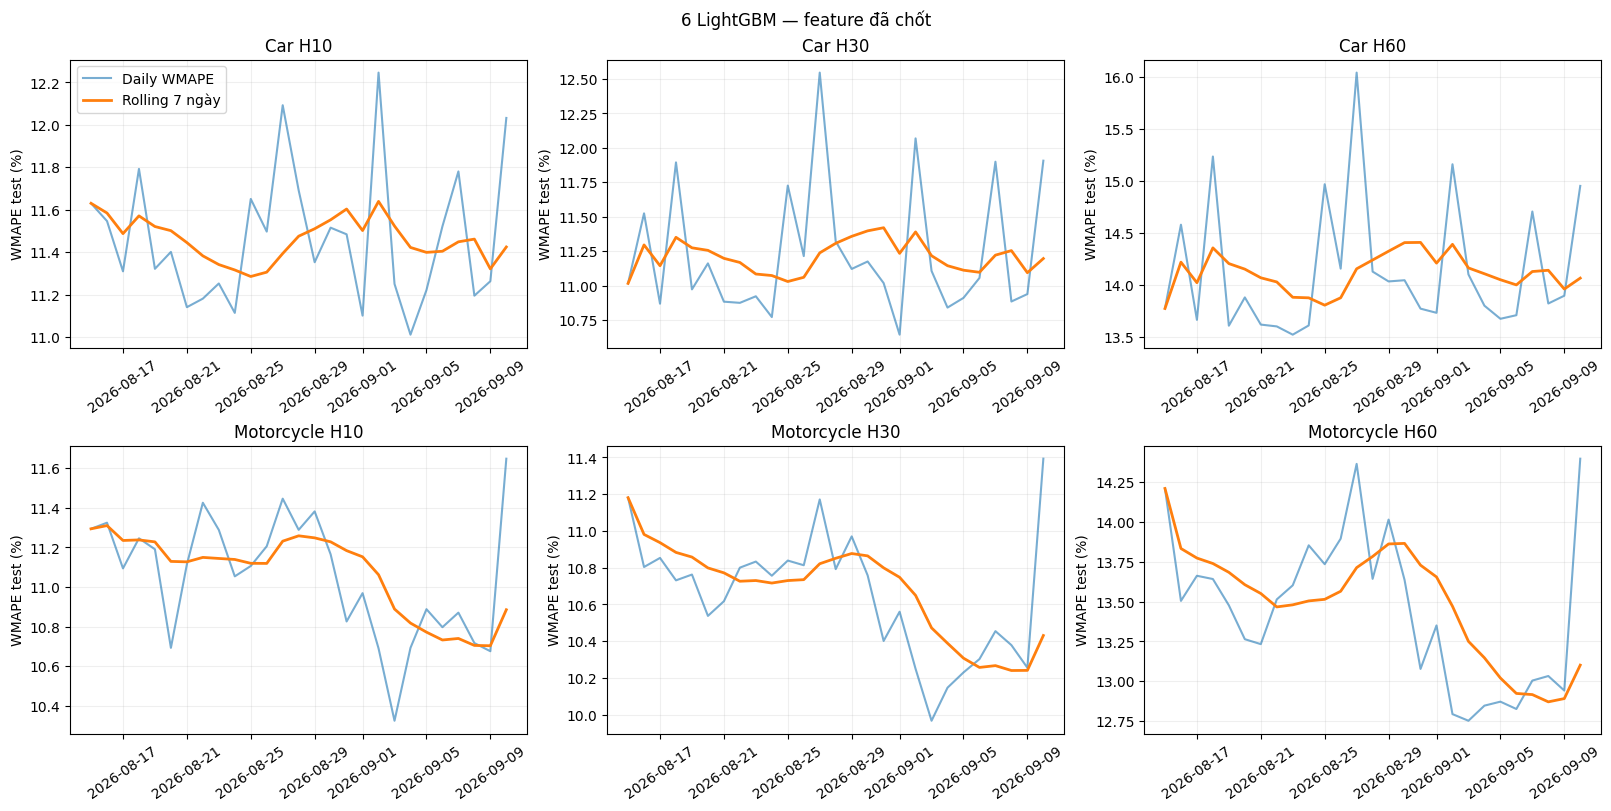

count    mean    std     min     max
mode       horizon                                      
Car        10          27  11.467  0.318  11.012  12.246
           30          27  11.232  0.473  10.645  12.545
           60          27  14.138  0.641  13.519  16.044
Motorcycle 10          27  11.053  0.308  10.325  11.649
           30          27  10.650  0.339   9.966  11.393
           60          27  13.450  0.486  12.752  14.398

,bucket_start,day,hex_id_7,actual,predicted,absolute_error,mode,horizon
0,2026-09-07 18:30:00+07:00,2026-09-07,8765b5666ffffff,1000.0,286,714.0,Car,10
1,2026-09-10 23:50:00+07:00,2026-09-10,8765b564cffffff,1000.0,310,690.0,Car,10
2,2026-09-02 18:20:00+07:00,2026-09-02,8765b5662ffffff,1000.0,313,687.0,Car,10
3,2026-09-02 18:10:00+07:00,2026-09-02,8765b5662ffffff,1000.0,332,668.0,Car,10
4,2026-09-07 17:40:00+07:00,2026-09-07,8765b5666ffffff,1000.0,338,662.0,Car,10
5,2026-09-07 17:30:00+07:00,2026-09-07,8765b5666ffffff,1000.0,339,661.0,Car,10
6,2026-09-02 18:30:00+07:00,2026-09-02,8765b5662ffffff,681.0,310,371.0,Car,10
7,2026-08-18 23:00:00+07:00,2026-08-18,8765b5645ffffff,244.0,123,121.0,Car,10
8,2026-08-18 23:50:00+07:00,2026-08-18,8765b5645ffffff,141.0,245,104.0,Car,10
9,2026-09-07 18:10:00+07:00,2026-09-07,8765b5666ffffff,385.0,285,100.0,Car,10


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for i, mode in enumerate(MODES):
    for j, h in enumerate(HORIZONS):
        daily = DAILY_METRICS.query("mode == @mode and horizon == @h")
        dates = pd.to_datetime(daily["day"])
        axes[i, j].plot(dates, daily["WMAPE_pct"], alpha=0.6, label="Daily WMAPE")
        axes[i, j].plot(dates, daily["rolling_7d_WMAPE_pct"], linewidth=2, label="Rolling 7 ngày")
        axes[i, j].set_title(f"{mode} H{h}")
        axes[i, j].set_ylabel("WMAPE test (%)")
        axes[i, j].tick_params(axis="x", rotation=35)
        axes[i, j].grid(alpha=0.2)
axes[0, 0].legend()
fig.suptitle("6 LightGBM — feature đã chốt")
plt.show()
display(DAILY_METRICS.groupby(["mode", "horizon"])["WMAPE_pct"].agg(
    ["count", "mean", "std", "min", "max"]
).round(3))
display(TOP_OUTLIERS.head(20))


## 8. Lưu model, feature manifest và bảng kết quả

Lưu đúng 6 model cuối, thứ tự feature, mã hex, tham số cây/lá đã chọn và cutoff.
Có toàn bộ trial/validation/test metrics để đối chiếu. Model ở trạng thái candidate, chưa deploy.
Nếu test còn >18%, kết quả và model vẫn được lưu để tiếp tục phân tích; không đổi cấu hình theo test.


In [16]:
model_dir, report_dir = RUN_DIR / "models", RUN_DIR / "reports"
model_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)
entries = []
for key in CASES:
    mode, h = key
    columns = FEATURE_COLUMNS[key]
    model = FINAL_SIX_MODELS[key]
    assert model.n_features_in_ == len(columns)
    test_row = FINAL_TEST_RESULTS.query("mode == @mode and horizon == @h").iloc[0]
    artifact = {
        "model": model, "model_name": "lightgbm", "strategy": "direct",
        "travel_mode": mode, "horizon": h, "variant": FEATURE_POLICY[key],
        "feature_columns": columns, "feature_count": len(columns),
        "input_format": "pandas" if h == 10 else "numeric_float32",
        "hex_categories": sorted(MODE_FRAMES[mode]["hex_id_7"].astype(str).unique()),
        "training_origin": str(LOCAL_START), "validation_start": str(VAL_START),
        "test_start": str(TEST_START), "fit_scope": "train_plus_validation",
        "selected_params": SELECTED_PARAMS[key],
        "tree_leaf_selection": {"leaves": list(LEAF_CANDIDATES), "max_trees": MAX_TREES,
                                "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
                                "criterion": "validation WMAPE on nonnegative float prediction"},
        "rounding": "np.rint(np.clip(prediction, 0, None))",
        "availability_requirement": "T-10/T-20 closed and ingested before forecast T",
        "test_wmape_integer_pct": float(test_row["WMAPE_pct"]),
    }
    filename = f"{mode.lower()}_h{h}_lightgbm.joblib"
    joblib.dump(artifact, model_dir / filename)
    entries.append(dict(mode=mode, horizon=h, variant=FEATURE_POLICY[key],
                        file=filename, features=columns, params=SELECTED_PARAMS[key],
                        test_wmape_integer_pct=float(test_row["WMAPE_pct"])))
tables = {
    "split_summary": SPLIT_SUMMARY, "hyperparameter_trials": TRIAL_RESULTS,
    "selected_validation": VALIDATION_RESULTS, "final_fit_summary": FINAL_FIT_SUMMARY,
    "test_metrics": FINAL_TEST_RESULTS, "error_by_band": ERROR_BY_BAND,
    "residual_summary": RESIDUAL_SUMMARY, "daily_metrics": DAILY_METRICS,
    "top_outliers": TOP_OUTLIERS,
}
for name, table in tables.items():
    table.to_csv(report_dir / f"{name}.csv", index=False)
manifest = {
    "status": "candidate_not_deployed", "source_feature_decision": "feature_out.ipynb",
    "model_count": len(entries), "search_fit_count": SEARCH_FIT_COUNT,
    "final_fit_count": FINAL_FIT_COUNT, "validation_start": str(VAL_START),
    "test_start": str(TEST_START), "test_already_examined_in_source_notebook": True,
    "all_test_WMAPE_under_18": bool(FINAL_TEST_RESULTS["target_under_18"].all()),
    "models": entries,
}
(model_dir / "manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Đã lưu 6 model:", model_dir)
print("Bảng kết quả:", report_dir)


Đã lưu 6 model: /kaggle/working/lightgbm_best_features_6_models/models
Bảng kết quả: /kaggle/working/lightgbm_best_features_6_models/reports


---------------------

In [17]:
# CELL 1 — Một bộ thống kê thống nhất, dùng TOÀN BỘ TEST và prediction gốc.
# Chạy ba cell này sau cell gốc tạo FINAL_TEST_PRED; không cần train lại LightGBM.
import numpy as np
import pandas as pd
from IPython.display import display

TOP_N = 10                  # None: hiển thị tất cả; không giới hạn dữ liệu thống kê.
ERROR_THRESHOLD_PCT = 15.0  # Ngưỡng tuyệt đối, không phải 1.25 lần lỗi toàn model.
MIN_SAMPLES, MIN_DAYS = 12, 2  # Chỉ gắn cờ ít dữ liệu; KHÔNG bỏ nhóm >15%.
_hd_keys = ["hex", "Thu", "Gio"]
_hd_names = {0: "Thứ 2", 1: "Thứ 3", 2: "Thứ 4", 3: "Thứ 5",
             4: "Thứ 6", 5: "Thứ 7", 6: "CN"}

required = ["CASES", "CASE_DATA", "SPLITS", "FINAL_TEST_PRED",
            "SELECTED_VALIDATION_PRED", "VAL_MIDPOINT", "actual_for"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Chưa có biến của notebook gốc: " + ", ".join(missing))

def _hd_int(p):
    p = np.asarray(p, dtype=float)
    if not np.isfinite(p).all():
        raise ValueError("Prediction có NaN/inf")
    return np.rint(np.maximum(0, p)).astype(np.int64)

def _hd_rows(key, ix, prediction, with_actual=True):
    f = CASE_DATA[key]["frame"].iloc[ix]
    t = pd.DatetimeIndex(f["bucket_start"]).tz_convert("Asia/Ho_Chi_Minh")
    p = np.asarray(prediction, dtype=float)
    if p.shape != (len(f),) or not np.isfinite(p).all():
        raise ValueError(f"{key}: prediction không khớp số dòng hoặc có NaN/inf")
    d = pd.DataFrame({"hex": f["hex_id_7"].astype(str).to_numpy(),
                      "time": t, "Thu": t.dayofweek, "Gio": t.hour,
                      "Ngay": t.normalize(), "pred": _hd_int(p)})
    if with_actual:
        y = np.asarray(actual_for(key, ix), dtype=float)
        if y.shape != p.shape or not np.isfinite(y).all() or (y < 0).any():
            raise ValueError(f"{key}: actual không hợp lệ")
        d["actual"], d["lech"], d["loi"] = y, d["pred"] - y, np.abs(d["pred"] - y)
    return d

def _hd_wmape(y, p):
    return 100 * np.abs(np.asarray(p) - y).sum() / y.sum() if y.sum() > 0 else np.nan

def _hd_stats(d):
    g = d.groupby(_hd_keys, observed=True, sort=False).agg(
        So_mau=("actual", "size"), Tong_demand=("actual", "sum"),
        Tong_loi=("loi", "sum"), Tong_lech=("lech", "sum"),
        Lech_trung_vi=("lech", "median")).reset_index()
    daily = d.groupby(_hd_keys + ["Ngay"], observed=True, sort=False).agg(
        So_mau=("actual", "size"), Tong_demand=("actual", "sum"),
        Tong_loi=("loi", "sum"), Tong_lech=("lech", "sum"),
        Lech_trung_vi=("lech", "median")).reset_index()
    daily["Thieu"], daily["Thua"] = daily["Lech_trung_vi"] < 0, daily["Lech_trung_vi"] > 0
    days = daily.groupby(_hd_keys, observed=True, sort=False).agg(
        So_ngay=("Ngay", "size"), Ngay_thieu=("Thieu", "sum"),
        Ngay_thua=("Thua", "sum"), Loi_ngay_max=("Tong_loi", "max")).reset_index()
    g = g.merge(days, on=_hd_keys, validate="one_to_one")
    volume = g["Tong_demand"].replace(0, np.nan)
    g["MAE"], g["WMAPE_%"] = g["Tong_loi"] / g["So_mau"], 100 * g["Tong_loi"] / volume
    g["Bias_%"] = 100 * g["Tong_lech"] / volume
    g["Ngay_cung_chieu_%"] = 100 * np.where(
        g["Lech_trung_vi"] < 0, g["Ngay_thieu"],
        np.where(g["Lech_trung_vi"] > 0, g["Ngay_thua"], 0)) / g["So_ngay"]
    g["Loi_ngay_lon_nhat_%"] = 100 * g["Loi_ngay_max"] / g["Tong_loi"].replace(0, np.nan)
    return g, daily

def _hd_weak(g, overall_wmape=None):
    return g["WMAPE_%"] > ERROR_THRESHOLD_PCT

def _hd_scope(rows, key):
    # Chỉ tra khóa đã khóa ở cell 1, tuyệt đối không xét actual từng dòng để bật/tắt.
    idx = pd.MultiIndex.from_frame(rows[_hd_keys])
    return np.asarray(idx.isin(pd.MultiIndex.from_frame(CORRECTION_GROUPS[key][_hd_keys])))

def _hd_basic_stats(d, cols):
    g = d.groupby(cols, observed=True, sort=False).agg(
        So_mau=("actual", "size"), So_ngay=("Ngay", "nunique"),
        Tong_demand=("actual", "sum"), Tong_loi=("loi", "sum"),
        Tong_lech=("lech", "sum"), Lech_trung_vi=("lech", "median")).reset_index()
    volume = g["Tong_demand"].replace(0, np.nan)
    g["MAE"], g["WMAPE_%"] = g["Tong_loi"] / g["So_mau"], 100 * g["Tong_loi"] / volume
    g["Bias_%"] = 100 * g["Tong_lech"] / volume
    return g

# Cố định cùng một prediction đầu vào cho cả hai phương án hiệu chỉnh.
BASE_TEST_PRED = {key: _hd_int(FINAL_TEST_PRED[key]) for key in CASES}
BASE_VAL_PRED = {key: _hd_int(SELECTED_VALIDATION_PRED[key]) for key in CASES}
_hd_specs = [("hex", ["hex"], "Hex"), ("gio", ["Gio"], "Giờ — gộp các hex"),
             ("thu", ["Thu"], "Thứ — gộp các hex"),
             ("thu_gio", ["Thu", "Gio"], "Thứ + giờ — gộp các hex"),
             ("hex_thu_gio", _hd_keys, "Hex + thứ + giờ — đúng từng nhóm")]
ERROR_RANKINGS = {kind: [] for kind, _, _ in _hd_specs}
_hd_daily, _hd_summary = [], []
CORRECTION_GROUPS, CORRECTION_MASKS = {}, {}

for key in CASES:
    name = f"{key[0]} H{key[1]}"
    d = _hd_rows(key, SPLITS[key]["test_index"], BASE_TEST_PRED[key])
    y, p = d["actual"].to_numpy(), d["pred"].to_numpy()
    score, total_error = _hd_wmape(y, p), d["loi"].sum()
    exact, daily = _hd_stats(d)
    exact["Yeu_TEST"] = _hd_weak(exact)
    exact["It_du_lieu"] = (exact["So_mau"] < MIN_SAMPLES) | (exact["So_ngay"] < MIN_DAYS)
    # APE khi actual=0 không xác định: đếm riêng, không chia cho 1 giả tạo.
    flags = d.assign(
        positive=d["actual"] > 0,
        over15=(d["actual"] > 0) & (d["loi"] > ERROR_THRESHOLD_PCT / 100 * d["actual"]),
        zero_wrong=(d["actual"] == 0) & (d["pred"] != 0))
    freq = flags.groupby(_hd_keys, observed=True).agg(
        So_mau_actual_duong=("positive", "sum"), So_mau_lech_tren15=("over15", "sum"),
        So_mau_zero_du_bao_sai=("zero_wrong", "sum")).reset_index()
    exact = exact.merge(freq, on=_hd_keys, validate="one_to_one")
    exact["Tan_suat_lech_tren15_%"] = 100 * exact["So_mau_lech_tren15"] / exact["So_mau_actual_duong"].replace(0, np.nan)
    daily["WMAPE_%"] = 100 * daily["Tong_loi"] / daily["Tong_demand"].replace(0, np.nan)
    daily["Ngay_tren15"] = daily["WMAPE_%"] > ERROR_THRESHOLD_PCT
    day_freq = daily.groupby(_hd_keys, observed=True)["Ngay_tren15"].sum().reset_index(name="So_ngay_tren15")
    exact = exact.merge(day_freq, on=_hd_keys, validate="one_to_one")
    CORRECTION_GROUPS[key] = exact.loc[exact["Yeu_TEST"]].copy()
    CORRECTION_MASKS[key] = _hd_scope(d, key)
    BASE_TEST_PRED[key].setflags(write=False)
    CORRECTION_MASKS[key].setflags(write=False)
    _hd_daily.append(daily.assign(Model=name))
    _hd_summary.append({"Model": name, "So_mau_TEST": len(d), "Tong_demand": y.sum(),
                        "Tong_loi": total_error, "MAE_goc": total_error / len(d),
                        "Test_WMAPE_goc_%": score,
                        "Bias_goc_%": 100 * (p - y).sum() / y.sum() if y.sum() else np.nan,
                        "So_nhom_hex_thu_gio": len(exact),
                        "So_nhom_yeu_TEST": int(exact["Yeu_TEST"].sum())})
    for kind, cols, _ in _hd_specs:
        g = exact.copy() if kind == "hex_thu_gio" else _hd_basic_stats(d, cols)
        g["Ty_trong_loi_%"] = 100 * g["Tong_loi"] / total_error if total_error else 0.0
        # Cùng tổng lỗi: phân hạng tiếp theo khóa nhóm để kết quả hiển thị ổn định.
        g = g.sort_values(["Tong_loi"] + cols, ascending=[False] + [True] * len(cols)).reset_index(drop=True)
        g["Hang"], g["Model"] = np.arange(1, len(g) + 1), name
        ERROR_RANKINGS[kind].append(g)

BASE_TEST_RESULTS = pd.DataFrame(_hd_summary)
ERROR_RANKINGS = {kind: pd.concat(tables, ignore_index=True) for kind, tables in ERROR_RANKINGS.items()}
THONG_KE_THEO_HEX, THONG_KE_THEO_GIO = ERROR_RANKINGS["hex"], ERROR_RANKINGS["gio"]
THONG_KE_THEO_THU, THONG_KE_THEO_THU_GIO = ERROR_RANKINGS["thu"], ERROR_RANKINGS["thu_gio"]
THONG_KE_HEX_THU_GIO = ERROR_RANKINGS["hex_thu_gio"]
NHOM_YEU_HEX_THU_GIO = THONG_KE_HEX_THU_GIO.loc[THONG_KE_HEX_THU_GIO["Yeu_TEST"]].copy()
CHI_TIET_NHOM_THEO_NGAY = pd.concat(_hd_daily, ignore_index=True)
print("Tổng TEST gốc của từng model:")
display(BASE_TEST_RESULTS.round(4))
for kind, cols, title in _hd_specs:
    table = ERROR_RANKINGS[kind]
    shown = (table if TOP_N is None else table.loc[table["Hang"] <= TOP_N]).copy()
    if "Thu" in shown:
        shown["Thu"] = shown["Thu"].map(_hd_names)
    display_cols = ["Model", "Hang", *cols, "So_mau", "So_ngay", "Tong_loi", "Ty_trong_loi_%",
                    "MAE", "WMAPE_%", "Bias_%", "Lech_trung_vi"]
    if kind == "hex_thu_gio":
        display_cols += ["Ngay_cung_chieu_%", "Loi_ngay_lon_nhat_%", "Yeu_TEST"]
    print(f"\n{title}: toàn bộ nhóm, xếp giảm dần theo Tong_loi")
    with pd.option_context("display.max_rows", len(shown) + 1, "display.max_columns", None):
        display(shown[display_cols].round(3))
print("Mọi bảng đều dùng toàn bộ TEST. TOP_N chỉ giới hạn nhóm hiển thị; Yeu_TEST chỉ là cờ đánh dấu.")
print("Thu = thứ trong tuần, Gio = giờ Việt Nam. So_mau đếm dòng trong nhóm; So_ngay đếm ngày thực tế.")
print("Bias/Lech_trung_vi = prediction - actual: âm là thiếu, dương là thừa.")
del d, g, exact, daily, shown, _hd_daily

print("\nNHÓM HIỆU CHỈNH CHUNG: WMAPE nhóm > 15%; không lọc thêm theo MAE/số ngày/top N.")
cols = ["Model", *_hd_keys, "So_mau", "So_ngay", "WMAPE_%", "Bias_%",
        "Tan_suat_lech_tren15_%", "So_ngay_tren15", "It_du_lieu"]
for key in CASES:
    selected = CORRECTION_GROUPS[key].sort_values("Tong_loi", ascending=False).copy()
    selected["Model"] = f"{key[0]} H{key[1]}"
    selected["Thu"] = selected["Thu"].map(_hd_names)
    display((selected if TOP_N is None else selected.head(TOP_N))[cols].round(3))
print("Nhóm tổng actual=0: WMAPE không xác định, báo cáo riêng, không tự coi là >15%.")
NHOM_ZERO_DEMAND = THONG_KE_HEX_THU_GIO.query("Tong_demand == 0").copy()
print("Số nhóm zero-demand:", len(NHOM_ZERO_DEMAND))
print("CHÚ Ý: chọn nhóm bằng nhãn toàn TEST => so sánh hồi cứu, KHÔNG phải test độc lập để chốt deploy.")
print("Hệ số học trên VAL; VAL đã dùng chọn model, và model VAL khác model refit TRAIN+VAL.")
print("H30/H60 là tổng demand trong [T,T+H), không phải demand riêng tại T+H. Thứ/giờ lấy tại T.")
# Chạy lại cell 1 sẽ xóa kết quả hiệu chỉnh cũ, tránh trộn các lần chạy.
CALIBRATED_TEST_PRED, LOCAL_CORRECTED_TEST_PRED = {}, {}


Tổng TEST gốc của từng model:


,Model,So_mau_TEST,Tong_demand,Tong_loi,MAE_goc,Test_WMAPE_goc_%,Bias_goc_%,So_nhom_hex_thu_gio,So_nhom_yeu_TEST
0,Car H10,567283,6121094.0,701442.0,1.2365,11.4594,-0.8334,29358,4717
1,Car H30,566700,18348135.0,2059212.0,3.6337,11.2230,-0.6866,29343,5012
2,Car H60,566010,36658959.0,5178738.0,9.1496,14.1268,-1.0828,29343,11019
3,Motorcycle H10,507116,9565973.0,1053482.0,2.0774,11.0128,-0.5808,27202,5222
4,Motorcycle H30,506604,28677145.0,3040736.0,6.0022,10.6033,0.0032,27192,5531
5,Motorcycle H60,505989,57297912.0,7666793.0,15.1521,13.3806,0.1782,27191,11243



Hex: toàn bộ nhóm, xếp giảm dần theo Tong_loi


,Model,Hang,hex,So_mau,So_ngay,Tong_loi,Ty_trong_loi_%,MAE,WMAPE_%,Bias_%,Lech_trung_vi
0,Car H10,1,8765b5662ffffff,3830,27,23826.0,3.397,6.221,11.089,-1.279,0.0
1,Car H10,2,8765b5666ffffff,3830,27,22123.0,3.154,5.776,11.968,-2.877,0.0
2,Car H10,3,8765b5645ffffff,3830,27,19359.0,2.760,5.055,11.057,-0.818,0.0
3,Car H10,4,8765b5660ffffff,3830,27,18975.0,2.705,4.954,10.776,-1.530,0.0
4,Car H10,5,8765b5663ffffff,3830,27,16751.0,2.388,4.374,10.777,-0.698,0.0
5,Car H10,6,8765b5292ffffff,3830,27,15907.0,2.268,4.153,11.150,-0.208,0.0
6,Car H10,7,8765b5644ffffff,3830,27,15010.0,2.140,3.919,11.407,-1.207,0.0
7,Car H10,8,8765b5641ffffff,3830,27,14935.0,2.129,3.899,10.848,-0.344,0.0
8,Car H10,9,8765b5296ffffff,3830,27,13995.0,1.995,3.654,11.125,-0.874,0.0
9,Car H10,10,8765b5646ffffff,3830,27,13602.0,1.939,3.551,11.051,-1.012,0.0



Giờ — gộp các hex: toàn bộ nhóm, xếp giảm dần theo Tong_loi


...

,Model,hex,Thu,Gio,So_mau,So_ngay,WMAPE_%,Bias_%,Tan_suat_lech_tren15_%,So_ngay_tren15,It_du_lieu
18590,Car H60,8765b5666ffffff,Thứ 2,17,24,4,37.207,-31.741,45.833,2,False
18591,Car H60,8765b5666ffffff,Thứ 2,18,24,4,39.132,-35.650,62.500,2,False
17966,Car H60,8765b5662ffffff,Thứ 4,17,24,4,26.728,-22.193,33.333,1,False
17967,Car H60,8765b5662ffffff,Thứ 4,18,24,4,25.726,-21.851,37.500,1,False
18589,Car H60,8765b5666ffffff,Thứ 2,16,24,4,24.456,-12.109,54.167,2,False
4903,Car H60,8765b5292ffffff,Thứ 5,16,24,4,28.664,-27.184,37.500,1,False
14207,Car H60,8765b5645ffffff,Thứ 3,22,24,4,52.429,-47.790,66.667,3,False
19838,Car H60,8765b566effffff,Thứ 5,17,24,4,40.285,34.879,66.667,3,False
4904,Car H60,8765b5292ffffff,Thứ 5,17,24,4,22.856,15.531,41.667,1,False
17965,Car H60,8765b5662ffffff,Thứ 4,16,24,4,21.143,-11.043,45.833,2,False


,Model,hex,Thu,Gio,So_mau,So_ngay,WMAPE_%,Bias_%,Tan_suat_lech_tren15_%,So_ngay_tren15,It_du_lieu
17706,Motorcycle H10,8765b5669ffffff,Thứ 5,23,24,4,30.656,-30.141,54.167,2,False
16698,Motorcycle H10,8765b5662ffffff,Thứ 5,23,24,4,16.409,-12.044,41.667,1,False
24903,Motorcycle H10,8765b575bffffff,Thứ 2,14,24,4,26.084,3.427,45.833,2,False
16429,Motorcycle H10,8765b5661ffffff,CN,18,24,4,15.956,-0.994,54.167,3,False
17210,Motorcycle H10,8765b5665ffffff,Thứ 6,7,18,3,15.566,-4.506,50.000,2,False
24524,Motorcycle H10,8765b5758ffffff,Thứ 7,19,24,4,16.365,0.468,45.833,3,False
24902,Motorcycle H10,8765b575bffffff,Thứ 2,13,24,4,20.918,-14.597,29.167,1,False
16281,Motorcycle H10,8765b5660ffffff,Thứ 2,14,24,4,16.421,-3.780,54.167,2,False
13002,Motorcycle H10,8765b5643ffffff,Thứ 5,23,24,4,17.878,-16.045,45.833,2,False
18204,Motorcycle H10,8765b566cffffff,Thứ 5,17,24,4,15.602,0.518,37.500,2,False


,Model,hex,Thu,Gio,So_mau,So_ngay,WMAPE_%,Bias_%,Tan_suat_lech_tren15_%,So_ngay_tren15,It_du_lieu
13201,Motorcycle H30,8765b5645ffffff,Thứ 7,12,24,4,17.797,-3.881,58.333,2,False
12361,Motorcycle H30,8765b5640ffffff,Thứ 7,12,24,4,15.853,-6.177,33.333,1,False
17700,Motorcycle H30,8765b5669ffffff,Thứ 5,23,22,4,44.348,-44.155,50.000,2,False
24893,Motorcycle H30,8765b575bffffff,Thứ 2,13,24,4,29.704,-26.170,37.500,1,False
16692,Motorcycle H30,8765b5662ffffff,Thứ 5,23,22,4,21.768,-18.278,50.000,1,False
24894,Motorcycle H30,8765b575bffffff,Thứ 2,14,24,4,28.216,9.248,54.167,2,False
12441,Motorcycle H30,8765b5640ffffff,Thứ 3,20,24,4,16.113,-2.565,58.333,2,False
9713,Motorcycle H30,8765b560dffffff,Thứ 7,17,24,4,15.252,-7.062,50.000,1,False
13315,Motorcycle H30,8765b5645ffffff,Thứ 5,6,24,4,15.618,-10.044,45.833,2,False
13084,Motorcycle H30,8765b5644ffffff,Thứ 2,15,24,4,15.924,-8.087,45.833,2,False


,Model,hex,Thu,Gio,So_mau,So_ngay,WMAPE_%,Bias_%,Tan_suat_lech_tren15_%,So_ngay_tren15,It_du_lieu
13200,Motorcycle H60,8765b5645ffffff,Thứ 7,12,24,4,26.366,-2.355,70.833,3,False
16638,Motorcycle H60,8765b5662ffffff,Thứ 3,18,24,4,16.932,16.649,41.667,2,False
16605,Motorcycle H60,8765b5662ffffff,Thứ 2,9,24,4,15.507,5.032,58.333,2,False
5616,Motorcycle H60,8765b5292ffffff,Thứ 5,18,24,4,17.306,-3.549,50.000,2,False
24742,Motorcycle H60,8765b5759ffffff,Thứ 3,7,24,4,16.009,-4.729,50.000,2,False
16560,Motorcycle H60,8765b5662ffffff,Thứ 7,12,24,4,17.464,-3.625,58.333,3,False
12360,Motorcycle H60,8765b5640ffffff,Thứ 7,12,24,4,20.279,-6.469,41.667,2,False
13317,Motorcycle H60,8765b5645ffffff,Thứ 5,9,24,4,15.198,-0.813,41.667,2,False
13314,Motorcycle H60,8765b5645ffffff,Thứ 5,6,24,4,23.041,-16.006,58.333,3,False
13031,Motorcycle H60,8765b5644ffffff,Thứ 7,11,24,4,19.989,-7.539,50.000,2,False


Nhóm tổng actual=0: WMAPE không xác định, báo cáo riêng, không tự coi là >15%.
Số nhóm zero-demand: 0
CHÚ Ý: chọn nhóm bằng nhãn toàn TEST => so sánh hồi cứu, KHÔNG phải test độc lập để chốt deploy.
Hệ số học trên VAL; VAL đã dùng chọn model, và model VAL khác model refit TRAIN+VAL.
H30/H60 là tổng demand trong [T,T+H), không phải demand riêng tại T+H. Thứ/giờ lấy tại T.


In [18]:
# CELL 2 — Tuyến tính theo đúng nhóm cell 1: y_corrected = max(0, a * p_base + b).
# Fit OLS trên VAL đầu; chọn strength trên VAL sau. Không fit bằng nhãn TEST.
# Hai cách cùng phạm vi được phép; số dòng thực sự đổi có thể khác vì điều kiện riêng.
MIN_CAL_ROWS = 12
MIN_CAL_DAYS = 2

def _hd_val_parts(key):
    v = _hd_rows(key, SPLITS[key]["val_index"], BASE_VAL_PRED[key])
    fit = v.loc[v["time"] + pd.Timedelta(minutes=key[1]) <= VAL_MIDPOINT].copy()
    check = v.loc[v["time"] >= VAL_MIDPOINT].copy()
    if fit.empty or check.empty:
        raise ValueError(f"{key}: thiếu một nửa validation")
    return v, fit, check

def _hd_report(key, method, t, after):
    before, y = t["pred"].to_numpy(), t["actual"].to_numpy()
    scope = CORRECTION_MASKS[key]
    assert np.array_equal(scope, _hd_scope(t, key)), "Phạm vi cell 1 bị thay đổi"
    assert np.array_equal(after[~scope], before[~scope]), "Đã sửa ngoài phạm vi cell 1!"
    assert len(after) == len(before) and (after >= 0).all()
    rows = []
    for label, mask in [("Toan_TEST", np.ones(len(t), dtype=bool)),
                        ("Nhom_cell1", scope), ("Ngoai_nhom", ~scope)]:
        yy, pp = y[mask], after[mask]
        rows.append(dict(Model=f"{key[0]} H{key[1]}", Phuong_an=method, Pham_vi=label,
            So_mau=int(mask.sum()), So_mau_doi=int(np.count_nonzero(after[mask] != before[mask])),
            WMAPE_goc_pct=_hd_wmape(yy, before[mask]), WMAPE_pct=_hd_wmape(yy, pp),
            MAE=float(np.mean(np.abs(pp-yy))) if len(yy) else np.nan,
            Bias_pct=100*(pp-yy).sum()/yy.sum() if yy.sum() else np.nan))
    return rows

CALIBRATION_PARAMS, CALIBRATED_TEST_PRED, _linear_reports = {}, {}, []
for key in CASES:
    v, fit, check = _hd_val_parts(key)
    fg = fit.groupby(_hd_keys, observed=True, sort=False).indices
    cg = check.groupby(_hd_keys, observed=True, sort=False).indices
    records = []
    for group in CORRECTION_GROUPS[key][_hd_keys].itertuples(index=False, name=None):
        rec = dict(zip(_hd_keys, group))
        rec.update(a=1.0, b=0.0, strength=0.0, Ly_do="Thieu_VAL", N_fit=0, N_check=0)
        if group in fg and group in cg:
            f, c = fit.iloc[fg[group]], check.iloc[cg[group]]
            rec.update(N_fit=len(f), N_check=len(c))
            if (min(len(f),len(c)) >= MIN_CAL_ROWS and
                min(f["Ngay"].nunique(),c["Ngay"].nunique()) >= MIN_CAL_DAYS):
                x, y = f["pred"].to_numpy(float), f["actual"].to_numpy(float)
                xc = x-x.mean()
                # Slope >=0; prediction hằng số thì chỉ học intercept.
                a = max(0.0, float(xc @ (y-y.mean()) / (xc @ xc))) if xc @ xc > 1e-12 else 1.0
                b = float(y.mean()-a*x.mean())
                pc, yc = c["pred"].to_numpy(float), c["actual"].to_numpy(float)
                best = np.abs(pc-yc).sum()
                rec["Ly_do"] = "VAL_khong_cai_thien"
                for w in (0.25,0.5,0.75,1.0):
                    aa, bb = 1+w*(a-1), w*b
                    loss = np.abs(_hd_int(aa*pc+bb)-yc).sum()
                    if loss < best-1e-9:
                        best = loss
                        rec.update(a=aa,b=bb,strength=w,Ly_do="Ap_dung")
        records.append(rec)
    rules = pd.DataFrame(records, columns=[*_hd_keys,"a","b","strength","Ly_do","N_fit","N_check"])
    CALIBRATION_PARAMS[key] = rules
    t = _hd_rows(key,SPLITS[key]["test_index"],BASE_TEST_PRED[key])
    before = t["pred"].to_numpy()
    after = before.copy()
    scope = CORRECTION_MASKS[key]
    if scope.any():
        lookup = rules.set_index(_hd_keys).reindex(pd.MultiIndex.from_frame(t.loc[scope,_hd_keys]))
        after[scope] = _hd_int(lookup["a"].to_numpy(float)*before[scope]+lookup["b"].to_numpy(float))
    CALIBRATED_TEST_PRED[key] = after
    _linear_reports.extend(_hd_report(key,"Tuyen_tinh",t,after))
    print(key, "| cùng",len(rules),"nhóm cell 1 | trạng thái:",rules["Ly_do"].value_counts().to_dict())
CALIBRATION_RESULTS = pd.DataFrame(_linear_reports)
display(CALIBRATION_RESULTS.round(4))
print("CALIBRATION_PARAMS giữ đủ mọi nhóm cell 1, kể cả nhóm giữ nguyên (a=1,b=0).")


('Car', 10) | cùng 4717 nhóm cell 1 | trạng thái: {'VAL_khong_cai_thien': 2347, 'Thieu_VAL': 1982, 'Ap_dung': 388}
('Car', 30) | cùng 5012 nhóm cell 1 | trạng thái: {'Thieu_VAL': 2135, 'VAL_khong_cai_thien': 2000, 'Ap_dung': 877}
('Car', 60) | cùng 11019 nhóm cell 1 | trạng thái: {'Thieu_VAL': 4147, 'VAL_khong_cai_thien': 3982, 'Ap_dung': 2890}
('Motorcycle', 10) | cùng 5222 nhóm cell 1 | trạng thái: {'Thieu_VAL': 2325, 'VAL_khong_cai_thien': 2321, 'Ap_dung': 576}
('Motorcycle', 30) | cùng 5531 nhóm cell 1 | trạng thái: {'Thieu_VAL': 2400, 'VAL_khong_cai_thien': 1986, 'Ap_dung': 1145}
('Motorcycle', 60) | cùng 11243 nhóm cell 1 | trạng thái: {'Thieu_VAL': 4849, 'VAL_khong_cai_thien': 3664, 'Ap_dung': 2730}


,Model,Phuong_an,Pham_vi,So_mau,So_mau_doi,WMAPE_goc_pct,WMAPE_pct,MAE,Bias_pct
0,Car H10,Tuyen_tinh,Toan_TEST,567283,3391,11.4594,11.4758,1.2383,-0.8796
1,Car H10,Tuyen_tinh,Nhom_cell1,84118,3391,17.8353,17.9946,1.3431,-2.4120
2,Car H10,Tuyen_tinh,Ngoai_nhom,483165,0,10.7307,10.7307,1.2200,-0.7045
3,Car H30,Tuyen_tinh,Toan_TEST,566700,10714,11.2230,11.2479,3.6417,-0.7547
4,Car H30,Tuyen_tinh,Nhom_cell1,89550,10714,18.8293,19.0787,3.8964,-2.2309
5,Car H30,Tuyen_tinh,Ngoai_nhom,477150,0,10.3809,10.3809,3.5939,-0.5913
6,Car H60,Tuyen_tinh,Toan_TEST,566010,49639,14.1268,14.3571,9.2987,-1.4628
7,Car H60,Tuyen_tinh,Nhom_cell1,212286,49639,19.2709,19.9399,11.8567,-2.9123
8,Car H60,Tuyen_tinh,Ngoai_nhom,353724,0,11.4253,11.4253,7.7636,-0.7015
9,Motorcycle H10,Tuyen_tinh,Toan_TEST,507116,4203,11.0128,11.0249,2.0797,-0.6095


CALIBRATION_PARAMS giữ đủ mọi nhóm cell 1, kể cả nhóm giữ nguyên (a=1,b=0).


('Car', 10) | trạng thái: {'VAL_khong_on_dinh': 3110, 'Thieu_VAL': 1602, 'VAL_khong_cai_thien': 3, 'Gain_toan_VAL_qua_nho': 2} | actual xác nhận: 0
('Car', 30) | trạng thái: {'VAL_khong_on_dinh': 3230, 'Thieu_VAL': 1732, 'VAL_khong_cai_thien': 35, 'Gain_toan_VAL_qua_nho': 15} | actual xác nhận: 0
('Car', 60) | trạng thái: {'VAL_khong_on_dinh': 7398, 'Thieu_VAL': 3269, 'Ap_dung_khi_xac_nhan': 203, 'VAL_khong_cai_thien': 149} | actual xác nhận: 1268
('Motorcycle', 10) | trạng thái: {'VAL_khong_on_dinh': 3180, 'Thieu_VAL': 2022, 'VAL_khong_cai_thien': 17, 'Gain_toan_VAL_qua_nho': 3} | actual xác nhận: 0
('Motorcycle', 30) | trạng thái: {'VAL_khong_on_dinh': 3344, 'Thieu_VAL': 2094, 'VAL_khong_cai_thien': 63, 'Gain_toan_VAL_qua_nho': 30} | actual xác nhận: 0
('Motorcycle', 60) | trạng thái: {'VAL_khong_on_dinh': 6791, 'Thieu_VAL': 4149, 'Ap_dung_khi_xac_nhan': 166, 'VAL_khong_cai_thien': 137} | actual xác nhận: 875


,Model,Phuong_an,Pham_vi,So_mau,So_mau_doi,WMAPE_goc_pct,WMAPE_pct,MAE,Bias_pct,Giam_WMAPE_pp
0,Car H10,Tuyen_tinh,Toan_TEST,567283,3391,11.4594,11.4758,1.2383,-0.8796,-0.0163
1,Car H10,Tuyen_tinh,Nhom_cell1,84118,3391,17.8353,17.9946,1.3431,-2.4120,-0.1593
2,Car H10,Tuyen_tinh,Ngoai_nhom,483165,0,10.7307,10.7307,1.2200,-0.7045,0.0000
3,Car H30,Tuyen_tinh,Toan_TEST,566700,10714,11.2230,11.2479,3.6417,-0.7547,-0.0249
4,Car H30,Tuyen_tinh,Nhom_cell1,89550,10714,18.8293,19.0787,3.8964,-2.2309,-0.2494
5,Car H30,Tuyen_tinh,Ngoai_nhom,477150,0,10.3809,10.3809,3.5939,-0.5913,0.0000
6,Car H60,Tuyen_tinh,Toan_TEST,566010,49639,14.1268,14.3571,9.2987,-1.4628,-0.2303
7,Car H60,Tuyen_tinh,Nhom_cell1,212286,49639,19.2709,19.9399,11.8567,-2.9123,-0.6689
8,Car H60,Tuyen_tinh,Ngoai_nhom,353724,0,11.4253,11.4253,7.7636,-0.7015,0.0000
9,Motorcycle H10,Tuyen_tinh,Toan_TEST,507116,4203,11.0128,11.0249,2.0797,-0.6095,-0.0121


Cùng nhóm được phép và cùng mẫu đánh giá; số dòng thực sự đổi khác nhau do strength/xác nhận/làm tròn.


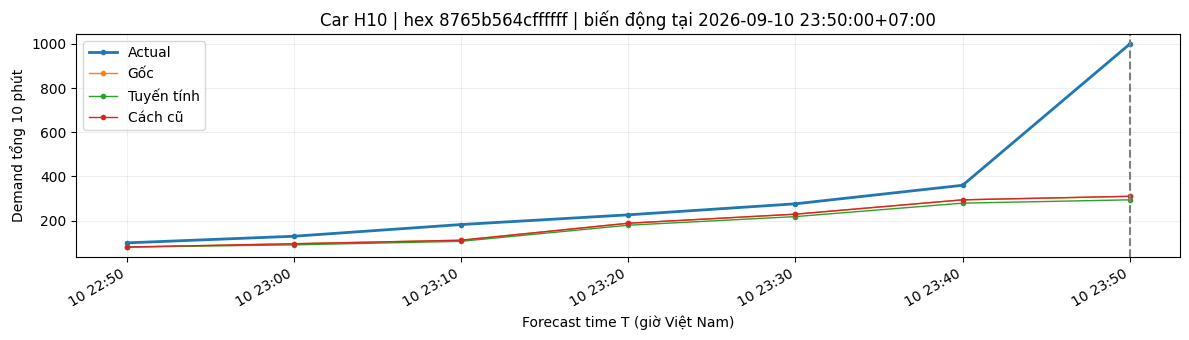

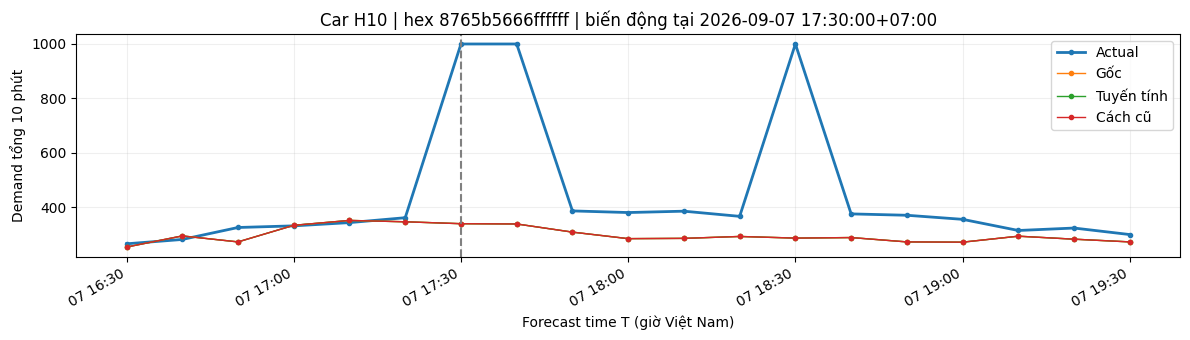

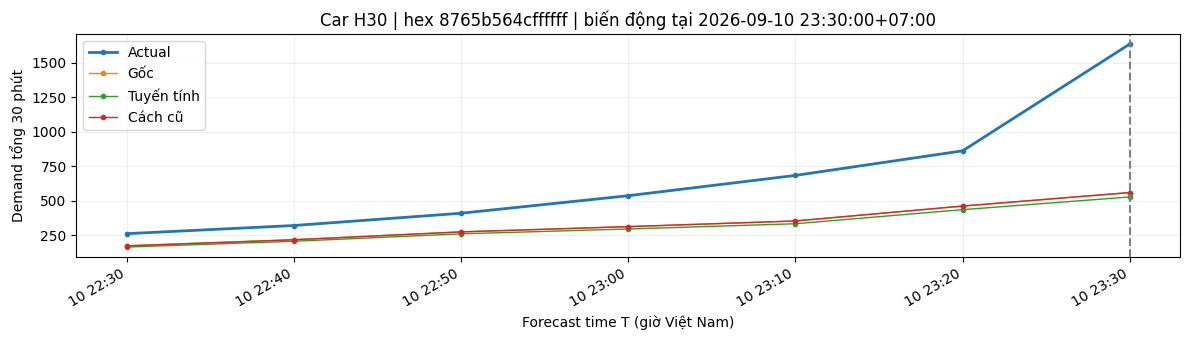

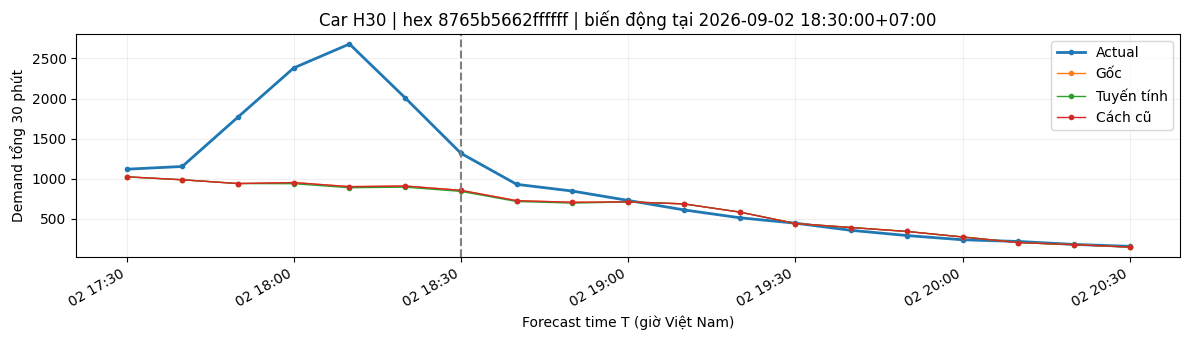

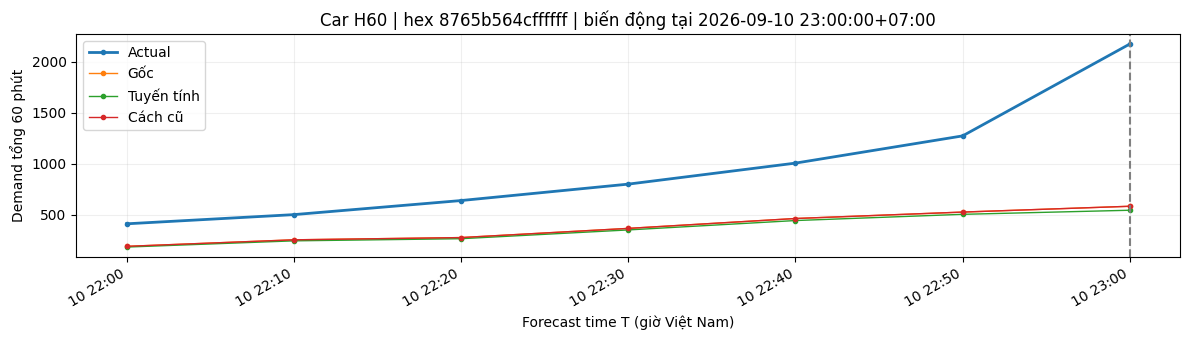

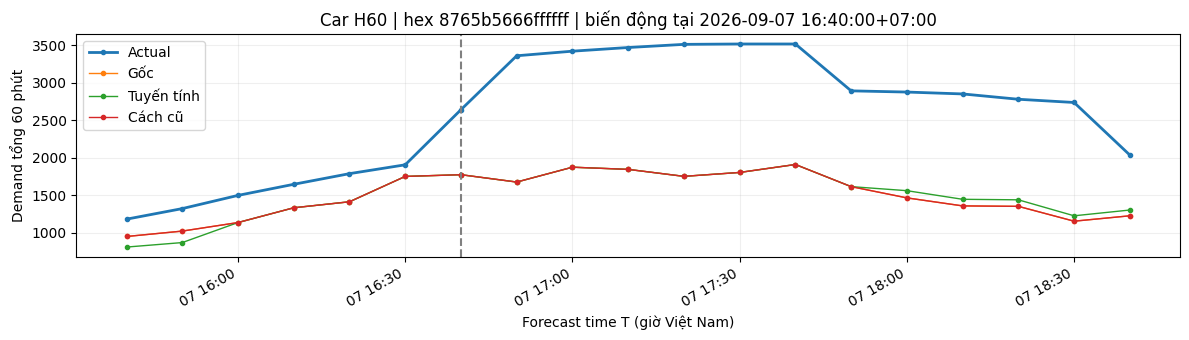

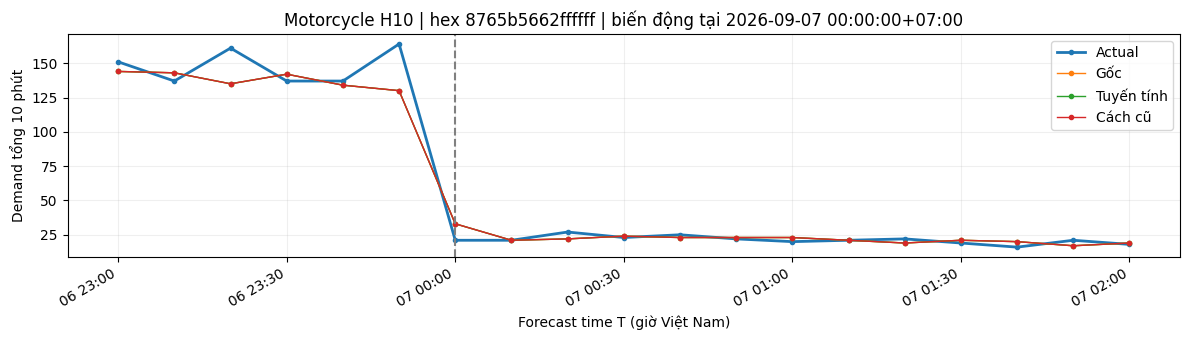

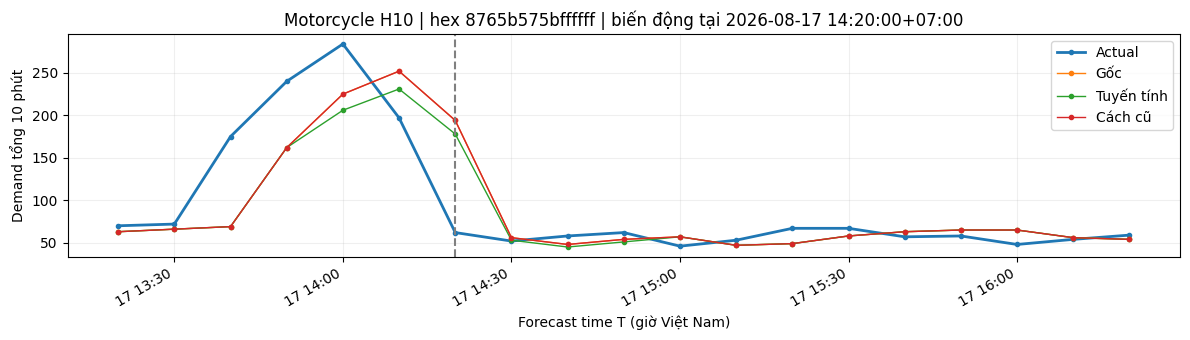

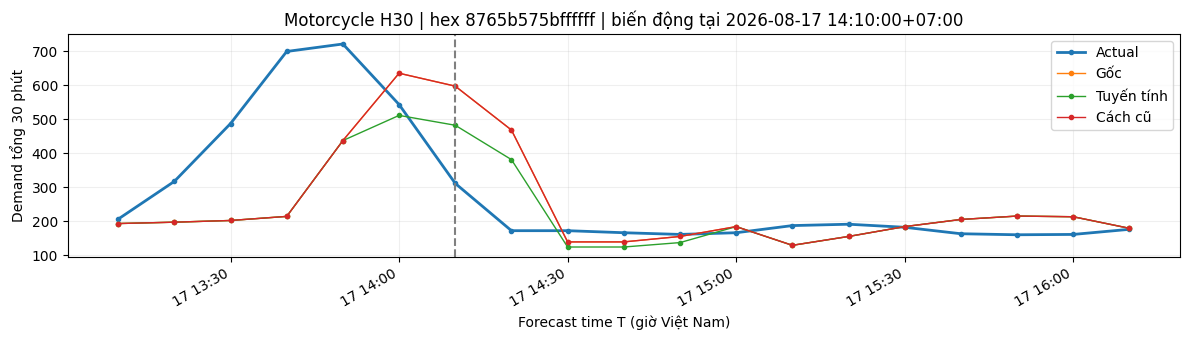

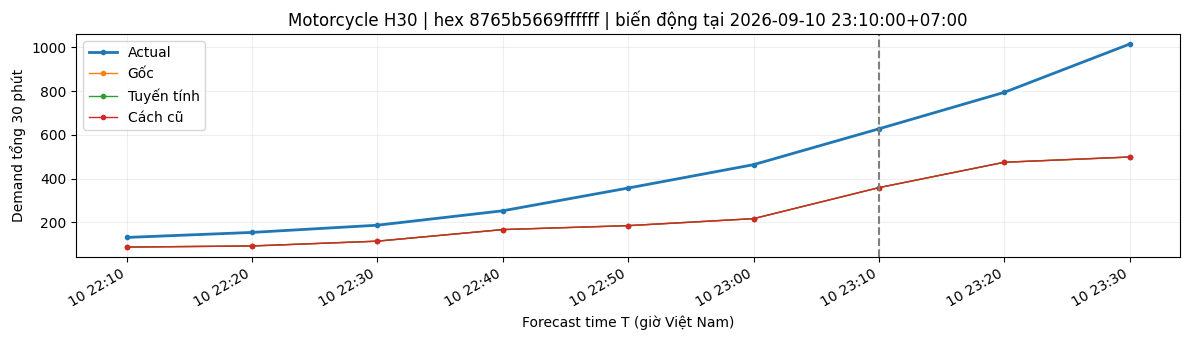

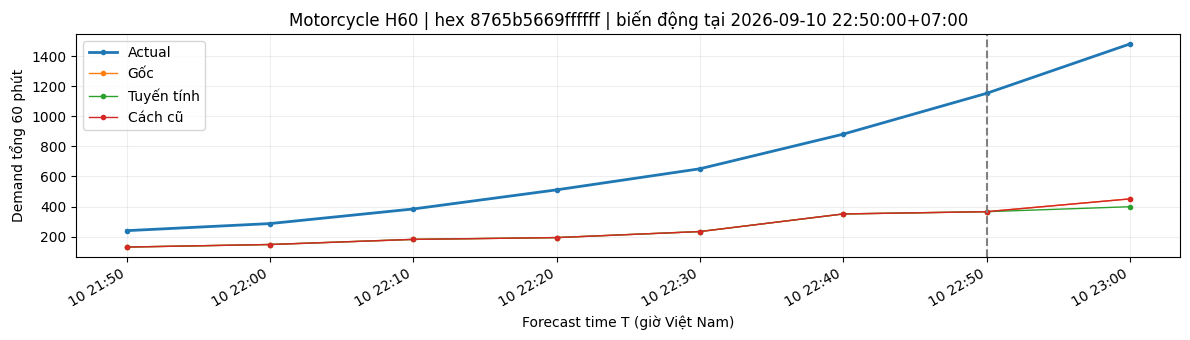

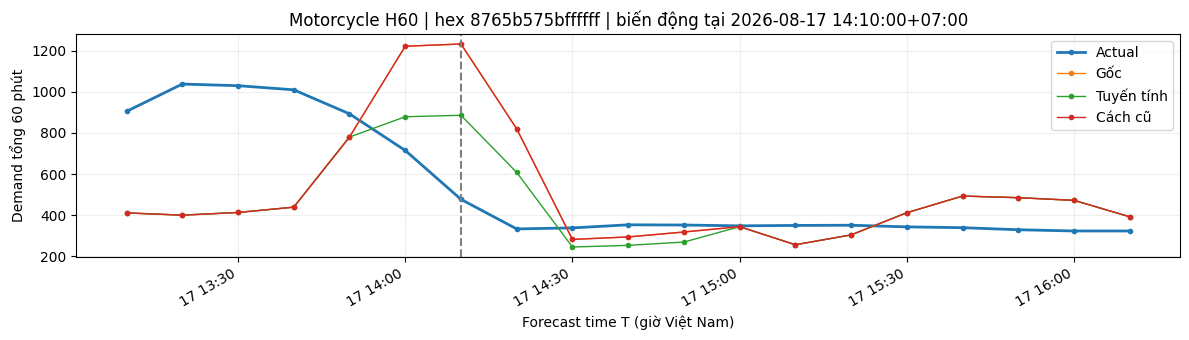

,Model,Phuong_an,Phan_doan,So_mau,WMAPE_pct,MAE,Delta_MAE,Dung_chieu_pct,Bien_do_bam_pct
0,Car H10,Goc,Lien_tiep_10m,567094,11.459,1.236,1.796,31.659,1.512
1,Car H10,Goc,Tang_dot_ngot,9495,22.571,8.241,10.588,48.984,6.770
2,Car H10,Goc,Giam_dot_ngot,4500,35.110,6.524,10.379,50.067,16.987
3,Car H10,Tuyen_tinh,Lien_tiep_10m,567094,11.475,1.238,1.795,31.662,1.523
4,Car H10,Tuyen_tinh,Tang_dot_ngot,9495,22.672,8.278,10.592,49.015,6.730
5,Car H10,Tuyen_tinh,Giam_dot_ngot,4500,34.889,6.482,10.373,50.133,17.019
6,Car H10,Cach_cu,Lien_tiep_10m,567094,11.459,1.236,1.796,31.659,1.512
7,Car H10,Cach_cu,Tang_dot_ngot,9495,22.571,8.241,10.588,48.984,6.770
8,Car H10,Cach_cu,Giam_dot_ngot,4500,35.110,6.524,10.379,50.067,16.987
9,Car H30,Goc,Lien_tiep_10m,566511,11.223,3.634,3.383,52.044,43.217


Delta_MAE càng nhỏ càng tốt; đúng chiều càng cao càng tốt.
Biên độ bám: 100%=đúng tổng biên độ có xét dấu; 0%=không phản ứng; âm=đi ngược; >100%=quá mức.
Không có event: metric NaN, không diễn giải là model đạt. Event liền nhau có thể cùng một đợt biến động.
Sai số actual Hh chỉ được dùng để bù từ T+h+ACTUAL_DELAY_MIN, không dùng nhãn tương lai.
CHƯA CHỐT DEPLOY từ báo cáo này: dữ liệu fake; nhóm chọn từ TEST; VAL đã dùng chọn model.
Bước xác nhận: khóa nhóm/hệ số, đánh giá trên thời gian mới hoặc rolling backtest; kiểm tra dữ liệu thật,
độ trễ ingest T-10/T-20 và chất lượng spike. Ngưỡng 15% là chọn nhóm, không phải tiêu chuẩn deploy.
Đã lưu báo cáo đầy đủ và prediction của cả 6 model: /kaggle/working/lightgbm_best_features_6_models/reports/calibration_comparison


In [19]:
# CELL 3 — Cách cũ: bù residual ổn định trên VAL + xác nhận bằng actual gần nhất đã có.
# Chỉ nhóm cell 1; không chọn danh sách nhóm khác, không bù nối tiếp kết quả tuyến tính.
RECENT_N, RECENT_MAX_AGE_MIN = 3, 30
MIN_RECENT_SAME_PCT, MIN_RECENT_MEDIAN = 75.0, 1.0
ACTUAL_DELAY_MIN = 0         # Tăng nếu actual đến trễ sau lúc đóng target.
MAX_WEIGHT = 0.50            # Chỉ thử bù 25% hoặc 50%.
CAP_PCT, CAP_MIN = 0.10, 1.0 # Chặn |bù| <= max(1 demand, 10% prediction gốc).
MIN_STABLE_PCT, MAX_ONE_DAY_ERROR_PCT = 75.0, 70.0
MIN_GROUP_GAIN_PCT, MIN_MODEL_GAIN_PP = 2.0, 0.001

def _hd_recent_signals(rows, horizon):
    # Với dự đoán xuất phát ở s, actual Hh chỉ sẵn sàng từ s + h + độ trễ ingest.
    # Gom riêng từng hex; sort thời gian rồi trả signal đúng thứ tự cache đầu vào.
    if horizon <= 0 or RECENT_N < 1 or ACTUAL_DELAY_MIN < 0:
        raise ValueError("Horizon/RECENT_N/ACTUAL_DELAY_MIN không hợp lệ")
    t = pd.DatetimeIndex(rows["time"]).to_numpy(dtype="datetime64[ns]").astype(np.int64)
    residual = rows["actual"].to_numpy(dtype=float) - rows["pred"].to_numpy(dtype=float)
    delay = int(pd.Timedelta(minutes=horizon + ACTUAL_DELAY_MIN).value)
    max_age = int(pd.Timedelta(minutes=RECENT_MAX_AGE_MIN).value)
    median, confirmed, count = np.zeros(len(rows)), np.zeros(len(rows), dtype=bool), np.zeros(len(rows), dtype=int)
    for positions in rows.groupby("hex", observed=True, sort=False).indices.values():
        ix = np.asarray(positions)
        ix = ix[np.argsort(t[ix], kind="stable")]
        ts = t[ix]
        if (np.diff(ts) <= 0).any():
            raise ValueError("Trùng (hex, time); cần một prediction gốc cho mỗi khóa")
        available_at = ts + delay
        last = np.searchsorted(available_at, ts, side="right") - 1
        recent_ix = last[:, None] - np.arange(RECENT_N)[None, :]
        safe_ix = np.clip(recent_ix, 0, len(ix) - 1)
        age = ts[:, None] - available_at[safe_ix]
        valid = (recent_ix >= 0) & (age >= 0) & (age <= max_age)
        recent = np.zeros(recent_ix.shape, dtype=float)
        recent[valid] = residual[ix][safe_ix[valid]]
        have = valid.sum(axis=1)
        med = np.median(recent, axis=1)
        same = 100 * (np.sign(recent) == np.sign(med[:, None])).sum(axis=1) / RECENT_N
        ok = ((have == RECENT_N) & (same >= MIN_RECENT_SAME_PCT)
              & (np.abs(med) >= MIN_RECENT_MEDIAN))
        median[ix], confirmed[ix], count[ix] = np.where(ok, med, 0.0), ok, have
    return rows.assign(Bu_gan_nhat=median, Gan_nhat_on_dinh=confirmed, So_actual_gan_nhat=count)

def _hd_online_apply(rows, rules):
    p = rows["pred"].to_numpy(dtype=float)
    if rules.empty:
        return _hd_int(p), np.zeros(len(rows), dtype=bool)
    index = pd.MultiIndex.from_frame(rows[_hd_keys])
    lookup = rules.set_index(_hd_keys)
    raw_b = lookup["Bu_goc_VAL"].reindex(index).fillna(0).to_numpy(dtype=float)
    weight = lookup["Muc_%"].reindex(index).fillna(0).to_numpy(dtype=float) / 100
    recent = rows["Bu_gan_nhat"].to_numpy(dtype=float)
    # Cần đúng nhóm đã chọn VÀ sai số actual-pred gần nhất cùng dấu với số bù VAL.
    ok = ((raw_b != 0) & rows["Gan_nhat_on_dinh"].to_numpy(dtype=bool)
          & (np.sign(raw_b) == np.sign(recent)))
    # Co theo mức lệch hiện tại: không bù quá weight * min(|bù VAL|, |lệch gần nhất|).
    delta = np.where(ok, weight * np.sign(raw_b) * np.minimum(np.abs(raw_b), np.abs(recent)), 0.0)
    cap = np.maximum(CAP_MIN, CAP_PCT * p)
    return _hd_int(p + np.clip(delta, -cap, cap)), ok

LOCAL_CALIBRATION_RULES, LOCAL_CORRECTED_TEST_PRED = {}, {}
_old_reports = []
for key in CASES:
    v, fit, check = _hd_val_parts(key)
    # Fit cũng phải purge độ trễ ingest nếu cấu hình >0.
    fit = fit.loc[fit["time"] + pd.Timedelta(minutes=key[1]+ACTUAL_DELAY_MIN) <= VAL_MIDPOINT]
    v = _hd_recent_signals(v,key[1])
    check = v.loc[v["time"] >= VAL_MIDPOINT].copy()
    gf, _ = _hd_stats(fit)
    gc_stats, _ = _hd_stats(check)
    fg, cg = gf.set_index(_hd_keys), gc_stats.set_index(_hd_keys)
    ci = check.groupby(_hd_keys,observed=True,sort=False).indices
    records=[]
    for group in CORRECTION_GROUPS[key][_hd_keys].itertuples(index=False,name=None):
        rec = dict(zip(_hd_keys,group))
        rec.update(Bu_goc_VAL=0.0, **{"Muc_%":0.0}, Ly_do="Thieu_VAL")
        if group in fg.index and group in cg.index:
            f,c = fg.loc[group],cg.loc[group]
            stable = (min(f["So_mau"],c["So_mau"]) >= MIN_CAL_ROWS
                and min(f["So_ngay"],c["So_ngay"]) >= MIN_CAL_DAYS
                and min(f["Ngay_cung_chieu_%"],c["Ngay_cung_chieu_%"]) >= MIN_STABLE_PCT
                and max(f["Loi_ngay_lon_nhat_%"],c["Loi_ngay_lon_nhat_%"]) <= MAX_ONE_DAY_ERROR_PCT
                and abs(f["Lech_trung_vi"]) >= 1
                and np.sign(f["Lech_trung_vi"]) == np.sign(c["Lech_trung_vi"])
                and np.sign(f["Lech_trung_vi"]) == np.sign(f["Tong_lech"])
                and np.sign(c["Lech_trung_vi"]) == np.sign(c["Tong_lech"]))
            rec["Ly_do"]="VAL_khong_on_dinh"
            if stable:
                raw_b=-float(f["Lech_trung_vi"])
                rows=check.iloc[ci[group]]
                y,p=rows["actual"].to_numpy(),rows["pred"].to_numpy(float)
                day=pd.factorize(rows["Ngay"])[0]
                base_err=np.abs(p-y); best=base_err.sum(); weight=0.0
                rec["Ly_do"]="VAL_khong_cai_thien"
                for w in (0.25,0.50):
                    if w>MAX_WEIGHT: continue
                    candidate=pd.DataFrame([{**dict(zip(_hd_keys,group)),"Bu_goc_VAL":raw_b,"Muc_%":100*w}])
                    adjusted,_=_hd_online_apply(rows,candidate)
                    err=np.abs(adjusted-y)
                    if ((np.bincount(day,weights=err) <= np.bincount(day,weights=base_err)+1e-9).all()
                        and err.sum()<best-1e-9):
                        best,weight=err.sum(),w
                gain=100*(base_err.sum()-best)/base_err.sum() if base_err.sum() else 0.0
                if weight>0 and gain>=MIN_GROUP_GAIN_PCT:
                    rec.update(Bu_goc_VAL=raw_b, **{"Muc_%":100*weight}, Ly_do="Ap_dung_khi_xac_nhan")
        records.append(rec)
    rules=pd.DataFrame(records,columns=[*_hd_keys,"Bu_goc_VAL","Muc_%","Ly_do"])
    val_pred,_=_hd_online_apply(check,rules)
    if _hd_wmape(check["actual"].to_numpy(),check["pred"].to_numpy())-_hd_wmape(check["actual"].to_numpy(),val_pred)<MIN_MODEL_GAIN_PP:
        active=rules["Muc_%"]>0
        rules.loc[active,"Ly_do"]="Gain_toan_VAL_qua_nho"
        rules.loc[:,["Bu_goc_VAL","Muc_%"]]=0.0
    LOCAL_CALIBRATION_RULES[key]=rules
    t=_hd_rows(key,SPLITS[key]["test_index"],BASE_TEST_PRED[key])
    t=_hd_recent_signals(t,key[1])  # Lịch sử TEST bắt đầu rỗng như cách cũ.
    after,confirmed=_hd_online_apply(t,rules)
    LOCAL_CORRECTED_TEST_PRED[key]=after
    _old_reports.extend(_hd_report(key,"Cach_cu",t,after))
    assert set(map(tuple,rules[_hd_keys].to_numpy())) == set(map(tuple,CALIBRATION_PARAMS[key][_hd_keys].to_numpy()))
    print(key,"| trạng thái:",rules["Ly_do"].value_counts().to_dict(),"| actual xác nhận:",int(confirmed.sum()))
LOCAL_CORRECTION_RESULTS=pd.DataFrame(_old_reports)
SO_SANH_3_PHUONG_AN=pd.concat([CALIBRATION_RESULTS,LOCAL_CORRECTION_RESULTS],ignore_index=True)
SO_SANH_3_PHUONG_AN["Giam_WMAPE_pp"]=SO_SANH_3_PHUONG_AN["WMAPE_goc_pct"]-SO_SANH_3_PHUONG_AN["WMAPE_pct"]
display(SO_SANH_3_PHUONG_AN.round(4))
print("Cùng nhóm được phép và cùng mẫu đánh giá; số dòng thực sự đổi khác nhau do strength/xác nhận/làm tròn.")

# ĐÁNH GIÁ BÁM BIẾN ĐỘNG — cùng event/mẫu cho cả 3 phương án.
# Mốc liên tiếp phải cách đúng 10 phút và cùng hex, không nối qua khoảng thiếu dữ liệu.
# H30/H60 có cửa sổ target chồng lấn: đây là thay đổi tổng H phút, không phải spike H10.
SHOCK_REL = 0.30
SHOCK_MIN_PER_10M = 5.0  # Ngưỡng phân tích mặc định; không dùng để tune hệ số.
PLOT_EVENTS_PER_CASE = 2
import matplotlib.pyplot as plt
from pathlib import Path
import json
_group_details, _tracking, _daily_compare, _events = [], [], [], []
for key in CASES:
    name=f"{key[0]} H{key[1]}"
    t=_hd_rows(key,SPLITS[key]["test_index"],BASE_TEST_PRED[key])
    t["Tuyen_tinh"]=CALIBRATED_TEST_PRED[key]
    t["Cach_cu"]=LOCAL_CORRECTED_TEST_PRED[key]
    t["Trong_nhom_cell1"]=CORRECTION_MASKS[key]
    t=t.sort_values(["hex","time"],kind="stable").reset_index(drop=True)
    prev=t.groupby("hex",sort=False)["actual"].shift()
    dt=t.groupby("hex",sort=False)["time"].diff()
    adjacent=dt.eq(pd.Timedelta(minutes=10)).to_numpy()
    dy=(t["actual"]-prev).to_numpy(float)
    shock=adjacent & (np.abs(dy)>=SHOCK_MIN_PER_10M*(key[1]/10)) & (np.abs(dy)>=SHOCK_REL*np.maximum(prev.to_numpy(float),1))
    selections={"Lien_tiep_10m":adjacent,"Tang_dot_ngot":shock & (dy>0),"Giam_dot_ngot":shock & (dy<0)}
    for method,col in [("Goc","pred"),("Tuyen_tinh","Tuyen_tinh"),("Cach_cu","Cach_cu")]:
        p=t[col].to_numpy(float); y=t["actual"].to_numpy(float)
        dp=t.groupby("hex",sort=False)[col].diff().to_numpy(float)
        for segment,mask in selections.items():
            nz=mask & (dy!=0)
            denom=np.abs(dy[mask]).sum()
            _tracking.append(dict(Model=name,Phuong_an=method,Phan_doan=segment,So_mau=int(mask.sum()),
                WMAPE_pct=_hd_wmape(y[mask],p[mask]),
                MAE=float(np.abs(p[mask]-y[mask]).mean()) if mask.any() else np.nan,
                Delta_MAE=float(np.abs(dp[mask]-dy[mask]).mean()) if mask.any() else np.nan,
                Dung_chieu_pct=100*np.mean(np.sign(dp[nz])==np.sign(dy[nz])) if nz.any() else np.nan,
                Bien_do_bam_pct=100*np.sum(dp[mask]*np.sign(dy[mask]))/denom if denom else np.nan))
        z=t.assign(err=np.abs(p-y),signed=p-y,changed=p!=t["pred"].to_numpy())
        detail=z.groupby(_hd_keys,observed=True).agg(So_mau=("actual","size"),Tong_demand=("actual","sum"),
            Tong_loi=("err","sum"),Tong_lech=("signed","sum"),So_mau_doi=("changed","sum")).reset_index()
        detail["WMAPE_pct"]=100*detail["Tong_loi"]/detail["Tong_demand"].replace(0,np.nan)
        detail["Trong_nhom_cell1"]=_hd_scope(detail,key)
        _group_details.append(detail.assign(Model=name,Phuong_an=method))
        daily=z.groupby("Ngay",as_index=False).agg(Tong_demand=("actual","sum"),Tong_loi=("err","sum"))
        daily["WMAPE_pct"]=100*daily["Tong_loi"]/daily["Tong_demand"].replace(0,np.nan)
        _daily_compare.append(daily.assign(Model=name,Phuong_an=method))
    # Event chọn duy nhất bằng biến động actual, không chọn khác nhau theo phương án.
    event=t.loc[shock,["hex","time","actual","pred","Tuyen_tinh","Cach_cu","Trong_nhom_cell1"]].copy()
    event["Delta_actual"]=dy[shock]
    _events.append(event.assign(Model=name))
    picked=event.assign(size=event["Delta_actual"].abs()).sort_values("size",ascending=False)
    centers=[]
    for row in picked.itertuples(index=False):
        if any(row.hex==hx and abs(row.time-ts)<=pd.Timedelta(hours=2) for hx,ts in centers):
            continue
        centers.append((row.hex,row.time))
        if len(centers)>=PLOT_EVENTS_PER_CASE: break
    for hx,ts in centers:
        window=t.loc[(t["hex"]==hx)&t["time"].between(ts-pd.Timedelta(hours=1),ts+pd.Timedelta(hours=2))].copy()
        # Reindex để đồ thị không vẽ nối qua bucket thiếu.
        window=window.set_index("time").reindex(pd.date_range(window["time"].min(),window["time"].max(),freq="10min"))
        fig,ax=plt.subplots(figsize=(12,3.5))
        for col,label in [("actual","Actual"),("pred","Gốc"),("Tuyen_tinh","Tuyến tính"),("Cach_cu","Cách cũ")]:
            ax.plot(window.index,window[col],label=label,linewidth=2 if col=="actual" else 1,marker=".")
        ax.axvline(ts,color="gray",linestyle="--")
        ax.set_title(f"{name} | hex {hx} | biến động tại {ts}")
        ax.set_ylabel(f"Demand tổng {key[1]} phút");ax.set_xlabel("Forecast time T (giờ Việt Nam)")
        ax.legend();ax.grid(alpha=.2);fig.autofmt_xdate();plt.tight_layout();plt.show()
        plt.close(fig)

CHI_TIET_SO_SANH_NHOM=pd.concat(_group_details,ignore_index=True)
DANH_GIA_BAM_BIEN_DONG=pd.DataFrame(_tracking)
SO_SANH_THEO_NGAY=pd.concat(_daily_compare,ignore_index=True)
SU_KIEN_DOT_NGOT=pd.concat(_events,ignore_index=True)
display(DANH_GIA_BAM_BIEN_DONG.round(3))
print("Delta_MAE càng nhỏ càng tốt; đúng chiều càng cao càng tốt.")
print("Biên độ bám: 100%=đúng tổng biên độ có xét dấu; 0%=không phản ứng; âm=đi ngược; >100%=quá mức.")
print("Không có event: metric NaN, không diễn giải là model đạt. Event liền nhau có thể cùng một đợt biến động.")
print("Sai số actual Hh chỉ được dùng để bù từ T+h+ACTUAL_DELAY_MIN, không dùng nhãn tương lai.")
print("CHƯA CHỐT DEPLOY từ báo cáo này: dữ liệu fake; nhóm chọn từ TEST; VAL đã dùng chọn model.")
print("Bước xác nhận: khóa nhóm/hệ số, đánh giá trên thời gian mới hoặc rolling backtest; kiểm tra dữ liệu thật,")
print("độ trễ ingest T-10/T-20 và chất lượng spike. Ngưỡng 15% là chọn nhóm, không phải tiêu chuẩn deploy.")

# Lưu bảng đầy đủ (TOP_N chỉ ảnh hưởng hiển thị), tham số và cùng phạm vi để đối chiếu.
analysis_dir=Path(RUN_DIR)/"reports"/"calibration_comparison"
analysis_dir.mkdir(parents=True,exist_ok=True)
exports={"all_hex_weekday_hour":THONG_KE_HEX_THU_GIO,"selected_groups":NHOM_YEU_HEX_THU_GIO,
         "zero_demand_groups":NHOM_ZERO_DEMAND,"group_daily":CHI_TIET_NHOM_THEO_NGAY,
         "comparison":SO_SANH_3_PHUONG_AN,"group_comparison":CHI_TIET_SO_SANH_NHOM,
         "tracking":DANH_GIA_BAM_BIEN_DONG,"daily_comparison":SO_SANH_THEO_NGAY,"shock_events":SU_KIEN_DOT_NGOT}
for title,table in exports.items():
    table.to_csv(analysis_dir/f"{title}.csv",index=False)
for key in CASES:
    tag=f"{key[0].lower()}_h{key[1]}"
    CALIBRATION_PARAMS[key].to_csv(analysis_dir/f"{tag}_linear_rules.csv",index=False)
    LOCAL_CALIBRATION_RULES[key].to_csv(analysis_dir/f"{tag}_old_rules.csv",index=False)
    rows=_hd_rows(key,SPLITS[key]["test_index"],BASE_TEST_PRED[key])
    rows["linear"]=CALIBRATED_TEST_PRED[key];rows["old"]=LOCAL_CORRECTED_TEST_PRED[key]
    rows["in_cell1_scope"]=CORRECTION_MASKS[key]
    rows.to_csv(analysis_dir/f"{tag}_predictions.csv.gz",index=False,compression="gzip")
(analysis_dir/"status.json").write_text(json.dumps({
    "status":"retrospective_diagnostic_not_deployment_approval",
    "scope_source":"full_test_group_WMAPE_strictly_above_15pct",
    "parameter_source":"first_half_validation_fit_second_half_validation_check",
    "validation_reused_for_model_selection":True,"validation_model_differs_from_final_model":True,
    "target_semantics":"demand summed over [T,T+H)","timezone":"Asia/Ho_Chi_Minh",
    "shock_relative":SHOCK_REL,"shock_min_per_10m":SHOCK_MIN_PER_10M,
    "actual_delay_minutes":ACTUAL_DELAY_MIN,"independent_future_evaluation_required":True
},ensure_ascii=False,indent=2),encoding="utf-8")
print("Đã lưu báo cáo đầy đủ và prediction của cả 6 model:",analysis_dir)


## 9. Kết luận từ output của lần chạy hiện tại

**Quyết định đề xuất: giữ 6 model gốc làm ứng viên để tiếp tục kiểm thử pipeline/inference; chưa bật hai lớp hiệu chỉnh và chưa chốt triển khai vận hành tự động.** Chất lượng trung bình trên bộ dữ liệu tổng hợp tương đối tốt theo ngưỡng tham khảo của notebook, nhưng khả năng bám biến động đột ngột còn hạn chế. Kết luận dưới đây dựa trên **output đã lưu của lần chạy này**, không phải kết quả một lần huấn luyện mới. Nếu chạy lại với dữ liệu/cấu hình khác, cần cập nhật phần kết luận.

### 9.1. Chất lượng tổng thể và lựa chọn hiệu chỉnh

WMAPE càng thấp càng tốt. Đơn vị bảng là **%**; chênh lệch WMAPE được tính bằng **điểm phần trăm (pp)**, không phải phần trăm cải thiện tương đối.

| Model | Gốc | Tuyến tính | Cách cũ | Nhận xét |
|---|---:|---:|---:|---|
| Car H10 | 11.4594 | 11.4758 | 11.4594 | Tuyến tính xấu hơn; cách cũ không đổi |
| Car H30 | 11.2230 | 11.2479 | 11.2230 | Tuyến tính xấu hơn; cách cũ không đổi |
| Car H60 | 14.1268 | 14.3571 | 14.1258 | Cách cũ giảm khoảng 0.0010 pp, rất nhỏ |
| Motorcycle H10 | 11.0136 | 11.0260 | 11.0136 | Tuyến tính xấu hơn; cách cũ không đổi |
| Motorcycle H30 | 10.6033 | 10.6225 | 10.6033 | Tuyến tính xấu hơn; cách cũ không đổi |
| Motorcycle H60 | 13.3806 | 13.4994 | 13.3801 | Cách cũ giảm khoảng 0.0005 pp, rất nhỏ |

- Cả 6 model gốc đều dưới **15% WMAPE toàn test**, đồng thời đạt ngưỡng tham khảo **18%** có sẵn trong notebook. Điều này không có nghĩa mọi hex–thứ–giờ đều dưới 15%, và WMAPE 11% không có nghĩa là “đúng 89% số dự đoán”.
- WMAPE theo ngày của model gốc trong 27 ngày test có độ lệch chuẩn khoảng **0.307–0.641 pp**; mức cao nhất của từng model nằm trong **11.393–16.044%**. Sai số tổng hợp tương đối ổn định trong giai đoạn này, nhưng vẫn che khuất lỗi cục bộ và các cú sốc demand.
- **Chưa nên bật hiệu chỉnh tuyến tính hiện tại:** WMAPE tăng ở cả 6 model trên toàn test và ngay trong nhóm cell 1. Car H60 bị ảnh hưởng rõ nhất: 14.1268% → 14.3571%. Không kết luận mọi cách hiệu chỉnh tuyến tính đều vô ích; chỉ kết luận cấu hình và dữ liệu fit hiện tại chưa cho thấy lợi ích ngoài validation.
- **Chưa có lợi ích đáng kể để bật cách cũ:** H10/H30 của cả hai mode không thay đổi dòng nào. H60 chỉ thay đổi **1,125/566,010 dòng Car** và **807/505,989 dòng Motorcycle**, khoảng **0.20% và 0.16%**. Cải thiện tổng thể rất nhỏ và chưa có kiểm định độ ổn định; không đủ cơ sở thêm độ phức tạp vận hành.
- Hai cách dùng cùng danh sách nhóm cell 1 và cùng prediction gốc. Output xác nhận **0 dòng thay đổi ngoài nhóm** ở cả hai cách. Số dòng thực sự được bù khác nhau do điều kiện validation, xác nhận gần nhất và làm tròn.

### 9.2. Những nhóm nào còn cần cải thiện?

| Model | Nhóm có WMAPE >15% / tổng nhóm | Tỷ lệ nhóm | WMAPE gốc trên các dòng thuộc nhóm đó |
|---|---:|---:|---:|
| Car H10 | 4,717 / 29,358 | 16.07% | 17.8353% |
| Car H30 | 5,012 / 29,343 | 17.08% | 18.8293% |
| Car H60 | 11,019 / 29,343 | 37.55% | 19.2709% |
| Motorcycle H10 | 5,230 / 27,202 | 19.23% | 17.4181% |
| Motorcycle H30 | 5,531 / 27,192 | 20.34% | 18.1361% |
| Motorcycle H60 | 11,243 / 27,191 | 41.35% | 18.9021% |

Tỷ lệ trên đếm **nhóm**, không phải tỷ trọng demand hay tỷ lệ dòng dự đoán sai. H60 là ưu tiên điều tra vì có khoảng **38–41% nhóm** vượt ngưỡng. Tuy vậy, WMAPE nhóm cao không tự chứng minh nhóm có bias ổn định để cộng/trừ một hệ số cố định. Nhiều nhóm có thể xen kẽ dự đoán thừa và thiếu.

Điều này phù hợp với output của cách cũ: phần lớn nhóm không đạt điều kiện ổn định trên validation hoặc thiếu dữ liệu. Với tuyến tính, **1,982–4,849 nhóm/model** mang trạng thái `Thieu_VAL`; trạng thái này bao gồm cả trường hợp chưa đủ số mẫu/số ngày theo cấu hình. Chia rất nhỏ theo hex–thứ–giờ khiến một nhóm thường chỉ có vài ngày lặp lại; một vài sự kiện bất thường có thể chi phối thống kê. Đây là lý do cần kiểm tra thêm, chưa phải bằng chứng nhân quả giải thích toàn bộ thất bại của hiệu chỉnh.

### 9.3. Model có bám kịp khi demand tăng/giảm đột ngột không?

**Chưa thể kết luận bám tốt. H10 phản ứng yếu; H30/H60 thường đúng chiều hơn nhưng chưa theo đủ độ lớn của thay đổi.** Bảng dưới dùng model gốc và cùng tiêu chí sự kiện đã định nghĩa trong cell 3.

| Model | WMAPE khi tăng / giảm (%) | Đúng chiều khi tăng / giảm (%) | Biên độ bám khi tăng / giảm (%) |
|---|---:|---:|---:|
| Car H10 | 22.571 / 35.110 | 48.984 / 50.067 | 6.769 / 16.987 |
| Car H30 | 31.966 / 39.552 | 87.457 / 95.260 | 37.643 / 70.785 |
| Car H60 | 42.272 / 64.493 | 88.316 / 85.586 | 33.964 / 71.776 |
| Motorcycle H10 | 21.191 / 35.290 | 49.607 / 50.430 | 7.902 / 21.068 |
| Motorcycle H30 | 23.062 / 29.931 | 92.317 / 96.016 | 56.764 / 81.990 |
| Motorcycle H60 | 31.104 / 58.630 | 92.798 / 89.372 | 55.906 / 70.942 |

**Cách đọc:** “đúng chiều” chỉ xét dấu tăng/giảm của prediction so với actual giữa hai mốc T cách nhau đúng 10 phút; prediction không đổi khi actual đổi cũng không được tính là đúng. “Biên độ bám” là tổng thay đổi prediction có xét dấu theo chiều actual, chia tổng độ lớn thay đổi actual. 100% là khớp biên độ tổng hợp, nhưng không đảm bảo đúng từng dòng; đây không phải tỷ lệ sự kiện dự đoán chính xác.

- **H10:** khi demand tăng mạnh, độ lớn phản ứng tổng hợp chỉ khoảng **7–8%** thay đổi thực tế; khi giảm mạnh khoảng **17–21%**. Chưa phù hợp để khẳng định model đã theo sát các biến động 10 phút phục vụ điều phối tức thời.
- **H30/H60:** đúng chiều thường đạt **85.6–96.0%**, nhưng khi tăng mạnh chỉ bám khoảng **34–57%** biên độ. Đúng hướng không đồng nghĩa dự đoán đủ demand. Car H60 có WMAPE **42.272% khi tăng** và **64.493% khi giảm**.
- Tuyến tính có cải thiện WMAPE ở một số lát cắt giảm đột ngột nhưng làm xấu các lát cắt tăng và toàn test. Cách cũ gần như giữ nguyên khả năng bám biến động. Chưa có bằng chứng hai lớp bù hiện tại giải quyết được vấn đề này.
- Ví dụ cụ thể trong bảng outlier/đồ thị: **Car H10, hex `8765b564cffffff`, ngày 10/09/2026 lúc 23:50**, actual là **1,000** trong khi model gốc dự đoán **310** — thiếu **690**, tương đương **69%**. Đây là một ví dụ cực trị, không đại diện cho toàn bộ test. Sự kiện này nằm ở cuối chuỗi được vẽ nên chưa dùng nó để kết luận model mất bao lâu mới phục hồi.

**Giới hạn diễn giải:** “đột ngột” trong báo cáo là thay đổi ≥30% so với `max(actual trước, 1)` và ≥`5 × H/10` demand giữa hai mốc liên tiếp. H30/H60 là tổng demand **[T, T+H)**, có cửa sổ chồng lấn; vì vậy không so sánh trực tiếp chỉ số đúng chiều giữa H10 và H60 như thể cùng một bài toán. H60 chỉ có **291/111** mốc tăng/giảm Car và **486/207** mốc Motorcycle; các mốc có thể thuộc cùng một đợt, không phải toàn bộ sự kiện độc lập. WMAPE khi giảm cũng chịu ảnh hưởng mẫu số actual nhỏ hơn. Các chỉ số hiện tại chưa đo trực tiếp **độ trễ phản ứng theo phút**; cần phân tích thêm quanh toàn bộ các đợt trước khi kết luận “trễ bao nhiêu phút”.

### 9.4. Có thể mang model đi sử dụng ở mức nào?

| Mục đích | Kết luận từ bằng chứng hiện tại |
|---|---|
| Đóng gói artifact, kiểm thử FastAPI/Docker và tính nhất quán notebook–inference | Có thể tiếp tục với model gốc dưới trạng thái **candidate**, không bật hiệu chỉnh |
| Chạy shadow trên dữ liệu thật (ghi dự đoán, chưa tác động điều phối) | Bước kiểm chứng tiếp theo sau khi kiểm tra feature và độ trễ dữ liệu |
| Tự động điều phối tài xế hoặc phân bổ nguồn lực dựa hoàn toàn vào dự đoán | **Chưa đủ bằng chứng**, đặc biệt khi demand thay đổi đột ngột |
| Bật tuyến tính/cách cũ chỉ vì một vài nhóm hoặc vài chữ số WMAPE tốt hơn | **Chưa được kết quả hiện tại hỗ trợ** |

Các hạn chế cần ghi rõ trong báo cáo nghiệm thu:

1. Dữ liệu trong notebook được sinh tổng hợp; đạt metric trên dữ liệu này chưa xác nhận chất lượng trên nhu cầu thực tế.
2. Danh sách nhóm hiệu chỉnh được chọn bằng **nhãn toàn test** nên so sánh hiệu chỉnh là **hồi cứu**. Test đã được xem và dùng để định hướng cải tiến, không còn là bộ đánh giá cuối độc lập cho các thay đổi tiếp theo.
3. Validation đã tham gia chọn cấu hình LightGBM. Prediction validation dùng model train-only, còn prediction test dùng model refit train+validation; hiệu chỉnh học trên validation có thể không chuyển nguyên vẹn sang model cuối. Đây là một khả năng cần kiểm chứng, không phải nguyên nhân đã được chứng minh.
4. Ngưỡng 15% dùng chọn nhóm, còn 18% là ngưỡng tham khảo sẵn trong notebook; chưa có tiêu chuẩn nghiệp vụ được xác nhận cho từng horizon, sự kiện tăng/giảm, bias và độ trễ.

### 9.5. Những việc cần làm tiếp và thứ tự ưu tiên

1. **Giữ model gốc làm mốc so sánh; chưa đưa hai lớp bù vào đường dự đoán vận hành.** Lưu chúng dưới dạng thử nghiệm. Không tiếp tục nới điều kiện bù chỉ để làm đẹp test hiện tại.
2. **Kiểm tra tính đúng của pipeline trước khi tối ưu model:** target là tổng [T,T+H), đúng múi giờ, thứ tự feature và mã hex; T−10/T−20 phải đã đóng và được ingest tại lúc dự đoán. Cách cũ phải sử dụng actual chỉ sau T+H+độ trễ thật. Đối chiếu prediction từ artifact với notebook trên cùng input.
3. **Chẩn đoán những đợt tăng/giảm và outlier**, ưu tiên H10 về phản ứng tức thời và H60 về độ lớn sai số. Kiểm tra các demand 1,000 trong dữ liệu nguồn, xác định đó là sự kiện hợp lệ hay đặc điểm của bộ sinh; không tự xóa chỉ vì model dự đoán kém. Đo thêm thời gian phản ứng/phục hồi, sai số đỉnh và lỗi trước–trong–sau đợt. Biến động không có tín hiệu trước T không thể mặc định dự báo chính xác bằng cách bù sau model.
4. **Thiết kế lần thử tiếp trên validation/rolling backtest:** so sánh model với baseline persistence/seasonal cùng target và cùng thời điểm dữ liệu sẵn có. Có thể thử tín hiệu gần nhất, sự kiện/thời tiết nếu thực sự biết tại T; nếu còn thử hiệu chỉnh, xem xét nhóm ít phân mảnh hơn hoặc hệ số co về mức chung. Các hướng này là giả thuyết thử nghiệm, chưa phải thay đổi đã chứng minh có lợi.
5. **Khóa model, nhóm, hệ số và tiêu chuẩn chấp nhận trước khi đo một giai đoạn mới.** Đánh giá riêng từng mode/horizon, nhóm demand thấp/cao, tăng/giảm đột ngột và theo ngày. Chỉ cân nhắc bật một lớp bù khi lợi ích đủ lớn, ổn định qua nhiều cửa sổ và không làm xấu các tình huống nghiệp vụ quan trọng; sau đó xác nhận bằng shadow trên dữ liệu thật.

**Kết luận dùng trong báo cáo:** Sáu model LightGBM đạt WMAPE tổng thể 10.60–14.13% trên bộ test tổng hợp hiện tại và có sai số theo ngày tương đối ổn định. Tuy nhiên, chất lượng tại các mốc demand biến động đột ngột còn hạn chế: H10 phản ứng yếu, H30/H60 thường đúng chiều nhưng hụt biên độ tăng. Hiệu chỉnh tuyến tính làm xấu cả sáu model; cách bù cũ không mang lại cải thiện đáng kể. Do đó, giữ model gốc làm ứng viên kiểm thử pipeline và shadow, chưa bật hiệu chỉnh và chưa kết luận đủ điều kiện triển khai điều phối tự động trước khi đánh giá trên dữ liệu thực tế độc lập.


## 10. Bổ sung: hex–thứ–giờ hay sai >15% ở demand vừa/cao và bù sai lệch có hướng

Chạy **3 cell mới bên dưới theo thứ tự**, sau khi các cell gốc đã tạo `FINAL_TEST_PRED`. Phần này giữ nguyên model, prediction, cấu hình và kết quả cũ. Các biến mới dùng tiền tố `HB_`/`hb_`.

### Cách đọc thống kê và chọn demand
- Khóa nhóm: **mode × horizon × hex × thứ trong tuần × giờ**, theo thời điểm phát dự báo `bucket_start`, múi giờ `Asia/Ho_Chi_Minh`. File `audit_by_date.csv` liệt kê thêm từng ngày cụ thể.
- Chỉ thống kê actual ≥ ngưỡng. Mặc định ngưỡng = làm tròn lên `max(10 × H/10, median actual TRAIN)`: ít nhất **H10: 10, H30: 30, H60: 60**. Đây là ngưỡng khởi đầu có thể chỉnh ở `HB_CFG`, không phải ngưỡng tối ưu đã được chứng minh.
- Sai số từng mẫu: `APE = |prediction − actual| / actual`. Sai số nhóm: `WMAPE = tổng |prediction − actual| / tổng actual`.
- File `audit_over15.csv`: mọi nhóm WMAPE >15%. File `audit_often_wrong.csv`: nhóm WMAPE >15%, ít nhất 50% mẫu có APE >15%, ≥12 mẫu và ≥2 ngày khác nhau. Nhóm ít dữ liệu vẫn được liệt kê trong bảng rộng nhưng không coi là đủ bằng chứng để bù.
- `mean_residual = trung bình(actual − prediction)`: dương thì cộng, âm thì trừ. `bias_pct` dùng chiều ngược lại: âm là dự báo thiếu.

### Tách khảo sát và kiểm tra hiệu chỉnh
Cell A khảo sát **toàn bộ TEST**, chỉ để thấy các nhóm sai. Không dùng danh sách hoặc actual của toàn TEST để học mức bù rồi tự đánh giá lại trên cùng dữ liệu.

Cell B dùng dự báo của **cùng model cuối** trên 14 ngày đầu TEST để học rule; chỉ lấy nhãn đã hoàn tất horizon và qua 2 phút độ trễ tại mốc khóa. Cell C so sánh trên các thời điểm phát dự báo **từ mốc khóa trở đi**. Nếu dữ liệu không đủ dài, cell yêu cầu bổ sung dữ liệu hoặc điều chỉnh số ngày calibration. Ít ngày có thể không đủ hai lần xuất hiện của cùng thứ–giờ; khi đó không ép tạo rule.

**Bảng `calibration_rules.csv` ở cell B là danh sách duy nhất cell C được phép bù**. Khác biệt với bảng khảo sát toàn TEST là có chủ đích để tránh dùng kết quả tương lai. Không lựa chọn thêm nhóm hoặc đổi hệ số theo kết quả cell C. Vì TEST đã từng được khảo sát, đây vẫn là kiểm tra khám phá theo thời gian, chưa thay thế một giai đoạn đánh giá mới độc lập.

### Công thức bù và điều kiện áp dụng
Học trên các mẫu calibration có cả actual và prediction ≥ ngưỡng. Chỉ chấp nhận nhóm hay sai, đủ dữ liệu, cùng hướng sai ≥70% mẫu, cùng hướng giữa các ngày ≥2/3, và |bias| ≥5%.

`offset = mean(actual − prediction) × n/(n + 24)`

Với đúng nhóm đã duyệt và prediction gốc ≥ ngưỡng:

`prediction_mới = round(max(0, prediction_gốc + clip(offset, −0.20 × prediction_gốc, +0.20 × prediction_gốc)))`

Ngoài điều kiện này, giữ nguyên prediction. Hệ số co giảm tác động khi ít mẫu; chặn ±20% tránh mức bù quá lớn (sau làm tròn có thể chênh thêm tối đa 0.5). Bước áp dụng **không cần actual tương lai**. Vì prediction cao đôi khi gặp actual thấp, cell C vẫn báo cáo riêng nhóm actual nhỏ và tất cả mẫu để thấy tác dụng phụ.

Các ngưỡng phải được đặt trước khi xem kết quả evaluation. Không tự bật rule vào serving hay thay thế model đã lưu.


In [20]:
# CELL MỚI A — Thống kê hex–thứ–giờ, ưu tiên demand vừa/cao.
# Chỉ đọc FINAL_TEST_PRED; không ghi đè prediction/model/kết quả cũ.
import json
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

HB_CFG = {
    'min_demand_per_10min': 10.0,  # H10>=10, H30>=30, H60>=60; có thể chỉnh.
    'train_quantile': 0.50,        # Ngưỡng cuối = max(sàn trên, quantile TRAIN).
    'error_pct': 15.0,
    'min_error_frequency': 0.50,   # >=50% mẫu đủ demand có APE >15% mới gọi là hay sai.
    'min_samples': 12,
    'min_dates': 2,                # Hai ngày thực tế khác nhau, không phải 2 bucket.
    'min_same_sign_ratio': 0.70,
    'min_same_sign_date_ratio': 2/3,
    'min_abs_bias_pct': 5.0,       # Sai lớn nhưng triệt tiêu hai chiều thì không bù cố định.
    'shrinkage_samples': 24.0,    # n/(n+24): ít mẫu thì giảm mức bù.
    'max_adjustment_ratio': 0.20, # Bù tối đa 20% prediction gốc từng dòng.
    'calibration_days': 14,
    'actual_delay_minutes': 2,
    'top_n_display': 30,          # CSV vẫn xuất TẤT CẢ nhóm, không chỉ top N.
}
HB_KEYS = ['hex_id_7', 'weekday', 'hour']
HB_DAY_NAMES = {0:'Thứ 2',1:'Thứ 3',2:'Thứ 4',3:'Thứ 5',4:'Thứ 6',5:'Thứ 7',6:'CN'}
_hb_required = ['CASES','CASE_DATA','SPLITS','FINAL_TEST_PRED','actual_for','RUN_DIR']
if any(name not in globals() for name in _hb_required):
    raise RuntimeError('Chạy các cell gốc đến phần FINAL_TEST_PRED trước khi chạy phần này.')
assert 0 <= HB_CFG['train_quantile'] <= 1
assert HB_CFG['min_demand_per_10min'] > 0 and HB_CFG['min_samples'] >= 1 and HB_CFG['min_dates'] >= 1
assert HB_CFG['calibration_days'] >= 1 and HB_CFG['actual_delay_minutes'] >= 0
assert HB_CFG['shrinkage_samples'] >= 0 and 0 < HB_CFG['max_adjustment_ratio'] <= 1
for _name in ['min_error_frequency','min_same_sign_ratio','min_same_sign_date_ratio']:
    assert 0 <= HB_CFG[_name] <= 1


def hb_frame(key):
    ix = np.asarray(SPLITS[key]['test_index'])
    source = CASE_DATA[key]['frame'].iloc[ix]
    t = pd.DatetimeIndex(source['bucket_start']).tz_convert('Asia/Ho_Chi_Minh')
    y = np.asarray(actual_for(key, ix), dtype=float)
    p = np.asarray(FINAL_TEST_PRED[key], dtype=float)
    if y.shape != (len(ix),) or p.shape != y.shape:
        raise ValueError(f'{key}: index/actual/prediction không khớp')
    if not np.isfinite(y).all() or not np.isfinite(p).all() or (y < 0).any() or (p < 0).any():
        raise ValueError(f'{key}: dữ liệu không hợp lệ')
    d = pd.DataFrame({'source_index':ix,'time':t,'date':t.normalize(),
         'hex_id_7':source['hex_id_7'].astype(str).to_numpy(),
         'weekday':t.dayofweek,'hour':t.hour,'actual':y,'pred_base':p.copy()})
    if d.duplicated(['hex_id_7','time']).any(): raise ValueError(f'{key}: trùng hex/time')
    return d


def hb_stats(rows):
    d = rows.copy()
    d['residual'] = d['actual'] - d['pred_base']  # DƯƠNG: cần cộng; ÂM: cần trừ.
    d['abs_error'] = d['residual'].abs()
    d['over15'] = d['abs_error'] > HB_CFG['error_pct']/100*d['actual']
    d['under'] = d['residual'] > 0
    d['over'] = d['residual'] < 0
    g = d.groupby(HB_KEYS,observed=True,sort=False).agg(
        samples=('actual','size'),dates=('date','nunique'),actual_sum=('actual','sum'),
        actual_mean=('actual','mean'),prediction_mean=('pred_base','mean'),
        abs_error_sum=('abs_error','sum'),mean_residual=('residual','mean'),
        error_frequency=('over15','mean'),under_ratio=('under','mean'),over_ratio=('over','mean')).reset_index()
    g['wmape_pct'] = 100*g['abs_error_sum']/g['actual_sum'].replace(0,np.nan)
    g['bias_pct'] = -100*g['mean_residual']*g['samples']/g['actual_sum'].replace(0,np.nan)
    g['same_sign_ratio'] = np.where(g['mean_residual']>0,g['under_ratio'],
                                   np.where(g['mean_residual']<0,g['over_ratio'],0))
    daily = d.groupby(HB_KEYS+['date'],observed=True,sort=False).agg(
        samples=('actual','size'),actual_sum=('actual','sum'),prediction_sum=('pred_base','sum'),
        abs_error_sum=('abs_error','sum'),mean_residual=('residual','mean')).reset_index()
    daily['wmape_pct'] = 100*daily['abs_error_sum']/daily['actual_sum'].replace(0,np.nan)
    signs = daily.assign(day_under=daily['mean_residual']>0,day_over=daily['mean_residual']<0).groupby(
        HB_KEYS,observed=True).agg(under_days=('day_under','mean'),over_days=('day_over','mean')).reset_index()
    g = g.merge(signs,on=HB_KEYS,how='left',validate='one_to_one')
    g['same_sign_date_ratio'] = np.where(g['mean_residual']>0,g['under_days'],
                                        np.where(g['mean_residual']<0,g['over_days'],0))
    g['enough_data'] = (g['samples']>=HB_CFG['min_samples']) & (g['dates']>=HB_CFG['min_dates'])
    g['often_wrong'] = (g['wmape_pct']>HB_CFG['error_pct']) & (g['error_frequency']>=HB_CFG['min_error_frequency']) & g['enough_data']
    g['direction'] = np.where(g['mean_residual']>0,'Dự báo thiếu → cộng',
                              np.where(g['mean_residual']<0,'Dự báo dư → trừ','Không lệch có hướng'))
    g['weekday_name'] = g['weekday'].map(HB_DAY_NAMES)
    return g.sort_values('abs_error_sum',ascending=False).reset_index(drop=True),daily

HB_DIR = Path(RUN_DIR)/'reports'/'medium_high_hex_bias'
HB_DIR.mkdir(parents=True,exist_ok=True)
HB_DATA, HB_THRESHOLDS, HB_AUDIT_GROUPS = {}, {}, {}
_hb_cutoff_origin = min(pd.DatetimeIndex(CASE_DATA[k]['frame'].iloc[SPLITS[k]['test_index']]['bucket_start']).min() for k in CASES)
HB_CALIBRATION_END = _hb_cutoff_origin + pd.Timedelta(days=HB_CFG['calibration_days'])
_hb_audit, _hb_dates, _hb_overview = [], [], []
for key in CASES:
    mode,h = key
    train_y = np.asarray(actual_for(key,SPLITS[key]['train_index']),dtype=float)
    if not len(train_y) or not np.isfinite(train_y).all(): raise ValueError(f'{key}: TRAIN target không hợp lệ')
    threshold = float(np.ceil(max(HB_CFG['min_demand_per_10min']*h/10,
                                  np.quantile(train_y,HB_CFG['train_quantile']))))
    d = hb_frame(key)
    if not (d['time']>=HB_CALIBRATION_END).any():
        raise ValueError(f'{key}: chưa đủ thời gian để tách phần kiểm tra; giảm calibration_days hoặc thêm dữ liệu')
    HB_DATA[key], HB_THRESHOLDS[key] = d, threshold
    mid = d.loc[d['actual']>=threshold]
    groups,dates = hb_stats(mid)
    HB_AUDIT_GROUPS[key] = groups.copy()
    _hb_audit.append(groups.assign(mode=mode,horizon=h,demand_threshold=threshold))
    _hb_dates.append(dates.assign(mode=mode,horizon=h,demand_threshold=threshold))
    _hb_overview.append(dict(mode=mode,horizon=h,demand_threshold=threshold,total_rows=len(d),
        retained_rows=len(mid),retained_demand_pct=100*mid['actual'].sum()/d['actual'].sum() if d['actual'].sum() else np.nan,
        groups_over15=int((groups['wmape_pct']>HB_CFG['error_pct']).sum()),
        often_wrong_groups=int(groups['often_wrong'].sum())))
HB_AUDIT_ALL = pd.concat(_hb_audit,ignore_index=True)
HB_AUDIT_OVER15 = HB_AUDIT_ALL.loc[HB_AUDIT_ALL['wmape_pct']>HB_CFG['error_pct']].copy()
HB_AUDIT_OFTEN_WRONG = HB_AUDIT_ALL.loc[HB_AUDIT_ALL['often_wrong']].copy()
HB_AUDIT_DAILY = pd.concat(_hb_dates,ignore_index=True)
HB_OVERVIEW = pd.DataFrame(_hb_overview)
for name,table in [('audit_all_groups',HB_AUDIT_ALL),('audit_over15',HB_AUDIT_OVER15),
                   ('audit_often_wrong',HB_AUDIT_OFTEN_WRONG),('audit_by_date',HB_AUDIT_DAILY),('audit_overview',HB_OVERVIEW)]:
    table.to_csv(HB_DIR/f'{name}.csv',index=False,encoding='utf-8-sig')
display(HB_OVERVIEW.round(3))
_hb_cols=['mode','horizon','hex_id_7','weekday_name','hour','demand_threshold','samples','dates',
          'actual_mean','prediction_mean','wmape_pct','error_frequency','bias_pct','mean_residual',
          'same_sign_ratio','often_wrong','direction','abs_error_sum']
for key in CASES:
    shown=HB_AUDIT_OVER15.loc[(HB_AUDIT_OVER15['mode']==key[0])&(HB_AUDIT_OVER15['horizon']==key[1])]
    print(f'\n{key}: nhóm demand vừa/cao có WMAPE >15%; often_wrong đánh dấu nhóm hay sai, đủ mẫu/ngày.')
    display(shown[_hb_cols].head(HB_CFG['top_n_display']).round(3))
print('error_frequency/same_sign_ratio là tỷ lệ 0–1. mean_residual = actual − prediction: dấu quyết định cộng/trừ.')
print('Thống kê toàn TEST chỉ để khảo sát. KHÔNG lấy danh sách này để chọn nhóm cho phần đánh giá tiếp theo.')
print('Mốc khóa hiệu chỉnh:',HB_CALIBRATION_END,'| CSV đầy đủ:',HB_DIR)


,mode,horizon,demand_threshold,total_rows,retained_rows,retained_demand_pct,groups_over15,often_wrong_groups
0,Car,10,10.0,567283,156745,77.830,2535,250
1,Car,30,30.0,566700,153289,77.095,2035,250
2,Car,60,60.0,566010,153133,76.840,4576,1452
3,Motorcycle,10,10.0,507116,215162,89.691,2574,277
4,Motorcycle,30,30.0,506604,213434,89.376,2333,317
5,Motorcycle,60,60.0,505989,213795,89.239,5648,1871



('Car', 10): nhóm demand vừa/cao có WMAPE >15%; often_wrong đánh dấu nhóm hay sai, đủ mẫu/ngày.


,mode,horizon,hex_id_7,weekday_name,hour,demand_threshold,samples,dates,actual_mean,prediction_mean,wmape_pct,error_frequency,bias_pct,mean_residual,same_sign_ratio,often_wrong,direction,abs_error_sum
0,Car,10,8765b5662ffffff,Thứ 4,18,10.0,24,4,234.000,157.958,35.630,0.250,-32.496,76.042,0.583,False,Dự báo thiếu → cộng,2001.0
1,Car,10,8765b5666ffffff,Thứ 2,17,10.0,24,4,200.708,144.542,32.717,0.333,-27.984,56.167,0.500,False,Dự báo thiếu → cộng,1576.0
2,Car,10,8765b5666ffffff,Thứ 2,18,10.0,24,4,167.500,119.125,31.965,0.375,-28.881,48.375,0.625,False,Dự báo thiếu → cộng,1285.0
3,Car,10,8765b564cffffff,Thứ 5,23,10.0,23,4,109.348,68.000,39.324,0.522,-37.813,41.348,0.522,True,Dự báo thiếu → cộng,989.0
5,Car,10,8765b5645ffffff,Thứ 3,23,10.0,21,4,92.381,85.238,27.526,0.476,-7.732,7.143,0.524,False,Dự báo thiếu → cộng,534.0
16,Car,10,8765b5292ffffff,Thứ 5,16,10.0,24,4,84.792,75.000,17.936,0.417,-11.548,9.792,0.542,False,Dự báo thiếu → cộng,365.0
20,Car,10,8765b566effffff,Thứ 5,17,10.0,24,4,87.083,97.333,16.651,0.292,11.770,-10.250,0.458,False,Dự báo dư → trừ,348.0
26,Car,10,8765b5666ffffff,Thứ 6,8,10.0,18,3,106.889,96.389,16.788,0.333,-9.823,10.500,0.500,False,Dự báo thiếu → cộng,323.0
37,Car,10,8765b566affffff,Thứ 3,23,10.0,19,4,69.842,62.684,22.909,0.474,-10.249,7.158,0.421,False,Dự báo thiếu → cộng,304.0
50,Car,10,8765b5296ffffff,Thứ 3,10,10.0,22,4,74.909,70.773,17.415,0.364,-5.522,4.136,0.455,False,Dự báo thiếu → cộng,287.0



('Car', 30): nhóm demand vừa/cao có WMAPE >15%; often_wrong đánh dấu nhóm hay sai, đủ mẫu/ngày.


,mode,horizon,hex_id_7,weekday_name,hour,demand_threshold,samples,dates,actual_mean,prediction_mean,wmape_pct,error_frequency,bias_pct,mean_residual,same_sign_ratio,often_wrong,direction,abs_error_sum
12792,Car,30,8765b5662ffffff,Thứ 4,18,30.0,24,4,655.917,442.083,34.824,0.333,-32.601,213.833,0.667,False,Dự báo thiếu → cộng,5482.0
12793,Car,30,8765b5666ffffff,Thứ 2,17,30.0,24,4,604.000,409.083,36.382,0.333,-32.271,194.917,0.500,False,Dự báo thiếu → cộng,5274.0
12794,Car,30,8765b5666ffffff,Thứ 2,18,30.0,24,4,490.500,319.958,37.385,0.458,-34.769,170.542,0.667,False,Dự báo thiếu → cộng,4401.0
12795,Car,30,8765b564cffffff,Thứ 5,23,30.0,19,4,241.158,133.895,46.617,0.316,-44.478,107.263,0.632,False,Dự báo thiếu → cộng,2136.0
12796,Car,30,8765b5662ffffff,Thứ 4,17,30.0,24,4,540.375,484.792,15.576,0.250,-10.286,55.583,0.500,False,Dự báo thiếu → cộng,2020.0
12797,Car,30,8765b5645ffffff,Thứ 3,23,30.0,18,4,276.222,228.722,40.165,0.556,-17.196,47.500,0.500,True,Dự báo thiếu → cộng,1997.0
12798,Car,30,8765b566effffff,Thứ 5,17,30.0,24,4,247.708,307.167,31.135,0.458,24.003,-59.458,0.625,False,Dự báo dư → trừ,1851.0
12799,Car,30,8765b5292ffffff,Thứ 5,16,30.0,24,4,305.250,242.000,23.014,0.375,-20.721,63.250,0.583,False,Dự báo thiếu → cộng,1686.0
12800,Car,30,8765b5292ffffff,Thứ 5,17,30.0,24,4,415.458,443.417,16.177,0.458,6.730,-27.958,0.458,False,Dự báo dư → trừ,1613.0
12801,Car,30,8765b5666ffffff,Thứ 2,16,30.0,24,4,359.083,339.083,16.709,0.500,-5.570,20.000,0.417,True,Dự báo thiếu → cộng,1440.0


...


('Motorcycle', 30): nhóm demand vừa/cao có WMAPE >15%; often_wrong đánh dấu nhóm hay sai, đủ mẫu/ngày.


,mode,horizon,hex_id_7,weekday_name,hour,demand_threshold,samples,dates,actual_mean,prediction_mean,wmape_pct,error_frequency,bias_pct,mean_residual,same_sign_ratio,often_wrong,direction,abs_error_sum
53482,Motorcycle,30,8765b5645ffffff,Thứ 7,12,30.0,24,4,399.417,383.917,17.797,0.583,-3.881,15.500,0.833,True,Dự báo thiếu → cộng,1706.0
53486,Motorcycle,30,8765b5640ffffff,Thứ 7,12,30.0,24,4,379.792,356.333,15.853,0.333,-6.177,23.458,0.375,False,Dự báo thiếu → cộng,1445.0
53492,Motorcycle,30,8765b5669ffffff,Thứ 5,23,30.0,4,1,725.750,387.500,46.607,1.000,-46.607,338.250,1.000,False,Dự báo thiếu → cộng,1353.0
53493,Motorcycle,30,8765b575bffffff,Thứ 2,13,30.0,24,4,188.667,139.292,29.704,0.375,-26.170,49.375,0.583,False,Dự báo thiếu → cộng,1345.0
53497,Motorcycle,30,8765b5662ffffff,Thứ 5,23,30.0,22,4,276.045,225.591,21.768,0.500,-18.278,50.455,0.682,True,Dự báo thiếu → cộng,1322.0
53525,Motorcycle,30,8765b575bffffff,Thứ 2,14,30.0,24,4,159.042,173.750,28.216,0.542,9.248,-14.708,0.375,True,Dự báo dư → trừ,1077.0
53569,Motorcycle,30,8765b5640ffffff,Thứ 3,20,30.0,24,4,248.500,242.125,16.113,0.583,-2.565,6.375,0.583,True,Dự báo thiếu → cộng,961.0
53570,Motorcycle,30,8765b560dffffff,Thứ 7,17,30.0,24,4,262.542,244.000,15.252,0.500,-7.062,18.542,0.542,True,Dự báo thiếu → cộng,961.0
53622,Motorcycle,30,8765b5645ffffff,Thứ 5,6,30.0,24,4,237.708,213.833,15.618,0.458,-10.044,23.875,0.708,False,Dự báo thiếu → cộng,891.0
53672,Motorcycle,30,8765b5644ffffff,Thứ 2,15,30.0,24,4,216.917,199.375,15.924,0.458,-8.087,17.542,0.750,False,Dự báo thiếu → cộng,829.0



('Motorcycle', 60): nhóm demand vừa/cao có WMAPE >15%; often_wrong đánh dấu nhóm hay sai, đủ mẫu/ngày.


,mode,horizon,hex_id_7,weekday_name,hour,demand_threshold,samples,dates,actual_mean,prediction_mean,wmape_pct,error_frequency,bias_pct,mean_residual,same_sign_ratio,often_wrong,direction,abs_error_sum
69424,Motorcycle,60,8765b5645ffffff,Thứ 7,12,60.0,24,4,767.708,749.625,26.366,0.708,-2.355,18.083,0.833,True,Dự báo thiếu → cộng,4858.0
69425,Motorcycle,60,8765b5662ffffff,Thứ 3,18,60.0,24,4,1120.167,1306.667,16.932,0.417,16.649,-186.500,0.958,False,Dự báo dư → trừ,4552.0
69428,Motorcycle,60,8765b5662ffffff,Thứ 2,9,60.0,24,4,1097.875,1153.125,15.507,0.583,5.032,-55.250,0.625,True,Dự báo dư → trừ,4086.0
69429,Motorcycle,60,8765b5292ffffff,Thứ 5,18,60.0,24,4,951.000,917.250,17.306,0.500,-3.549,33.750,0.458,True,Dự báo thiếu → cộng,3950.0
69431,Motorcycle,60,8765b5759ffffff,Thứ 3,7,60.0,24,4,1006.208,958.625,16.009,0.500,-4.729,47.583,0.583,True,Dự báo thiếu → cộng,3866.0
69434,Motorcycle,60,8765b5662ffffff,Thứ 7,12,60.0,24,4,897.792,865.250,17.464,0.583,-3.625,32.542,0.500,True,Dự báo thiếu → cộng,3763.0
69440,Motorcycle,60,8765b5640ffffff,Thứ 7,12,60.0,24,4,707.208,661.458,20.279,0.417,-6.469,45.750,0.458,False,Dự báo thiếu → cộng,3442.0
69446,Motorcycle,60,8765b5645ffffff,Thứ 5,9,60.0,24,4,870.750,863.667,15.198,0.417,-0.813,7.083,0.542,False,Dự báo thiếu → cộng,3176.0
69447,Motorcycle,60,8765b5645ffffff,Thứ 5,6,60.0,24,4,572.167,480.583,23.041,0.583,-16.006,91.583,0.542,True,Dự báo thiếu → cộng,3164.0
69448,Motorcycle,60,8765b5644ffffff,Thứ 7,11,60.0,24,4,659.333,609.625,19.989,0.500,-7.539,49.708,0.333,True,Dự báo thiếu → cộng,3163.0


error_frequency/same_sign_ratio là tỷ lệ 0–1. mean_residual = actual − prediction: dấu quyết định cộng/trừ.
Thống kê toàn TEST chỉ để khảo sát. KHÔNG lấy danh sách này để chọn nhóm cho phần đánh giá tiếp theo.
Mốc khóa hiệu chỉnh: 2026-08-29 09:40:00+07:00 | CSV đầy đủ: /kaggle/working/lightgbm_best_features_6_models/reports/medium_high_hex_bias


In [21]:
# CELL MỚI B — Khóa bảng bù từ giai đoạn calibration, cùng model cuối.
HB_RULES, HB_CANDIDATES, HB_SPLIT_INFO = {}, {}, []
for key in CASES:
    mode,h = key
    d,threshold = HB_DATA[key],HB_THRESHOLDS[key]
    # Chỉ dùng actual đã hoàn tất horizon và qua độ trễ tại thời điểm khóa.
    mature = d['time'] + pd.Timedelta(minutes=h+HB_CFG['actual_delay_minutes']) <= HB_CALIBRATION_END
    eligible = mature & (d['actual']>=threshold) & (d['pred_base']>=threshold)
    g,_ = hb_stats(d.loc[eligible])
    checks = {
        'ít mẫu/ngày':g['enough_data'],
        'chưa hay sai >15%':(g['wmape_pct']>HB_CFG['error_pct']) & (g['error_frequency']>=HB_CFG['min_error_frequency']),
        'sai số đổi dấu nhiều':g['same_sign_ratio']>=HB_CFG['min_same_sign_ratio'],
        'không ổn định giữa ngày':g['same_sign_date_ratio']>=HB_CFG['min_same_sign_date_ratio'],
        'bias nhỏ':g['bias_pct'].abs()>=HB_CFG['min_abs_bias_pct'],
    }
    g['approved'] = np.logical_and.reduce([v.to_numpy(dtype=bool) for v in checks.values()])
    g['reason'] = ['; '.join(name for name,mask in checks.items() if not mask.iloc[i]) or 'Đủ điều kiện'
                   for i in range(len(g))]
    g['shrink_factor'] = g['samples']/(g['samples']+HB_CFG['shrinkage_samples'])
    g['offset'] = g['mean_residual']*g['shrink_factor']
    g['mode'],g['horizon'],g['demand_threshold'] = mode,h,threshold
    HB_CANDIDATES[key] = g
    HB_RULES[key] = g.loc[g['approved']].copy()
    HB_SPLIT_INFO.append(dict(mode=mode,horizon=h,calibration_end=str(HB_CALIBRATION_END),
        mature_rows=int(mature.sum()),eligible_rows=int(eligible.sum()),
        evaluation_rows=int((d['time']>=HB_CALIBRATION_END).sum()),approved_groups=int(g['approved'].sum())))
HB_RULE_TABLE = pd.concat(list(HB_RULES.values()),ignore_index=True)
HB_CANDIDATE_TABLE = pd.concat(list(HB_CANDIDATES.values()),ignore_index=True)
HB_CANDIDATE_TABLE.to_csv(HB_DIR/'calibration_candidates.csv',index=False,encoding='utf-8-sig')
HB_RULE_TABLE.to_csv(HB_DIR/'calibration_rules.csv',index=False,encoding='utf-8-sig')
display(pd.DataFrame(HB_SPLIT_INFO))
display(HB_RULE_TABLE[['mode','horizon']+HB_KEYS+['samples','dates','wmape_pct','error_frequency',
    'mean_residual','shrink_factor','offset','direction']].head(100).round(3))
print('Bảng calibration_rules là danh sách DUY NHẤT được phép bù. CSV lưu toàn bộ; bảng trên hiển thị tối đa 100 dòng.')
print('offset = trung bình(actual − prediction) × n/(n+24). Khi áp dụng còn chặn ±20% prediction gốc.')


def hb_apply(rows, rules, threshold):
    """Chỉ cần prediction, hex, thứ, giờ; tuyệt đối không đọc actual khi áp dụng."""
    out = rows.copy()
    lookup = rules[HB_KEYS+['offset']]
    if lookup.duplicated(HB_KEYS).any(): raise ValueError('Trùng khóa rule')
    matched = out[HB_KEYS].merge(lookup,on=HB_KEYS,how='left',sort=False,validate='many_to_one')
    gate = matched['offset'].notna().to_numpy() & (out['pred_base'].to_numpy()>=threshold)
    offsets = matched['offset'].fillna(0).to_numpy()
    base = out['pred_base'].to_numpy()
    delta = np.clip(offsets,-HB_CFG['max_adjustment_ratio']*base,HB_CFG['max_adjustment_ratio']*base)
    out['rule_applied'] = gate
    out['pred_corrected'] = base.copy()
    out.loc[gate,'pred_corrected'] = np.rint(np.maximum(0,base[gate]+delta[gate]))
    out['delta'] = out['pred_corrected']-out['pred_base']
    assert (out.loc[~out['rule_applied'],'delta']==0).all()
    return out


,mode,horizon,calibration_end,mature_rows,eligible_rows,evaluation_rows,approved_groups
0,Car,10,2026-08-29 09:40:00+07:00,295855,69277,271280,24
1,Car,30,2026-08-29 09:40:00+07:00,295440,67685,270816,67
2,Car,60,2026-08-29 09:40:00+07:00,294894,66756,270228,333
3,Motorcycle,10,2026-08-29 09:40:00+07:00,270266,100983,236719,22
4,Motorcycle,30,2026-08-29 09:40:00+07:00,269873,99642,236338,105
5,Motorcycle,60,2026-08-29 09:40:00+07:00,269360,98739,235843,564


,mode,horizon,hex_id_7,weekday,hour,samples,dates,wmape_pct,error_frequency,mean_residual,shrink_factor,offset,direction
0,Car,10,8765b566dffffff,3,17,12,2,19.896,0.500,-8.083,0.333,-2.694,Dự báo dư → trừ
1,Car,10,8765b5668ffffff,1,9,12,2,18.690,0.667,5.750,0.333,1.917,Dự báo thiếu → cộng
2,Car,10,8765b564cffffff,2,8,12,2,15.906,0.500,5.583,0.333,1.861,Dự báo thiếu → cộng
3,Car,10,8765b5666ffffff,3,16,12,2,18.127,0.583,-3.083,0.333,-1.028,Dự báo dư → trừ
4,Car,10,8765b5646ffffff,0,7,12,2,17.576,0.667,-3.750,0.333,-1.250,Dự báo dư → trừ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Car,60,8765b5292ffffff,4,17,12,2,27.745,0.583,-169.583,0.333,-56.528,Dự báo dư → trừ
96,Car,60,8765b5663ffffff,1,22,12,2,59.055,0.667,160.583,0.333,53.528,Dự báo thiếu → cộng
97,Car,60,8765b5668ffffff,3,17,12,2,40.916,0.583,-120.667,0.333,-40.222,Dự báo dư → trừ
98,Car,60,8765b5292ffffff,2,17,12,2,19.903,0.667,-108.083,0.333,-36.028,Dự báo dư → trừ


Bảng calibration_rules là danh sách DUY NHẤT được phép bù. CSV lưu toàn bộ; bảng trên hiển thị tối đa 100 dòng.
offset = trung bình(actual − prediction) × n/(n+24). Khi áp dụng còn chặn ±20% prediction gốc.


In [22]:
# CELL MỚI C — So sánh công bằng trên phần thời gian SAU mốc khóa.
def hb_metrics(d, column):
    err = d[column]-d['actual']
    denom = d['actual'].sum()
    return dict(rows=len(d),actual_sum=denom,mae=err.abs().mean(),
        wmape_pct=100*err.abs().sum()/denom if denom>0 else np.nan,
        bias_pct=100*err.sum()/denom if denom>0 else np.nan)

HB_EVALUATION, HB_CORRECTED_EVAL_PRED = {}, {}
_hb_scores,_hb_group_scores = [],[]
for key in CASES:
    mode,h=key
    d=HB_DATA[key]
    evaluation=d.loc[d['time']>=HB_CALIBRATION_END].copy()
    out=hb_apply(evaluation,HB_RULES[key],HB_THRESHOLDS[key])
    HB_EVALUATION[key]=out
    HB_CORRECTED_EVAL_PRED[key]=out['pred_corrected'].to_numpy(copy=True)
    scopes={'all':np.ones(len(out),dtype=bool),
            'actual_medium_high':out['actual']>=HB_THRESHOLDS[key],
            'actual_low':out['actual']<HB_THRESHOLDS[key],
            'rule_applied':out['rule_applied']}
    for scope,mask in scopes.items():
        part=out.loc[mask]
        before,after=hb_metrics(part,'pred_base'),hb_metrics(part,'pred_corrected')
        _hb_scores.append(dict(mode=mode,horizon=h,scope=scope,rows=len(part),
            changed_rows=int((part['delta']!=0).sum()),actual_sum=before['actual_sum'],
            mae_before=before['mae'],mae_after=after['mae'],wmape_before=before['wmape_pct'],
            wmape_after=after['wmape_pct'],wmape_improvement_pp=before['wmape_pct']-after['wmape_pct'],
            bias_before=before['bias_pct'],bias_after=after['bias_pct']))
    # Mọi nhóm trên cùng tập evaluation, gồm cả nhóm không bù để đối chiếu.
    tmp=out.assign(abs_before=(out['pred_base']-out['actual']).abs(),
                   abs_after=(out['pred_corrected']-out['actual']).abs())
    gs=tmp.groupby(HB_KEYS,observed=True).agg(rows=('actual','size'),actual_sum=('actual','sum'),
        error_before=('abs_before','sum'),error_after=('abs_after','sum'),
        applied_rows=('rule_applied','sum')).reset_index()
    gs['wmape_before']=100*gs['error_before']/gs['actual_sum'].replace(0,np.nan)
    gs['wmape_after']=100*gs['error_after']/gs['actual_sum'].replace(0,np.nan)
    gs['wmape_improvement_pp']=gs['wmape_before']-gs['wmape_after']
    _hb_group_scores.append(gs.assign(mode=mode,horizon=h))
    out.to_csv(HB_DIR/f'eval_predictions_{mode}_H{h}.csv.gz',index=False,compression='gzip')
    # Dự báo gốc luôn còn nguyên, cùng thứ tự test_index.
    assert np.array_equal(np.asarray(FINAL_TEST_PRED[key]),d['pred_base'].to_numpy())
HB_EVAL_SUMMARY=pd.DataFrame(_hb_scores)
HB_EVAL_GROUPS=pd.concat(_hb_group_scores,ignore_index=True)
HB_EVAL_SUMMARY.to_csv(HB_DIR/'evaluation_summary.csv',index=False,encoding='utf-8-sig')
HB_EVAL_GROUPS.to_csv(HB_DIR/'evaluation_groups.csv',index=False,encoding='utf-8-sig')
HB_EXPORT={'config':HB_CFG,'calibration_end':str(HB_CALIBRATION_END),
    'timezone':'Asia/Ho_Chi_Minh','time_key':'forecast origin bucket_start',
    'residual':'actual - baseline prediction','prediction_stage':'FINAL_TEST_PRED (rounded/clipped baseline)',
    'note':'Exploratory correction; not automatically enabled in serving. Bind to the same model version.',
    'thresholds':[dict(mode=k[0],horizon=k[1],threshold=v) for k,v in HB_THRESHOLDS.items()],
    'rules':json.loads(HB_RULE_TABLE[['mode','horizon']+HB_KEYS+['offset','demand_threshold','samples','dates']].to_json(orient='records'))}
(HB_DIR/'correction_rules.json').write_text(json.dumps(HB_EXPORT,ensure_ascii=False,indent=2),encoding='utf-8')
display(HB_EVAL_SUMMARY.round(3))
print('\nKẾT LUẬN THEO TỪNG MODE/HORIZON — chỉ dựa phần evaluation:')
for key in CASES:
    row=HB_EVAL_SUMMARY.loc[(HB_EVAL_SUMMARY['mode']==key[0])&(HB_EVAL_SUMMARY['horizon']==key[1])&(HB_EVAL_SUMMARY['scope']=='all')].iloc[0]
    if not row['changed_rows']:
        result='Chưa có dòng được thay đổi; chưa chứng minh được lợi ích của bù.'
    elif not np.isfinite(row['wmape_improvement_pp']):
        result='Không đủ tổng actual để kết luận WMAPE.'
    elif row['wmape_improvement_pp']>0:
        result=f"WMAPE giảm {row['wmape_improvement_pp']:.3f} điểm %. Cần xem thêm nhóm xấu đi và actual_low trước khi chọn."
    else:
        result='WMAPE không cải thiện; chưa chọn cách bù này cho serving.'
    print(key,':',result)
print('Nhóm đã áp dụng nhưng xấu đi (top 30 theo mức tăng WMAPE):')
display(HB_EVAL_GROUPS.loc[(HB_EVAL_GROUPS['applied_rows']>0)&(HB_EVAL_GROUPS['wmape_improvement_pp']<0)]
        .sort_values('wmape_improvement_pp').head(30).round(3))
print('Kết quả chỉ là kiểm tra theo thời gian trên TEST đã được khảo sát; cần giai đoạn dữ liệu mới để chốt production.')
print('Báo cáo/rule/prediction mới:',HB_DIR)


,mode,horizon,scope,rows,changed_rows,actual_sum,mae_before,mae_after,wmape_before,wmape_after,wmape_improvement_pp,bias_before,bias_after
0,Car,10,all,271280,238,3346658.0,1.414,1.414,11.462,11.462,-0.001,-1.589,-1.591
1,Car,10,actual_medium_high,83740,238,2698213.0,3.703,3.703,11.493,11.494,-0.001,-2.317,-2.320
2,Car,10,actual_low,187540,0,648445.0,0.392,0.392,11.331,11.331,0.000,1.442,1.442
3,Car,10,rule_applied,258,238,14224.0,5.527,5.612,10.025,10.180,-0.155,-3.614,-4.218
4,Car,30,all,270816,683,10025645.0,4.145,4.147,11.195,11.201,-0.006,-1.504,-1.517
5,Car,30,actual_medium_high,82039,676,8017312.0,10.812,10.818,11.063,11.070,-0.007,-2.342,-2.357
6,Car,30,actual_low,188777,7,2008333.0,1.247,1.247,11.724,11.723,0.000,1.839,1.838
7,Car,30,rule_applied,683,683,94171.0,14.095,14.921,10.223,10.822,-0.599,-1.668,-3.002
8,Car,60,all,270228,3459,20015849.0,10.443,10.469,14.098,14.134,-0.036,-2.406,-2.457
9,Car,60,actual_medium_high,81942,3399,15961021.0,27.162,27.249,13.945,13.989,-0.045,-3.772,-3.836



KẾT LUẬN THEO TỪNG MODE/HORIZON — chỉ dựa phần evaluation:
('Car', 10) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
('Car', 30) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
('Car', 60) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
('Motorcycle', 10) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
('Motorcycle', 30) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
('Motorcycle', 60) : WMAPE không cải thiện; chưa chọn cách bù này cho serving.
Nhóm đã áp dụng nhưng xấu đi (top 30 theo mức tăng WMAPE):


,hex_id_7,weekday,hour,rows,actual_sum,error_before,error_after,applied_rows,wmape_before,wmape_after,wmape_improvement_pp,mode,horizon
75747,8765b5748ffffff,5,16,12,994.0,107.0,281.0,12,10.765,28.270,-17.505,Car,60
69708,8765b5663ffffff,1,22,12,761.0,107.0,238.0,10,14.060,31.275,-17.214,Car,60
149845,8765b5770ffffff,2,17,6,407.0,43.0,113.0,6,10.565,27.764,-17.199,Motorcycle,60
143557,8765b5675ffffff,6,19,12,2709.0,270.0,593.0,12,9.967,21.890,-11.923,Motorcycle,60
147962,8765b5759ffffff,1,5,12,1541.0,260.0,439.0,12,16.872,28.488,-11.616,Motorcycle,60
141912,8765b566bffffff,1,6,12,2706.0,346.0,660.0,12,12.786,24.390,-11.604,Motorcycle,60
65459,8765b5643ffffff,1,8,12,2286.0,222.0,482.0,12,9.711,21.085,-11.374,Car,60
30967,8765b5292ffffff,3,16,12,2434.0,169.0,445.0,12,6.943,18.283,-11.339,Car,30
76154,8765b574bffffff,1,15,12,1204.0,231.0,367.0,8,19.186,30.482,-11.296,Car,60
140505,8765b5660ffffff,5,15,12,5473.0,552.0,1151.0,12,10.086,21.031,-10.945,Motorcycle,60


Kết quả chỉ là kiểm tra theo thời gian trên TEST đã được khảo sát; cần giai đoạn dữ liệu mới để chốt production.
Báo cáo/rule/prediction mới: /kaggle/working/lightgbm_best_features_6_models/reports/medium_high_hex_bias


### Đọc kết quả để quyết định

1. **Cell A:** xem `HB_OVERVIEW` để biết phần demand được giữ lại, rồi xem các nhóm WMAPE >15% và cờ `often_wrong`. Bảng hiển thị giới hạn số dòng; CSV chứa toàn bộ.
2. **Cell B:** xem nhóm được duyệt và dấu/mức `offset`. `calibration_candidates.csv` ghi cả lý do loại từng nhóm. Nếu không có rule thì giữ prediction gốc, không cố bù.
3. **Cell C:** so sánh trước/sau trên đúng cùng các dòng evaluation. `wmape_improvement_pp > 0` nghĩa là tốt hơn, tính bằng **điểm phần trăm**. Xem đồng thời MAE, bias, số dòng thay đổi, nhóm demand nhỏ và các nhóm xấu đi. Không chỉ nhìn nhóm đã được sửa.
4. WMAPE tốt hơn trong lần kiểm tra này chỉ hỗ trợ chọn một phương án để kiểm chứng tiếp; cần dữ liệu mới và đánh giá các thời điểm demand biến động để chốt sử dụng thực tế. Không suy ra sẵn sàng production chỉ từ ngưỡng sai số 15%.

Mọi file mới nằm trong `RUN_DIR/reports/medium_high_hex_bias/`. `correction_rules.json` lưu ngưỡng, timezone, mốc khóa, bảng rule và công thức liên quan; khi triển khai phải gắn rule với đúng phiên bản model đã tạo prediction. `eval_predictions_*.csv.gz` chứa thời gian, source_index, actual, prediction trước/sau và cờ áp dụng để truy vết. Các cell bổ sung chưa có output của dữ liệu thật cho đến khi được chạy trong môi trường notebook.
